In [28]:
# Use ve3PaleoSTeHM environment

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [29]:
#load modules
import matplotlib.pyplot as plt # Used for plotting 
import matplotlib
import numpy as np # Used for numerical computations
import pandas as pd # For handling tabular data 
import xarray as xr #For working with labeled multi-dimensional arrays 
import os

# Import statistical and optimization tools
from scipy.stats import norm
from scipy import interpolate
from scipy.interpolate import BSpline # For spline fitting 
from scipy.stats import norm, multivariate_normal
from scipy.optimize import curve_fit
from scipy.io import loadmat # For reading MatLab files 
from scipy.optimize import minimize
from scipy.interpolate import UnivariateSpline
from scipy.odr import ODR, Model, RealData # For orthogonal distance regression 

# Matplotlib configuration for advanced plotting 
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from matplotlib import cm
from matplotlib import colors as mcolors
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker

# Importing colormap 
import cmocean.cm as cmo
import cmocean as cmo

# System utilities 
import sys
# sys.path.append('../../')
import time

# Import Cartopy for map projections and geographic visualizations 
import cartopy  # Map projections libary
import cartopy.crs as ccrs  # Projections list
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# For geospatial and statistical processing 
import pyproj
import statsmodels.api as sm
import geopandas as gpd
import rioxarray

# Importing polartoolkit
from polartoolkit import fetch, maps, regions

# Linear algebra tools 
from numpy.linalg import lstsq

# Machine learning libraries 
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import DBSCAN
from sklearn.utils import resample
from util import * 

#pyro.set_rng_seed(0) #set random seed used in this notebook

# Setting plotting style 
%matplotlib inline
font = {'weight':'normal',
       'size':22,
       'family':'Helvetica'}
matplotlib.rcParams['xtick.major.size'] = 20
matplotlib.rcParams['ytick.major.size'] = 20
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['legend.frameon'] = 'True'
matplotlib.rc('font',**font)

# Turn off warnings 
import warnings
warnings.filterwarnings("ignore")

# Custom fonts for plots 
f1 = 30
f2 = 24
f3 = 20

# Define utility function for replacing nth occurence of a substring 
def replace_nth(txt, sub,repl,nth):
    arr=txt.split(sub)
    part1=sub.join(arr[:nth])
    part2=sub.join(arr[nth:])
    return part1+repl+part2

# Function to prepare data arrays for plotting and analysis 
def make_data_xy(grp):
    grp['elv_zero_st'] = grp.elv_comp 
    grp['elv_err_st'] = grp.elv_err
    grp = grp.sort_values('age') # Sort by age 
    x = grp.age.values[::-1].astype(float) * -1 # np.round(grp.age * 2, -1) / 2 # Reverse and negate ages
    y = grp.elv_zero_st.values[::-1].astype(float) # Reverse elevations 
    yerr = grp.elv_err_st.values[::-1].astype(float) # Reverse elevation errors 
    xerr = grp.age_err.values[::-1].astype(float) # Reverse age errors 
    return x, y, xerr, yerr

# Function to prepare data arrays for plotting and analysis 
# del plot_uncertainty_boxes, plot_tem_regression
def plot_uncertainty_boxes(x, y, x_error, y_error, ax=None, alpha=1, lw=3,
                           fc=(1,0.82,0.86,0.15), ec=(0.7,0,0,0.7), zorder=2):
    '''
    A function to plot uncertainty box for data with vertical and horizontal uncertainties.

    -----------------Input-------------------
    x: a 1-D array of input data
    y: a 1-D array of ouput data
    x_error: a 1-D array containing 2 sigma uncertainty of input data
    y_error: a 1-D array containing 2 sigma uncertainty of output data

    ---------------Return-------------------
    ax: a matplotlib ax of output plot
    '''
    if ax == None: ax = plt.subplot(111)
    for i in range(len(x)):
        ax.add_patch(plt.Rectangle((x[i] - x_error[i], y[i] - y_error[i]), 2 * x_error[i], 2 *  y_error[i], 
                                    fill=True, fc=fc,ec=ec, linewidth=lw, zorder=zorder, alpha=alpha))

    ax.set_xlabel('Age (BP)')
    ax.set_ylabel('Elevation above \npresent-day ice (m)')
    return ax

# Function to plot temporal regression results 
def plot_tem_regression(data_age, data, data_age_sigma, data_elv_sigma, mean_age, mean_elv,
                        lower_bound, upper_bound, mean_rate, lower_bound_rate, upper_bound_rate,
                        name, color='C0', fig=None, axes=None, yhi=0, xhi=0, LGM_lim=0,
                       placename=''):
    '''
    A function to create matplotlib plot for temporal regression results.

    -----------------Inputs-------------------
    data_age: a 1-D array of rsl age data
    data_rsl: a 1-D array of rsl data
    data_age_sigma: a 1-D array containing 1 sigma uncertainty of rsl age data
    data_rsl_sigma: a 1-D array containing 1 sigma uncertainty of rsl data
    mean_rsl_age: a 1-D array of testing age data, i.e., new_X for GP regression
    mean_rsl: a 1-D array of mean rsl regression results
    rsl_sd: a 1-D array of rsl regression standard deviation
    rsl_rate_age: a 1-D array of testing age data for rsl rate
    rsd_rate: a 1-D array of mean rsl rate regression results
    rate_sd: a 1-D array of rsl rate regression standard deviation
    axes: matplotlib axes, if None, create a new figure
    save: bool, whether to save the plot

    ---------------Output-------------------
    A matplotlib plot of temporal regression results which contains
    three sub-plots: 1) RSL data with uncertainty box and mean regression line; 2) RSL rate
    with uncertainty box and mean regression line; 3) Residual plot.


    '''

    if len(axes) < 1:
        fig, axes = plt.subplots(nrows=1,
                                    ncols=2,
                                    figsize=(36, 12)
                                    )
    # Left subplot: data with uncertainty boxes 
    ax = axes[0]
    plot_uncertainty_boxes(data_age,
                            data,
                            data_age_sigma * 2,
                            data_elv_sigma * 2,
                            ax=ax,
                           lw=0.3,
                           fc='none',
                           ec='k',
                           alpha=1,
                           zorder=2
                            )
    
    plot_uncertainty_boxes(data_age,
                            data,
                            data_age_sigma * 2,
                            data_elv_sigma * 2,
                            ax=ax,
                           fc=color,
                           ec='k',
                           alpha=0.1,
                           zorder=1
                            )
    # Right subplot: data with uncertainty boxes
    plot_uncertainty_boxes(data_age,
                            data,
                            data_age_sigma * 2,
                            data_elv_sigma * 2,
                            ax=ax,
                           fc='w',
                           ec='w',
                           alpha=1,
                           zorder=0
                            )

    ax.plot(mean_age,mean_elv,linewidth=3,zorder=11,color='k',)
    
    ax.plot(mean_age,lower_bound,linewidth=1,zorder=11,color='k')
    ax.plot(mean_age,upper_bound,linewidth=1,zorder=11,color='k')


    ax.fill_between( mean_age, lower_bound, upper_bound, color=color, alpha=0.4, zorder=10, label=placename)
    ax.fill_between(mean_age, lower_bound,upper_bound,color='w',alpha=1, zorder=9)

    ylo = np.minimum(-10, np.min(data) - np.mean(data_elv_sigma) * 2)
    xhi = np.maximum(xhi, np.max(data_age) + np.mean(data_age_sigma) * 2 + 300)

    ax.set_ylim(ylo, yhi)
    ax.set_xlim(0, xhi)
    # ax.set_xlim(0, 20000)


    ax.axhline(0, color='k', lw=1)
    ax.grid(alpha=0.3)

    # plot LGM limit if it exists
    if LGM_lim > 0:
        ax.axhline(LGM_lim, color=color, ls='--', label=f'{placename} Local LGM Limit')
    
    
    ####### RATE PLOT ##########
    ax = axes[1]

    ax.plot(mean_age,
            mean_rate,
            linewidth=3,
            color=color,
            )
    
    ax.fill_between(mean_age,
                    lower_bound_rate,
                    upper_bound_rate,
                    linewidth=3,
                    label=placename,
                    color=color,
                    alpha=0.3,
                )


    # Get xlim from previous plots in case those are already set
    _, yhi_rate = ax.get_ylim()
    _, xhi_rate = ax.get_xlim()

    yhi_rate = np.maximum(yhi_rate, np.nanmax(upper_bound_rate) + 5)
    # yhi_rate = np.minimum(yhi_rate, 200)

    ### ADD DUMMY LINE FOR LEGEND ###
    if LGM_lim > 0:
        lgmname = placename.split(':')[0]
        ax.axhline(-100, color=color, ls='--', label=f'{lgmname} Local LGM Limit')

    ax.grid(alpha=0.3)
    ax.set_xlim(0, xhi)
    # ax.set_xlim(0, 20000)

    ax.set_ylim(-5, yhi_rate)
    ax.axhline(0, color='k', lw=1)
    
    ax.set_xlabel('Age (ka)')
    ax.set_ylabel('Rate of ice thinning (m/kyr)')
    ax.legend(loc='best')

    # Add titles and return figure 
    fig.suptitle(f'Site {name}')
    return fig, axes


print('done')

done


# Load in Skytrain elevation change & Regress

In [30]:
# # This is a function to load and process the Skytrain dataset, generate a new dataset with random sampling, and interpolate it to match the age grid of the input dataset 'ds_sites'. 

# def load_skytrain(ds_sites):
#     # Load the Skytrain .mat file 
#     sky = loadmat('20240707T190527_Full_with temp_Skytrain (1).mat')['Export'][0][0]
    
#     # Randomly sample same number as ensemble
#     rands = np.random.randint(0, high=499, size=len(ds_sites.samples))
#     sky_ens = sky[4][None, :,rands]

#     # Extract age data from the Skytrain dataset 
#     sky_age = sky[2][:,0]

#     # Create an array dataset with extracted and computed variables 
#     ds_sky = xr.Dataset(
#                 data_vars=dict(
#                     elv_post_samples=(["site", "age", "samples"], sky_ens),
#                 ),
#                 coords=dict(age=sky_age,
#                             site=[ds_sites.site.max() + 1],
#                             samples=ds_sites.samples,
#                             lat=(["site"], [-79 - 44.46/360]),
#                             lon=(["site"], [-78 - 32.69/360]),
#                             cluster=(["site"], [ds_sites.cluster.max() + 1]),
#                             cluster_weight=(["site"], [ds_sites.cluster_weight.max().values])
#                            ),
#             )
    
    # # ds_sky = ds_sky.coarsen(age=250, boundary='pad').mean().dropna("age")
    # # Smooth the dataset over age using a rolling mean 
    # ds_sky = ds_sky.rolling(age=250).mean().dropna("age")
    # # interpolate the smoothed data to match the age grid of "ds_sites" and persist in memory 
    # ds_sky = ds_sky.interp(age=ds_sites.age).persist()# .sel(age=slice(0, 12000))
    
    # # Optional: sanity check plot
    # if 0:
    #     ds_sky.mean('samples').squeeze().elv_post_samples.plot()
    #     ds_sky.quantile(q=0.16, dim='samples').squeeze().elv_post_samples.plot()
    #     ds_sky.quantile(q=0.84, dim='samples').squeeze().elv_post_samples.plot()

    # #Adjust elevations by substracting the modern elevation (constant value)
    # modern_elevation = 784
    # ds_sky = ds_sky - modern_elevation
    # print('done')
    
    # return ds_sky


In [31]:
# # Define the function to plot the Skytrain data (this function processes and plots the Skytrain dataset with segmented linear regression and spline fitting) 
# def plot_skytrain(ds_sky):
    
#     ramp = lambda u: np.maximum(u, 0)
#     step = lambda u: (u > 0).astype(float)

#     # Extract elevation samples and corresponding ages from the dataset 
#     y = ds_sky.squeeze().elv_post_samples #Elevation
#     x = y.age # Age 

#     # Function to perform segmented linear regression 
#     def segmented_linear_reg(x, y, initial_breakpoints):
#         n_iteration_max = 10

#         # Setting specific breakpoints 
#         breakpoints = np.sort(np.array(initial_breakpoints))
#         dt = np.min(np.diff(x))
#         ones = np.ones_like(x)

#         # Iteratively refine the breakpoints 
#         for _ in range(n_iteration_max):
#             Rk = [ramp(x - xk) for xk in breakpoints]
#             Sk = [step(x - xk) for xk in breakpoints]
#             A = np.array([ones, x] + Rk + Sk)
#             p = lstsq(A.transpose(), y, rcond=None)[0]

#             # Extract parameters 
#             a, b = p[0:2]
#             ck = p[2:2 + len(breakpoints)]
#             dk = p[2 + len(breakpoints):]

#             # Update breakpoints based on coefficients 
#             new_breakpoints = breakpoints - dk / ck
#             if np.max(np.abs(new_breakpoints - breakpoints)) < dt / 5:
#                 break
#             breakpoints = new_breakpoints

#         # Compute the fitted solution 
#         Xsolution = np.insert(np.append(breakpoints, max(x)), 0, min(x))
#         ones = np.ones_like(Xsolution)
    #     Rk = [c * ramp(Xsolution - x0) for x0, c in zip(breakpoints, ck)]
    
    #     Ysolution = a * ones + b * Xsolution + np.sum(Rk, axis=0)
    #     Ysolution_interp = np.interp(x, Xsolution, Ysolution)
    #     return Ysolution_interp

    # # Fit the spline to the data and compute its gradient 
    # def fit_spline_and_gradient(x, y):
    #     initial_breakpoints = [3000, 7800, 8200, 12000, 13000, 14500, 17500]  # Example breakpoints; adjust as needed
    #     y_segmented = segmented_linear_reg(x, y, initial_breakpoints)
    #     spline = UnivariateSpline(x, y_segmented, s=200000)  # Adjust smoothing factor 's' as needed
    #     y_spline = spline(x)
    #     y_spline_gradient = spline.derivative()(x)
    #     return y_spline, y_spline_gradient

    # # Apply a spline fitting and gradient computation to the dataset 
    # def apply_fit_spline_and_gradient(x, y):
    #     y_spline, y_spline_gradient = fit_spline_and_gradient(x, y)
    #     return np.stack([y_spline, y_spline_gradient])
    
    # # Apply the function to the ensemble
    # result = xr.apply_ufunc(apply_fit_spline_and_gradient, x, y, input_core_dims=[['age'], ['age']], output_core_dims=[['output', 'age']], vectorize=True, dask='parallelized', output_dtypes=[float])
    
    # # Extract the results
    # y_spline_da = result.sel(output=0)
    # y_spline_gradient_da = result.sel(output=1)

    # # Compute median and quantiles for visualization 
    # ds_sky = y_spline_da.rename('elv_post_samples')
    # ds_sky_post = y_spline_da.median(['samples']).rename('elv_post')
    
    # # Convert rates to m/kyr
    # ds_sky_rates = y_spline_gradient_da.rename('elv_post_rate_samples') * 1000
    # ds_sky_rates_post = y_spline_gradient_da.median('samples').rename('elv_rate_post') * 1000
    
    # ds_sky_all = xr.merge([ds_sky, ds_sky_rates, ds_sky_rates_post, ds_sky_post],
    #                      compat='override')

    # fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    # # Plot results 
    # for s in y.samples:
            
    #     ax.plot(x, y.sel(samples=s), alpha=0.1, color='g')
    
    # # Dummy for legend
    # ax.plot(x - 30000, y.sel(samples=s) * 100, alpha=1, color='g', 
    #          label='Original Skytrain ensemble')
    
    # ax.plot(x, y_spline_da.median('samples'), '-b', lw=2, label='median', zorder=11)
    # ax.plot(x, y_spline_da.quantile(q=0.05, dim='samples'), '-k', lw=0.5, zorder=11)
    # ax.plot(x, y_spline_da.quantile(q=0.95, dim='samples'), '-k', lw=0.5,  zorder=11)
    
    # ax.fill_between(x,
    #                  y_spline_da.quantile(q=0.05, dim='samples'), 
    #                  y_spline_da.quantile(q=0.95, dim='samples'),
    #                  alpha=0.25, 
    #                  color='b', zorder=10,
    #                 label='90% credible interval', )
    
    # ax.fill_between(x,
    #                  y_spline_da.quantile(q=0.05, dim='samples'), 
    #                  y_spline_da.quantile(q=0.95, dim='samples'),
    #                  alpha=0.8, 
    #                  color='w', zorder=9,)
    
    # # plt.plot(x, y_spline_gradient_da.mean('samples'), '-g', label='Spline Gradient')
    # ax.set_ylim(-1000, 6000)
    # ax.set_xlim(20000, 0)
    # ax.set_xlabel('Time (years b.p.)')
    # ax.set_ylabel('Ice elevation (m)')
    # ax.legend()
    
    # fig.savefig('suppfig1_skytrain_thinrates.pdf', format='pdf', bbox_inches='tight')
    # fig.savefig('suppfig1_skytrain_thinrates.png', format='png', bbox_inches='tight')
    
    # plt.show()
    # return ds_sky_all

# Code for thinning rates plot

In [32]:
def make_thinning_rates_plot(ds_sites):
    
    # Assuming ds_sites is defined and contains the necessary data
    
    # Weights and quantiles calculation
    weights = ds_sites.cluster_weight
    q50 = ds_sites.elv_rate_post.weighted(weights).quantile(q=0.5, dim='site')
    mn = ds_sites.elv_rate_post.weighted(weights).mean(dim='site')
    q83 = ds_sites.elv_rate_post.weighted(weights).quantile(q=0.83, dim='site')
    q17 = ds_sites.elv_rate_post.weighted(weights).quantile(q=0.17, dim='site')
    q05 = ds_sites.elv_rate_post.weighted(weights).quantile(q=0.05, dim='site')
    q95 = ds_sites.elv_rate_post.weighted(weights).quantile(q=0.95, dim='site')
    age = q50.age / 1000
    
    # Creating figure and gridspec
    fig = plt.figure(figsize=(18, 22))
    gs = gridspec.GridSpec(5, 2, figure=fig)
    
    # Top four subplots
    ax = fig.add_subplot(gs[:2, :])
    
    # Plotting
    ax.plot(age, q50, color='k', lw=2, label='median', zorder=13)
    # ax.plot(age, mn, color='purple', lw=2, label='mean', zorder=13)
    [ax.plot(age, q, color='k', lw=0.5, zorder=20) for q in [q05, q17, q83, q95]]
    ax.fill_between(age, q17, q83, alpha=0.5, color='xkcd:cobalt', label='66% credible interval', zorder=11)
    ax.fill_between(age, q17, q83, alpha=0.5, color='w', zorder=10)
    ax.fill_between(age, q05, q95, alpha=0.2, color='xkcd:cobalt', label='90% credible interval', zorder=9)
    ax.fill_between(age, q05, q95, alpha=1, color='w', zorder=8)
    ax.axvline(7.5, color='orange', ls='--', lw=1, zorder=100)
    ax.axvline(9.0, color='orange', ls='--', lw=1, zorder=100)
    ax.axvspan(7.5, 9.0, color='orange', alpha=0.15, zorder=0)
    ax.axvline(7.95, color='red', ls='--', lw=1, zorder=100)
    ax.axvline(8.25, color='red', ls='--', lw=1, zorder=100)
    ax.axvspan(7.95, 8.25, color='red', alpha=0.15, zorder=0)
    
    
    for _, spine in ax.spines.items():
        spine.set_zorder(10)
            
    ax.set_ylim(0, 120)
    ax.grid(alpha=0.2)
    ax.set_xlim(20, 0)
    ax.set_ylabel('Rate of thinning (m/kyr)')
    ax.set_title('Antarctica', pad=10)
    
    h, l = ax.get_legend_handles_labels()
    
    # Add custom legend
    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='orange', edgecolor='orange', linestyle='--',
                          linewidth=2, alpha=0.3, label='Laurentide Ice Sheet\nHudson Bay ice saddle\ncollapse'),
        patches.Rectangle((0, 0), 1, 1, facecolor='red', edgecolor='red', linestyle='--',
                          linewidth=2, alpha=0.3, label='8.2 ka event')
    ]
    legend_labels = ['Laurentide Ice Sheet\nHudson Bay ice saddle\ncollapse', '8.2 ka event']
    
    fig.legend(handles= h + legend_elements, 
               labels = l + legend_labels,
               loc='upper right', fontsize=f3, bbox_to_anchor=(0.87, 0.88))
    
    # ax_top.legend()
    
    ax.text(0.03, 0.95, 'A', 
                transform=ax.transAxes, fontsize=f2, fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=1, edgecolor='w'), zorder=3000)
    
    
    ###### BOTTOM PLOTS ##########
    
    # Define the regions and their conditions
    lats = ds_sites.lat.values
    lons = ds_sites.lon.values
    westross_bool = (lons > 140) & (lats > -77) 
    southross_bool =  (((lons > 140) & (lats < -77))  | ((lons < -90) & (lats < -80)) )
    amundsenMB_bool = ((lons < -90) & (lats > -80))
    peninsula_bool = ((lons < 0) & (lons > -90) & (lats > -73))
    weddell_bool = ((lons < 0) & (lons > -90) & (lats <= -73))
    eais_bool = ((lons > -20) & (lons < 90))
    
    # namecolordict = {
    #     'Western Ross sea':[westross_bool, 'ocean blue'],
    #     'Southern Ross sea':[southross_bool, 'blue'],
    #     'Amundsen Sea & Marie Byrd Land':[amundsenMB_bool, 'sky blue'],
    #     'Antarctic Peninsula':[peninsula_bool, 'azure'],   
    #     'Weddell Sea':[weddell_bool, 'royal blue'],
    #     'East Antarctic Margin':[eais_bool, 'cerulean']
    # }

    # Bottom plots for regional thinning rates-not really important for my project 
    namecolordict = {
        'Western Ross sea':[westross_bool],
        'Southern Ross sea':[southross_bool],
        'Amundsen Sea & Marie Byrd Land':[amundsenMB_bool],
        'Antarctic Peninsula':[peninsula_bool],   
        'Weddell Sea':[weddell_bool],
        'East Antarctic Margin':[eais_bool]
    }
    
    # Creating figure and gridspec
    
    # Bottom six subplots (3x2 layout in the bottom two rows)
    axes = [fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]),
            fig.add_subplot(gs[3, 0]), fig.add_subplot(gs[3, 1]),
            fig.add_subplot(gs[4, 0]), fig.add_subplot(gs[4, 1])]
    # axes = axes.flatten()
    
    for i, ax, (name, [areabool]) in zip(range(len(axes)), axes, namecolordict.items()):
        c = 'xkcd:ocean blue'
        ds = ds_sites.elv_rate_post.sel(site=areabool)
        sitewts = ds_sites.cluster_weight.sel(site=areabool)
        qs = [0.05, 0.17, 0.5, 0.83, 0.95]
        q05, q17, q50, q83, q95 = [ds.weighted(sitewts).quantile(q=q, dim='site') for q in qs]
        mn = ds.weighted(sitewts).mean(dim='site')
        age = q50.age.values/1000
        
        ax.plot(age, q50.values, color=c, label=name, alpha=0.2, zorder=8)
        ax.plot(age, q50.values, color='k', lw=1, label=name, zorder=7)
        [ax.plot(age, q, color='k', label=name, zorder=9, lw=0.5) for q in [q05, q17, q83, q95]]
        ax.fill_between(age, q17, q83, color=c, alpha=0.45, zorder=6)
        ax.fill_between(age, q17, q83, color='w', alpha=1, zorder=5)
        ax.fill_between(age, q05, q95, color=c, alpha=0.25, zorder=4)
        ax.fill_between(age, q05, q95, color='w', alpha=1, zorder=3)
        ax.axvline(7.5, color='orange', ls='--', lw=1, zorder=100)
        ax.axvline(9.0, color='orange', ls='--', lw=1, zorder=100)
        ax.axvspan(7.5, 9.0, color='orange', alpha=0.15, zorder=0)
        ax.axvline(7.95, color='red', ls='--', lw=1, zorder=100)
        ax.axvline(8.25, color='red', ls='--', lw=1, zorder=100)
        ax.axvspan(7.95, 8.25, color='red', alpha=0.15, zorder=0)
    
        letter = chr(ord('`')+i+2).upper()
        ax.text(0.06, 0.95, letter, 
                transform=ax.transAxes, fontsize=f2,fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=1, edgecolor='w'), zorder=3000)
    
        
        for _, spine in ax.spines.items():
            spine.set_zorder(10)
            
        ax.set_title(name, pad=10)
        ax.grid(alpha=0.4)
        # ax.set_ylim(0, 180)
        ax.set_ylim(bottom=0)
        if ax.get_ylim()[1] > 500:
            ax.set_ylim(top=550)
        ax.set_xlim(20, 0)
    
    ax.axhline(0, lw=1, color='k')
    [ax.set_ylabel('') for ax in [axes[1], axes[3], axes[5]]]
    [ax.set_xlabel('') for ax in [axes[0], axes[1], axes[2]]]
    [ax.set_ylabel('Rate of thinning (m/kyr)') for ax in [axes[2]]]
    [ax.set_xlabel('Age (ka)') for ax in [axes[4], axes[5]]]
    [ax.set_xticklabels([]) for ax in [axes[0], axes[1], axes[2], axes[3]]]
    # [ax.set_yticklabels([]) for ax in [axes[1], axes[3], axes[5]]]
    
    
    plt.subplots_adjust(hspace=0.4, wspace=0.2) 
    
    if 1:
        fig.savefig(f'fig2_thinrates_{SENSITIVITY_TEST}.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(f'fig2_thinrates_{SENSITIVITY_TEST}.png', format='png', bbox_inches='tight')
    
    plt.show()

# Data Distribution figure code

In [33]:
# # Generating a data distribution figure showing probability densities for different Antarctic regions based on exposure age data 

# # Define regional masks based on latitude and longitude 
# def make_data_distribution_fig(ds_sites, SENSITIVITY_TEST=None):
#     lats = ds_sites.lat.values
#     lons = ds_sites.lon.values
#     wais_bool = (lons < -30) & (lats < -77)
#     weddell_bool = wais_bool & (lons > -90) & (lats < -80)
#     Bell_bool = wais_bool & ~weddell_bool & (lons > -105)
#     ross_bool = wais_bool & ~weddell_bool & ~ Bell_bool 
#     ap_bool = (lons > -77) & (lons < -30) & (lats > -77) 
#     eais_bool = (lons > -30)

#     # Helper function to compute rolling mean for smoothing 
#     def take_rolling_mn_qnt(ds, n=1):
#         return ds.rolling(dim={'age':n}).mean()# .quantile(q=0.5, dim='site')

#     # Compute rolling mean for each region
#     wed = take_rolling_mn_qnt(ds_sites.elv_rate_post.sel(site=weddell_bool))
#     ross = take_rolling_mn_qnt(ds_sites.elv_rate_post.sel(site=ross_bool))
#     ap = take_rolling_mn_qnt(ds_sites.elv_rate_post.sel(site=ap_bool))
#     eais = take_rolling_mn_qnt(ds_sites.elv_rate_post.sel(site=eais_bool))

    # # Dictionary mapping regions to their smoothed datasets 
    # namedict = {
    #     'Weddell Sector':wed,
    #     'Ross Sector':ross,
    # 'Antarctic Peninsula':ap,
    # 'East Antarctica':eais
    # }

    # # Helper function to calculate regional boolean masks 
    # def get_bools(data):
    #     lats = data.lat_DD.values
    #     lons = data.lon_DD.values
    
    #     westross_bool = (lons > 140) & (lats > -77) 
    #     southross_bool =  (((lons > 140) & (lats < -77))  | 
    #                        ((lons < -90) & (lats < -80)) )
    #     amundsenMB_bool = ((lons < -90) & (lats > -80))
    #     peninsula_bool = ((lons < 0) & (lons > -90) & (lats > -73))
    #     weddell_bool = ((lons < 0) & (lons > -90) & (lats <= -73))
    #     eais_bool = ((lons > -20) & (lons < 90))
    
    #     return westross_bool, southross_bool, amundsenMB_bool, peninsula_bool, weddell_bool, eais_bool

    # # Calculate boolean masks for two datasets 
    # westross_bool, southross_bool, amundsenMB_bool, ap_bool, wed_bool, eais_bool = get_bools(data)
    # westross_bool_a, southross_bool_a, amundsenMB_bool_a, ap_bool_a, wed_bool_a, eais_bool_a = get_bools(data_in)

    # # Function to stack exposure age data into an array dataset 
    # def make_dist_ds(data, SENSITIVITY_TEST=None):
    
    #     '''Stack exposure age data distributions into xarray dataset.'''
    

    #     data = data.reset_index(drop=True)
        
    #     ages = np.arange(0, 20100, 5)
    
    #     dists = []

    #     # Create a Gaussian distribution for each data point 
    #     for i, r in data.iterrows():
    #         mean = r.t_LSDn
    #         sd = r.dtext_LSDn
            
    #         if SENSITIVITY_TEST == 'C11':
    #             sd = r.dtint_LSDn
                
    #         norm_dist = norm.pdf(ages, mean, sd)
    #         dists.append(norm_dist)
    #     dists_arr = np.array(dists)

    #     # Create xarray dataset 
    #     ds = xr.Dataset(
    #                 data_vars=dict(
    #                     dist=(["datum", "age"], dists_arr),
    #                 ),
    #                 coords=dict(age=ages,
    #                             datum=data.index,
    #                             lat=(["datum"], data.lat_DD),
    #                             lon=(["datum"], data.lon_DD)
    #                            ),
    #             )
    #     # Sum distirbution across all data points 
    #     ds_sum = ds.dist.sum('datum') 
    #     ds_sum['age'] = ages / 1000

    #     # Aggregate by site 
    #     dses = []
    #     for siteidx, grp in data.groupby('Group'):
            
    #         ds_site_it = ds.sel(datum=grp.index).sum('datum')
    #         ds_site_it = ds_site_it.expand_dims({'site':[siteidx]})
    #         dses.append(ds_site_it)
    #     ds_sitedists = xr.concat(dses, dim='site')   

    #     # Weighted average across sites 
    #     sitewts = ds_sites.cluster_weight[ds_sites.site != ds_sites.site.max()]
    
    #     sitewts = sitewts.sel(site=data.Group.unique())
        
    #     sitewts = sitewts / sitewts.sum()
        
    #     ds_sum_wted = ds_sitedists.weighted(sitewts).sum('site').dist
    
    #     return ds_sum_wted
    
    
    # # Assuming 'data' and 'data_in' are already loaded
    # ages = np.arange(0, 20100, 5) / 1000
    # ds_sum = make_dist_ds(data)
    
    
    # # Define regional masks and datasets
    # namedict = {
    #     'Western Ross Sea': make_dist_ds(data[westross_bool]),
    #     'Southern Ross Sea': make_dist_ds(data[southross_bool]),
    #     'Amundsen Sea & Marie Byrd Land': make_dist_ds(data[amundsenMB_bool]),
    #     'Antarctic Peninsula': make_dist_ds(data[ap_bool]),
    #     'Weddell Sea': make_dist_ds(data[wed_bool]),
    #     'East Antarctic Margin': make_dist_ds(data[eais_bool])
    # }
    
    # lendict = {
    #     'Western Ross Sea': westross_bool,
    #     'Southern Ross Sea': southross_bool,
    #     'Amundsen Sea & Marie Byrd Land': amundsenMB_bool,
    #     'Antarctic Peninsula': ap_bool,
    #     'Weddell Sea': wed_bool,
    #     'East Antarctic Margin': eais_bool
    # }
    
    
    # colordict = {
    #      'Weddell Sea':'royal blue',
    #     'Western Ross Sea':'ocean blue',
    #     'Southern Ross Sea':'blue',
    # 'Antarctic Peninsula':'azure',
    # 'East Antarctic Margin':'cerulean',
    # 'Amundsen Sea & Marie Byrd Land':'sky blue',
    # }
    
    
    # # ages_2 = ages_2 / 1000
    
    # # Create figure and GridSpec layout
    # fig = plt.figure(figsize=(20, 25))
    # gs = mpl.gridspec.GridSpec(5, 2, figure=fig)
    
    # # Plot 1
    # ax_top = fig.add_subplot(gs[:2, :])
    # # ds_sum_all.plot(ax=ax_top, color='k', zorder=5)
    # # ax_top.fill_between(ages, ds_sum_all.values, color='xkcd:cerulean', alpha=0.7, zorder=4, label='Raw data')
    # # ax_top.fill_between(ages, ds_sum_all.values, color='w', alpha=1, zorder=3)
    
    # ax_top.plot(ages, ds_sum.values, color='k', zorder=8, lw=2)
    # ax_top.fill_between(ages, ds_sum.values, color='xkcd:cobalt', alpha=0.7, zorder=7, label='Quality-controlled\ndata')
    # ax_top.fill_between(ages, ds_sum.values, color='w', alpha=1, zorder=1)
    
    # ymin, ymax = ax_top.get_ylim()
    # zpct = (- ymin) / (ymax - ymin)
    
    # ax_top.axvline(7.5, color='orange', ls='--', lw=1, zorder=100)
    # ax_top.axvline(9.0, color='orange', ls='--', lw=1, zorder=100)
    # ax_top.axvspan(7.5, 9.0, color='orange', alpha=0.15, zorder=0)
    # ax_top.axvline(7.95, color='red', ls='--', lw=1, zorder=100)
    # ax_top.axvline(8.25, color='red', ls='--', lw=1, zorder=100)
    # ax_top.axvspan(7.95, 8.25, color='red', alpha=0.15, zorder=0)
    
    
    # ax_top.set_xlabel('Age (ka)')
    # ax_top.set_ylabel('Summed probability density')
    # ax_top.set_xlim(20, 0)
    # ax_top.set_ylim(bottom=0)
    # ax_top.grid(alpha=0.2, zorder=3)
    # ax_top.set_title('Antarctica')
    
    # h, l = ax_top.get_legend_handles_labels()
    
    # # Add custom legend
    # legend_elements = [
    #     patches.Rectangle((0, 0), 1, 1, facecolor='orange', edgecolor='orange', linestyle='--',
    #                       linewidth=2, alpha=0.3, label='Laurentide Ice Sheet\nHudson Bay ice saddle\ncollapse'),
    #     patches.Rectangle((0, 0), 1, 1, facecolor='red', edgecolor='red', linestyle='--',
    #                       linewidth=2, alpha=0.3, label='8.2 ka event')
    # ]
    # legend_labels = ['Laurentide Ice Sheet\nHudson Bay ice saddle\ncollapse', '8.2 ka event']
    
    # fig.legend(handles= h + legend_elements, 
    #            labels = l + legend_labels,
    #            loc='upper right', fontsize=f3, bbox_to_anchor=(0.87, 0.88))
    
    # # ax_top.legend()
    
    # ax_top.text(0.03, 0.95, 'A', 
    #             transform=ax_top.transAxes, fontsize=f2, fontweight='bold',
    #             verticalalignment='top', horizontalalignment='right',
    #             bbox=dict(facecolor='white', alpha=1, edgecolor='w'), zorder=3000)
    
    
    # # Plot 2
    # axes = [fig.add_subplot(gs[2 + i // 2, i % 2]) for i in range(6)]
    # for i, (ax, (name, ds)) in enumerate(zip(axes, namedict.items())):
    #     # ds_a = namedict_a[name]
    #     # ds_a = ds_a.sel(age=ages_2)
    #     # ds = ds.sel(age=ages)
    
    #     c = 'xkcd:' + 'azure'# colordict[name]
    #     n = lendict[name].sum()
    #     # n_a = lendict_a[name].sum()
    
    #     label = ''
    #     label_a = ''
    #     if 'Weddell' in name:
    #         label = 'QC data'
    #         label_a = 'All data'
            
    #     ax.plot(ages, ds.values, color='k', zorder=8, lw=2)
    #     ax.fill_between(ages, ds.values, color=c, alpha=0.7, zorder=7, label=label)
    #     ax.fill_between(ages, ds.values, color='w', alpha=1, zorder=6)
    
    #     # ds_a.plot(ax=ax, color='k', zorder=5)
    #     # ax.fill_between(ages_2, ds_a.values, color=c, alpha=0.4, zorder=4, label=label_a)
    #     # ax.fill_between(ages_2, ds_a.values, color='w', alpha=1, zorder=3)
    
    #     for _, spine in ax.spines.items():
    #         spine.set_zorder(10)
    
    #     ax.set_title(name, pad=10)
    
    #     ax.grid(alpha=0.4)
    #     ax.set_xlim(20, 0)
    
    #     ymin, ymax = ax.get_ylim()
    #     zpct = (- ymin) / (ymax - ymin)
    #     ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    
    #     letter = chr(ord('`')+i+2).upper()
    #     ax.text(0.05, 0.95, letter, 
    #             transform=ax.transAxes, fontsize=f2,fontweight='bold',
    #             verticalalignment='top', horizontalalignment='right',
    #             bbox=dict(facecolor='white', alpha=1, edgecolor='w'), zorder=3000)
    
    #     ax.axvline(7.5, color='orange', ls='--', lw=1, zorder=100)
    #     ax.axvline(9.0, color='orange', ls='--', lw=1, zorder=100)
    #     ax.axvspan(7.5, 9.0, color='orange', alpha=0.15, zorder=0)
    #     ax.axvline(7.95, color='red', ls='--', lw=1, zorder=100)
    #     ax.axvline(8.25, color='red', ls='--', lw=1, zorder=100)
    #     ax.axvspan(7.95, 8.25, color='red', alpha=0.15, zorder=0)
    
    #     ax.set_ylim(bottom=0)
    
    
    
    # axes[0].legend(loc='upper left')
    # [a.axhline(0, lw=1, color='k') for a in axes]
    # [ax.set_ylabel('') for ax in [axes[1], axes[3], axes[5]]]
    # [ax.set_xlabel('') for ax in [axes[0], axes[1], axes[2], axes[3]]]
    # [ax.set_xticklabels([]) for ax in [axes[0], axes[1], axes[2], axes[3]]]
    
    # [ax.set_ylabel('Probability density') for ax in [axes[0], axes[2], axes[4]]]
    # [ax.set_xlabel('Age (ka)') for ax in [axes[4], axes[5]]]
    
    # [ax.yaxis.tick_right() for ax in [axes[1], axes[3], axes[5]]]
    # [ax.yaxis.set_label_position("right") for ax in [axes[1], axes[3], axes[5]]]
    
    # plt.subplots_adjust(hspace=0.45, wspace=0.1)
    
    # if 1:
    #     fig.savefig('figs/suppfigX_expdists_regional.pdf', format='pdf', bbox_inches='tight')
    #     fig.savefig('figs/suppfigX_expdists_regional.png', format='png', bbox_inches='tight')
    
    # plt.show()

In [34]:
# ds_sites.cluster_weight[ds_sites.site != ds_sites.site.max()].site.sortby('site')

In [35]:

# ages = np.arange(0, 20100, 5)

# dists = []
# for i, r in data.iterrows():
#     mean = r.t_LSDn
#     sd = r.dtext_LSDn
    
#     if SENSITIVITY_TEST == 'C11':
#         sd = r.dtint_LSDn
        
#     norm_dist = norm.pdf(ages, mean, sd)
#     dists.append(norm_dist)
# dists_arr = np.array(dists)
# ds = xr.Dataset(
#             data_vars=dict(
#                 dist=(["datum", "age"], dists_arr),
#             ),
#             coords=dict(age=ages,
#                         datum=data.index,
#                         lat=(["datum"], data.lat_DD),
#                         lon=(["datum"], data.lon_DD)
#                        ),
#         )
# ds_sum = ds.dist.sum('datum') 
# ds_sum['age'] = ages / 1000

# dses = []
# for siteidx, grp in data.groupby('Group'):
    
#     ds_site_it = ds.sel(datum=grp.index).sum('datum')
#     ds_site_it = ds_site_it.expand_dims({'site':[siteidx]})
#     dses.append(ds_site_it)
# ds_sitedists = xr.concat(dses, dim='site')   

# sitewts = ds_sites.cluster_weight[ds_sites.site != ds_sites.site.max()]

# sitewts = sitewts.sel(site=data.Group.unique())

# sitewts = sitewts / sitewts.sum()

# ds_sum_wted = ds_sitedists.weighted(sitewts).sum('site').dist


# SITE FRACTION CODE

In [36]:
# Generate a figure showing the percentage of sites undergoing thinning over time and across different regions in Antarctica 

def make_site_fraction_fig(ds_sites):

# Font sizes for the figure     
    f1 = 30
    f2 = 24
    f3 = 20

    # Helper function to calculate the fraction of sites with thinning data 
    # Assuming ds_sites is already loaded and available
    def get_sitefrac(ds, sitebool=None):
        if sitebool is None:
            wt = ds_sites.cluster_weight
            sitefrac = xr.where(ds_sites.elv_post.notnull(), 1, np.nan)
        else:
            wt = ds_sites.cluster_weight[sitebool] / ds_sites.cluster_weight[sitebool].sum()
            sitefrac = xr.where(ds_sites.elv_post[:, sitebool].notnull(), 1, np.nan)
            
        ds_sitefrac = sitefrac.weighted(wt).sum('site') * 100
    
        ds_sitefrac['age'] = ds_sitefrac.age / 1000
        return ds_sitefrac 
    
    # Helper function to calculate percentage of sites thinning above a given rate 
    def make_frac(rate, ds_sites, sitebool=None):
        if sitebool is not None:
            hispeed = ds_sites.elv_post_rate_samples[:, :, sitebool] > rate
            lospeed = ds_sites.elv_post_rate_samples[:, :, sitebool] >= -0.01
            hisum = hispeed.sum('samples')
            losum = lospeed.sum('samples')
            sitefrac = hisum / losum
            wt = ds_sites.cluster_weight[sitebool] / ds_sites.cluster_weight[sitebool].sum()
            frac = sitefrac.weighted(wt).sum(dim='site')
        else:
            hispeed = ds_sites.elv_post_rate_samples[:, :, :] > rate
            lospeed = ds_sites.elv_post_rate_samples[:, :, :] >= -0.01
            hisum = hispeed.sum('samples')
            losum = lospeed.sum('samples')
            sitefrac = hisum / losum
            frac = sitefrac.weighted(ds_sites.cluster_weight).sum(dim='site')
        return frac.compute() * 100

    # Helper function to get hex color codes from a colormap 
    def get_hexcodes(name, number):
        cmap = cm.get_cmap(name, number)
        return [mcolors.rgb2hex(cmap(i)) for i in range(cmap.N)]
    
    # Define thinning rates and get hex color codes
    # nrates = [1, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80]
    nrates = np.arange(0, 60, 5)
    hexblues = get_hexcodes('BuPu', len(nrates))
    mycmap = cmo.tools.crop_by_percent(cm.get_cmap('BuPu'), 1, which='min', N=None)
    
    # Create figure and GridSpec layout
    fig = plt.figure(figsize=(20, 25))
    gs = GridSpec(5, 2, figure=fig)  # 5 rows, 2 columns
    
    
    # Top plot spanning both columns and two rows
    ax_main = fig.add_subplot(gs[:2, :])
    
    # First add total percentage of sites with information
    ds_sitefrac = get_sitefrac(ds_sites, sitebool=None)
    ds_sitefrac.plot(ax=ax_main, color='k', ls='-.', lw=1.5)

    # Calculate and plot fractions for different thinning rates 
    fracs = [make_frac(rate, ds_sites) for rate in nrates]
    zeros = xr.zeros_like(fracs[0])
    age = zeros.age / 1000
    
    n = len(fracs)
    
    for z, alpha, frac, c in zip(np.linspace(4, 2*n+2, n),
                                 np.linspace(0.7, 0.8, n),
                                 fracs,
                                 hexblues[:]):
        frac = frac.rolling(age=10).mean()
        zero = zeros.rolling(age=10).mean()
        ax_main.fill_between(age, zeros, frac, color=c, alpha=alpha, zorder=z)
        ax_main.fill_between(age, zeros, frac, color='w', alpha=1, zorder=z-1)
        ax_main.plot(age, frac, color='k', lw=0.5, zorder=z)

    # Format main plot and highlight significant events 
    ax_main.grid(alpha=0.3)
    ax_main.set_ylabel('Percent of sites thinning', fontsize=f2)
    # ax_main.set_xlabel('Age (ka)', fontsize=f2)
    ax_main.set_xlim(20, 0)
    ax_main.set_ylim(0, 100)
    ax_main.axvline(7.5, color='orange', ls='--', lw=1, zorder=100)
    ax_main.axvline(9.0, color='orange', ls='--', lw=1, zorder=100)
    ax_main.axvspan(7.5, 9.0, color='orange', alpha=0.15, zorder=0)
    ax_main.axvline(7.95, color='red', ls='--', lw=1, zorder=100)
    ax_main.axvline(8.25, color='red', ls='--', lw=1, zorder=100)
    ax_main.axvspan(7.95, 8.25, color='red', alpha=0.15, zorder=0)
    
    ax_main.text(0.03, 0.95, 'A', 
                transform=ax_main.transAxes, fontsize=f2, fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=1, edgecolor='w'), zorder=3000)
    
    # fig.suptitle(f"Antarctica", fontsize=f1, y=0.98)
    ax_main.set_title('Antarctica', fontsize=f1)
    for _, spine in ax_main.spines.items():  #ax.spines is a dictionary
        spine.set_zorder(1000)
    
    
    # Bottom plots-regional plots 
    lats = ds_sites.lat.values
    lons = ds_sites.lon.values
    
    region_masks = {
        'Western Ross Sea': (lons > 140) & (lats > -77),
        'Southern Ross Sea': ((lons > 140) & (lats < -77)) | ((lons < -90) & (lats < -80)),
        'Amundsen Sea & Marie Byrd Land': (lons < -90) & (lats > -80),
        'Antarctic Peninsula': (lons < 0) & (lons > -90) & (lats > -73),
        'Weddell Sea': (lons < 0) & (lons > -90) & (lats <= -73),
        'East Antarctic Margin': (lons > -20) & (lons < 90)
    }
    # if False:
    for i, (region, mask) in enumerate(region_masks.items()):
        ax = fig.add_subplot(gs[2 + i // 2, i % 2])
    
        # First add fraction of sites with info
        ds_sitefrac = get_sitefrac(ds_sites, sitebool=mask)
        ds_sitefrac.plot(ax=ax, color='k', ls='-.', lw=2)
    
    
        # if False:
        fracs = [make_frac(rate, ds_sites, mask) for rate in nrates]
    
        n = len(fracs)
        datanum = mask.sum()
    
        for z, alpha, frac, c in zip(np.linspace(4, 2*n+2, n),
                                     np.linspace(0.95, 1, n),
                                     fracs,
                                     hexblues[:]):
            frac = frac.rolling(age=5).mean()
            zero = zeros.rolling(age=5).mean()
            ax.fill_between(age, zeros, frac, color=c, alpha=alpha, zorder=z)
            ax.fill_between(age, zeros, frac, color='w', alpha=1, zorder=z-1)
            ax.plot(age, frac, color='k', lw=0.5, zorder=z)
    
        ax.grid(alpha=0.3)
        ax.set_ylim(0, 100)
        ax.set_xlim(20, 0)
        # if i % 2 == 0:
        if i == 2:
            ax.set_ylabel('Percent of sites thinning', fontsize=f2)
        else:
            ax.set_ylabel('')
            
        if i < 4:
            ax.set_xticklabels([])
            ax.set_xlabel('')
        if i % 2 == 1:
            ax.set_yticklabels([])
    
        if i > 3:
            ax.set_xlabel('Age (ka)', fontsize=f2)
        else:
            ax.set_xlabel('')
            
        ax.axvline(7.5, color='orange', ls='--', lw=1, zorder=100)
        ax.axvline(9.0, color='orange', ls='--', lw=1, zorder=100)
        ax.axvspan(7.5, 9.0, color='orange', alpha=0.15, zorder=0)
        ax.axvline(7.95, color='red', ls='--', lw=1, zorder=100)
        ax.axvline(8.25, color='red', ls='--', lw=1, zorder=100)
        ax.axvspan(7.95, 8.25, color='red', alpha=0.15, zorder=0)
    
        # ax.set_title(f"{region}\n({datanum} data at {mask.sum()} sites)", fontsize=f3)
        ax.set_title(f"{region}", fontsize=f3)
    
        
        # Add letter to left hand side f plots
        letter = chr(ord('`')+i+2).upper()
        ax.text(0.05, 0.95, letter, 
                transform=ax.transAxes, fontsize=f2,fontweight='bold',
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(facecolor='white', alpha=1, edgecolor='w'), zorder=3000)
    
        for _, spine in ax.spines.items():  #ax.spines is a dictionary
            spine.set_zorder(1000)
     
    # Add custom legend
    legend_elements = [
        patches.Rectangle((0, 0), 1, 1, facecolor='orange', edgecolor='orange', linestyle='--',
                          linewidth=2, alpha=0.3, label='Laurentide Ice Sheet\nHudson Bay ice saddle\ncollapse'),
        patches.Rectangle((0, 0), 1, 1, facecolor='red', edgecolor='red', linestyle='--',
                          linewidth=2, alpha=0.3, label='8.2 ka event'),
        Line2D([0], [0], label='% of sites with information', ls='-.', lw=1.5, color='k')
    ]
    
    fig.legend(handles=legend_elements, loc='upper left', fontsize=f3, bbox_to_anchor=(0.17, 0.88))
    
    # Add Colorbar
    mycolors = [mycmap(i) for i in range(mycmap.N)]
    idxes = np.linspace(0, 255, n).astype(int)
    segmented_colors = np.array(mycolors)[idxes]
    cmap = mpl.colors.LinearSegmentedColormap.from_list('Custom cmap', segmented_colors, n)
    norm = mcolors.BoundaryNorm(nrates, n)
    
    cax = fig.add_axes([0.93, 0.1, 0.02, 0.8])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, spacing='proportional', ticks=nrates,
                                   boundaries=nrates, format='%1i', extend='both')
    cax.set_ylabel('Thinning rate (m/kyr)', size=f2)
    cb.ax.tick_params(labelsize=f3)
    
    # plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.subplots_adjust(hspace=0.35)
    
    if 1:
        fig.savefig(f'figs/fig3_thinratefracs_{SENSITIVITY_TEST}.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(f'figs/fig3_thinratefracs_{SENSITIVITY_TEST}.png', format='png', bbox_inches='tight')
    
    plt.show()


# Uncertainty quantification booleans

In [37]:
## C1X, b, c = composite vs. youngest age vs. weighted mean; default composite
## C2 = varying Skytrain regression breakpoints
## C3a, b, c = vertical uncertainty max(2, E/100); max(7.5, E/33);max(10, E/25); default max(5, E/50)
## C4a, b, c = m = n+1; n+5; n+10; default m = n + 3
## C5, 6, 7, 8, 9(a, b, c) = L_y/u/h/b omitted; Ry/u/h/b = 10;  Ry/u/h/b = 100; default R=1
## C10a, b, c = MCMC samples = 500, 2000, 3000; default =1000
## C11 = External vs. internal error

# other code

In [38]:
# Checks if all pairs of age ranges in the Datafram overlap. Returns True if all pairs overlap, false otherwise. 

def check_pairwise_overlap(df):
    # Iterate through each row in the DataFrame 
    for i in range(len(df)):
        age_i = abs(df.iloc[i]['age'])
        sigma_i = df.iloc[i]['dtint_LSDn']
        lower_i = age_i - 2 * sigma_i
        upper_i = age_i + 2 * sigma_i
        
        # Compare it with every other row
        for j in range(i + 1, len(df)):
            age_j = abs(df.iloc[j]['age'])
            sigma_j = df.iloc[j]['dtint_LSDn']
            lower_j = age_j - 2 * sigma_j
            upper_j = age_j + 2 * sigma_j
            
            # Check if there's no overlap between the two ranges
            if upper_i < lower_j or upper_j < lower_i:
                return False  # No overlap between at least one pair

    return True  # All data pairs overlap

# Calcylates weights inversely proporitonal to age errors 
def take_weighted_mean(grp):

    wts = (1 / grp.age_err) / (1/grp.age_err).sum()

    # Compute the weighted mean age 
    grp['age'] = (grp.age * wts).sum()
    # Use the mean age error
    grp['age_err'] = grp.age_err.mean()
    # Use the mean elevation and elevation error 
    grp['elv_comp'] = grp.elv_comp.mean()
    grp['elv_err'] = grp.elv_err.mean()

    return grp.drop_duplicates('age')

# Load and preprocesses dara from an Excel file
def load_data(path, SENSITIVITY_TEST='X'):
    data = pd.read_excel(path)

    # Filter out ages outside of the 0-30,000 year range 
    data = data[(data.t_LSDn < 30000) & (data.t_LSDn > 0)].reset_index(drop=True) # & # (data.lon_DD < -100)
    
    # Round lat/lon to nearest degree to group data
    data[['latrnd', 'lonrnd']] = (data[['lat_DD','lon_DD']] * 2).apply(lambda x: pd.Series.round(x,0)) / 2

    # Get mean of each group's lat and lon
    grplat = data.groupby('Group')['lat_DD'].mean()
    grplon = data.groupby('Group')['lon_DD'].mean()

    # Round these lat/lons to nearest X% of a degree to enable plotting
    n = 0.05
    data['Group_lat'] = (data['Group'].map(grplat) * n).round(0) / n
    data['Group_lon'] = (data['Group'].map(grplon) * n).round(0) / n


    ####### USE Density-Based Spatial Clustering of Applications with Noise algorithm ######## 
    
    # Convert latitude and longitude to numpy array
    coords = data[['lat_DD', 'lon_DD']].to_numpy()
    
    # Set the maximum distance between two samples for them to be considered as in the same neighborhood
    epsilon = 0.75  # 5 degrees
    
    # Perform DBSCAN clustering
    db = DBSCAN(eps=epsilon, min_samples=1, metric='euclidean').fit(coords)
    
    # Add the cluster labels to the dataframe
    data['cluster'] = db.labels_

    ##################################################
    ######### convert to polar stereographic #########
    ##################################################
    
    target_crs  = 'epsg:3031' # Coordinate system of the file
    source_crs = 'epsg:4326' # Global lat-lon coordinate system
    
    latlon_to_polar = pyproj.Transformer.from_crs(source_crs, target_crs)
    
    x_DD, y_DD = latlon_to_polar.transform(data.lat_DD, data.lon_DD)
    data['x_DD'] = x_DD
    data['y_DD'] = y_DD
    data['t_LSDn'] = data['t_LSDn'] # / 1000
    data['age'] = data.t_LSDn * -1

    data['age_err'] = data.dtext_LSDn # / 1000

    if SENSITIVITY_TEST == 'C11':
        data['age_err'] = data.dtint_LSDn # / 1000

    # Round ages to nearest 5
    data['age'] = np.round(data.age * 2, -1) / 2
    
    ##### Get vertical error #######
    # assign 1% of elevational uncertainty to data without vertical uncertainties
    def get_errs(x):
        
        if SENSITIVITY_TEST == 'C3a':
            return np.maximum(2, 0.01 * x)
            
        if SENSITIVITY_TEST == 'C3b':
            return np.maximum(7.5, 0.03 * x)
            
        if SENSITIVITY_TEST == 'C3c':
            return np.maximum(10, 0.04 * x)
            
        return np.maximum(5, 0.02 * x)

    
    elv_err = data.elv_m.map(get_errs)

    # If errs exist, choose those, otherwise, choose at least 5 m or 1% (or sensitivity test) of elevation
    data['elv_err'] = np.minimum(data.elv_m_err_1std.fillna(100000), elv_err)
    
    # If data have relative elevation, use that.  Otherwise, use elevation as given 
    rel_elv = data['rel_elv_m']
    data['elv_comp'] = rel_elv.fillna(data['elv_m'])
    
    # Drop rejected data
    data_in = data.copy()
    data = data_in[data_in.Reject < 1]

    ######### REMOVE CHLORINE AND HELIUM DATA ##########
    
    # Drop chlorine and helium data
    data = data[data.cosmo_type != 'Cl']
    data = data[data.cosmo_type != 'He']
    
    # make sure 'e' and 'Bee' count as 'Be'
    data['cosmo_type'] = data.cosmo_type.replace('e', 'Be')
    data['cosmo_type'] = data.cosmo_type.replace('Bee', 'Be')
    # Drop useless columns
    data = data.drop(['thick_cm', 'density', 'what', 'N10_atoms_g', 'delN10_atoms_g', 'N26_atoms_g', 'delN26_atoms_g', 'Notes-1'], axis=1)
    
    # Drop any pre-9 ka data that are lower than 9 ka data
    datas = []
    for name, grp in data.groupby('Group'):
        # Get maximum for lower than 9 ka
    
        # if grp.t_LSDn.min() < 9000:
    
        # Get the highest age at or before 11.8 ka
        splitage = 11700
        data_yng = grp[grp.t_LSDn < splitage]
        data_old = grp[grp.t_LSDn >= splitage]
        
        if len(data_old) > 0:
    
            # Get age of maximum value for young part of dataset
            ageofmax = data_yng[data_yng.elv_comp == data_yng.elv_comp.max()].t_LSDn.mean()
            
            max_yng = data_yng.elv_comp.max()
            min_yng = data_yng.elv_comp.min()


            #  Only keep pre-Hol data if they are higher than the Hol max
            data_old = data_old[data_old.elv_comp >= max_yng]
            
        datas.append(data_yng)
        datas.append(data_old)
    
        print(str(name), end=' ')
        # if len(data_hi) >5:
        #     break
        # if '89' in str(name):
        #     break
    
    data = pd.concat(datas, axis=0)

    #############################################
    ##### SELECT DATA BASED ON C/BE/Al #########

    # iterate through groups

    savegrps=[]
    for i, (_, grp) in enumerate(data.groupby('Group')):
        
        # For a single elevation
        for elv, elvgrp in grp.groupby('elv_comp'):
        
            # Split group into C dates, Al/Be dates, and just Be dates
            grp_c = elvgrp[elvgrp.cosmo_type == 'C']
            grp_AlBe = elvgrp[elvgrp.cosmo_type != 'C']
            grp_Be = elvgrp[elvgrp.cosmo_type == 'Be']
            
            # Ff oldest C is younger than Be/Al, take weighted mean of C
            if len(grp_c) > 0:
                
                # Get oldest carbon age -- sorted in case there are more than one
                oldest_c = grp_c.sort_values('age').iloc[[0]]

                # Only check carbon if there's an alternative
                if len(grp_AlBe) > 0:
                    # check whether oldest carbon age is younger than youngest non-carbon age
                    if (abs(oldest_c.age.values) - abs(grp_AlBe.age.values)).max() < 0:
                        print('C', end=', ')
                        savegrp = grp_c
                        
                # Otherwise just use carbon
                else:
                    savegrp = grp_c
                
            # Otherwise, only work with Be/Al ages
            else:
                # Check whether there is only one datum
                if (len(grp_AlBe) == 1):
                    print('1', end=',')
                    savegrp = grp_AlBe
        
                else:
                    # If data are concordant, take weighted mean of Al/Be
                    if check_pairwise_overlap(grp_AlBe):
                        print('concordant', end=',')
                        savegrp = take_weighted_mean(grp_AlBe)
                
                    # If not, take weighted means only of Be
                    else:
                        print('Be', end=',')
                        savegrp = take_weighted_mean(grp_Be)
                
                # Test always doing weighted mean of Al/Be even if discordant
                if SENSITIVITY_TEST == 'C1b':
                    savegrp = take_weighted_mean(grp_AlBe)
                    
                # Test always doing taking youngest age at stratigraphic level
                if SENSITIVITY_TEST == 'C1c':
                    savegrp = grp_AlBe.sort_values('age').iloc[[-1]]

            savegrps.append(savegrp)
            
    data = pd.concat(savegrps)


    # Any data below zero are at ice level
    data['elv_comp'] = data['elv_comp'].mask(data['elv_comp'] <= 0, 0.1)

    # Add column for only oldest DOI, as this will be shared if multiple DOIs 
    data['DOI_oldest'] = data.DOI.str.split(',').str[0]

    ####### WEIGHT CLUSTERS BY NUMBER OF SITES ########
    # Calculate cluster weights inversely propotional to the number of unique groups 
    cluster_weights = 1 / data.groupby(['cluster'])['Group'].nunique()
    cluster_weights = cluster_weights / cluster_weights.sum()
    
    data['cluster_weights'] = data['cluster'].map(cluster_weights)

    # Get all rejected data
    idx = data_in.index[~data_in.index.isin(data.index)].dropna()
    data_rejected = data_in.loc[idx]
    return data_in, data, data_rejected

# Runs a Bayesian spline model to fit elevation data over time
def run_bayesian_spline(ages, age_uncertainties, elevations, elevation_uncertainties, 
                            n_samples=1000, SENSITIVITY_TEST=None, xstep=5):
        
    # Spline order
    degree = 3
    # num = len(ages) + degree - 1
    num = len(ages) + degree 
    if SENSITIVITY_TEST == 'C4a':
        num = len(ages) + 1
    if SENSITIVITY_TEST == 'C4b':
        num = len(ages) + 5
    if SENSITIVITY_TEST == 'C4c':
        num = len(ages) + 10

    # Determine the number of knots based on sensitivity tests 
    knot_locs = np.linspace(ages.min(), ages.max(), num=num)  # Adjust knot locations
    
    # Create B-spline basis functions
    def create_bspline_basis(x, knots, degree):
        n_knots = len(knots)
        extended_knots = np.concatenate(([knots[0]] * degree, knots, [knots[-1]] * degree))
        basis = np.zeros((len(x), n_knots + degree - 1))
        for i in range(n_knots + degree - 1):
            coeff = np.zeros(n_knots + degree - 1)
            coeff[i] = 1
            spline = BSpline(extended_knots, coeff, degree)
            basis[:, i] = spline(x)
        return basis

    # Create B-spline basis matrix 
    B = create_bspline_basis(ages, knot_locs, degree)
    
    # Initialize parameters
    coeffs = np.zeros(B.shape[1])
    # N_samples = 3000
    burn_in = 1000
    
    # Storage for samples
    coeff_samples = np.zeros((n_samples, B.shape[1]))
    

        # Log likelihood function with soft constraints
    def log_likelihood(coeffs, SENSITIVITY_TEST='X'):
        mu = B @ coeffs
        # ll = -0.5 * np.sum(((elevations - mu) / elevation_uncertainties) ** 2)

        # Calculate the model ages corresponding to each data point
        model_ages = np.interp(elevations, mu, ages)

        # Calculate WRSS in age/elevation space
        age_residuals = (ages - model_ages) ** 2 / age_uncertainties ** 2
        elevation_residuals = (elevations - mu) ** 2 / elevation_uncertainties ** 2
        wrss = np.sum(age_residuals + elevation_residuals)
        
        ll = -0.5 * wrss

        # Scaling parameters for sensitivity tests
        Ry = 1
        Ru = 10
        Rh = 1
        Rb = 1

        if 'a' in SENSITIVITY_TEST:
            if '5' in SENSITIVITY_TEST:
                Ry = 0
            if '6' in SENSITIVITY_TEST:
                Ru = 1
            if '7' in SENSITIVITY_TEST:
                Rh = 0
            if '8' in SENSITIVITY_TEST:
                Rb = 0 

        if 'b' in SENSITIVITY_TEST:
            if '5' in SENSITIVITY_TEST:
                Ry = 10
            if '6' in SENSITIVITY_TEST:
                Ru = 100
            if '7' in SENSITIVITY_TEST:
                Rh = 10
            if '8' in SENSITIVITY_TEST:
                Rb = 10 
                
        if 'c' in SENSITIVITY_TEST:
            if '5' in SENSITIVITY_TEST:
                Ry = 100
            if '6' in SENSITIVITY_TEST:
                Ru = 1000
            if '7' in SENSITIVITY_TEST:
                Rh = 100
            if '8' in SENSITIVITY_TEST:
                Rb = 100 
        


        # # Soft constraint: penalize if spline does not pass higher and younger than each datum
        # Soft_penalty = -np.sum(np.maximum(0, elevations - mu) ** 2) * 1e2

        # Soft constraint: penalize if spline does not pass higher and younger than each datum
        # Account for both age and elevation in the penalty and include uncertainties
        age_factor = (ages - ages.min()) / (ages.max() - ages.min())
        elevation_diff = elevations - mu
        age_scaled_diff = age_factor / age_uncertainties
        elevation_scaled_diff = elevation_diff / elevation_uncertainties
        soft_penalty = -np.sum(np.maximum(0, elevation_scaled_diff + age_scaled_diff) ** 2) * Ry
        
        # Soft constraint: penalize if coefficients are not non-decreasing
        non_decreasing_penalty = -np.sum(np.maximum(0, coeffs[:-1] - coeffs[1:]) ** 2) * Ru

        # # Soft constraint: penalize if the highest elevation is not at the age of the highest sample
        highest_sample_age = ages[np.argmax(elevations)]
        highest_elevation_penalty = -((mu[np.argmax(ages == highest_sample_age)] - elevations.max()) ** 2)  * Rh

        # # Soft constraint: penalize if the highest elevation is not at the oldest age
        # highest_elevation_penalty = -((mu[-1] - elevations.max()) ** 2) * 1e2
        
        #  # Soft constraint: penalize if the lowest elevation is not at the youngest age
        lowest_elevation_penalty = -((mu[0] - elevations.min()) ** 2)  * Rb

        return ll + soft_penalty + non_decreasing_penalty + highest_elevation_penalty + lowest_elevation_penalty

            
    # Metropolis-Hastings within Gibbs sampler
    proposal_scale = 60  # Standard deviation for the proposal distribution
    if SENSITIVITY_TEST == 'C10a':
        proposal_scale = 10
    if SENSITIVITY_TEST == 'C10b':
        proposal_scale = 100
    if SENSITIVITY_TEST == 'C10c':
        proposal_scale = 200

    # Sampling loop
    for i in range(n_samples + burn_in):
        for j in range(len(coeffs)):
            current_coeff = coeffs[j]
            
            # Propose a new value
            proposed_coeff = current_coeff + np.random.normal(0, proposal_scale)
            
            # Compute the log likelihood for the current and proposed coefficients
            coeffs[j] = proposed_coeff
            proposed_log_likelihood = log_likelihood(coeffs, SENSITIVITY_TEST=SENSITIVITY_TEST)
            coeffs[j] = current_coeff
            current_log_likelihood = log_likelihood(coeffs, SENSITIVITY_TEST=SENSITIVITY_TEST)
            
            # Compute the acceptance probability
            log_acceptance_ratio = proposed_log_likelihood - current_log_likelihood
            acceptance_ratio = np.exp(log_acceptance_ratio)
            
            # Accept or reject the proposal
            if np.random.rand() < acceptance_ratio:
                coeffs[j] = proposed_coeff
        
        if i >= burn_in:
            coeff_samples[i - burn_in] = coeffs
    
    # Compute mean and credible intervals
    coeff_mean = np.mean(coeff_samples, axis=0)
    coeff_lower = np.percentile(coeff_samples, 2.5, axis=0)
    coeff_upper = np.percentile(coeff_samples, 97.5, axis=0)
    
    # High-resolution age grid
    ages_high_res = np.arange(ages.min()-xstep, ages.max()+xstep, xstep)

    # Create high-resolution B-spline basis functions
    B_high_res = create_bspline_basis(ages_high_res, knot_locs, degree)

    # Evaluate the spline on the high-resolution grid for each posterior sample
    spline_samples_high_res = B_high_res @ coeff_samples.T
    
    # Compute mean and credible intervals on the high-resolution grid
    spline_mean_high_res = np.mean(spline_samples_high_res, axis=1)
    spline_lower_high_res = np.percentile(spline_samples_high_res, 2.5, axis=1)
    spline_upper_high_res = np.percentile(spline_samples_high_res, 97.5, axis=1)
    
    # Derivative of B-spline basis functions
    def create_bspline_basis_derivative(x, knots, degree):
        n_knots = len(knots)
        extended_knots = np.concatenate(([knots[0]] * degree, knots, [knots[-1]] * degree))
        basis_derivative = np.zeros((len(x), n_knots + degree - 1))
        for i in range(n_knots + degree - 1):
            coeff = np.zeros(n_knots + degree - 1)
            coeff[i] = 1
            spline = BSpline(extended_knots, coeff, degree)
            basis_derivative[:, i] = spline.derivative()(x)
        return basis_derivative
    
    B_derivative_high_res = create_bspline_basis_derivative(ages_high_res, knot_locs, degree)
    
    # Compute the rate of change (derivative of the spline) on the high-resolution grid
    rate_of_change_samples_high_res = B_derivative_high_res @ coeff_samples.T
    
    # Compute mean and credible intervals for the rate of change
    rate_mean_high_res = np.mean(rate_of_change_samples_high_res, axis=1)
    rate_lower_high_res = np.percentile(rate_of_change_samples_high_res, 2.5, axis=1)
    rate_upper_high_res = np.percentile(rate_of_change_samples_high_res, 97.5, axis=1)


    return ages_high_res, spline_mean_high_res, spline_lower_high_res, spline_upper_high_res, spline_samples_high_res, \
            rate_mean_high_res, rate_upper_high_res, rate_lower_high_res, rate_of_change_samples_high_res



X
29 30 31 40 45 46 47 49 50 53 54 55 56 57 59 60 61 63 64 66 70 75 76 116 117 121 122 123 124 128 129 130 131 132 133 134 135 136 142 148 149 151 152 156 163 164 1,1,1,1,1,1,concordant,concordant,concordant,concordant,concordant,1,1,concordant,concordant,concordant,1,1,concordant,Be,1,1,1,1,1,concordant,1,1,1,1,1,1,1,1,1,1,1,1,1,concordant,1,1,1,concordant,1,1,concordant,1,1,1,1,1,1,1,1,1,1,1,1,1,1,concordant,1,1,1,1,1,Be,1,Be,1,1,1,1,1,1,Be,1,1,1,1,1,1,1,1,1,1,concordant,1,concordant,1,concordant,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,concordant,concordant,concordant,1,1,concordant,concordant,1,1,1,1,Be,1,1,concordant,1,concordant,1,1,1,1,1,1,1,1,1,concordant,1,1,1,1,1,1,1,1,concordant,1,1,1,1,1,1,1,1,concordant,1,1,1,1,1,1,1,1,1,1,concordant,concordant,1,1,1,1,1,1,1,1,Be,concordant,concordant,Be,1,1,concordant,concordant,1,1,concordant,1,1,1,1,1,1,1,1,1,1,1,1,1,concordant,1,1,1,1,1,concordant,concordant,1,1,concordant,concordant,1,1,Be,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0 name =  

NameError: name 'load_skytrain' is not defined

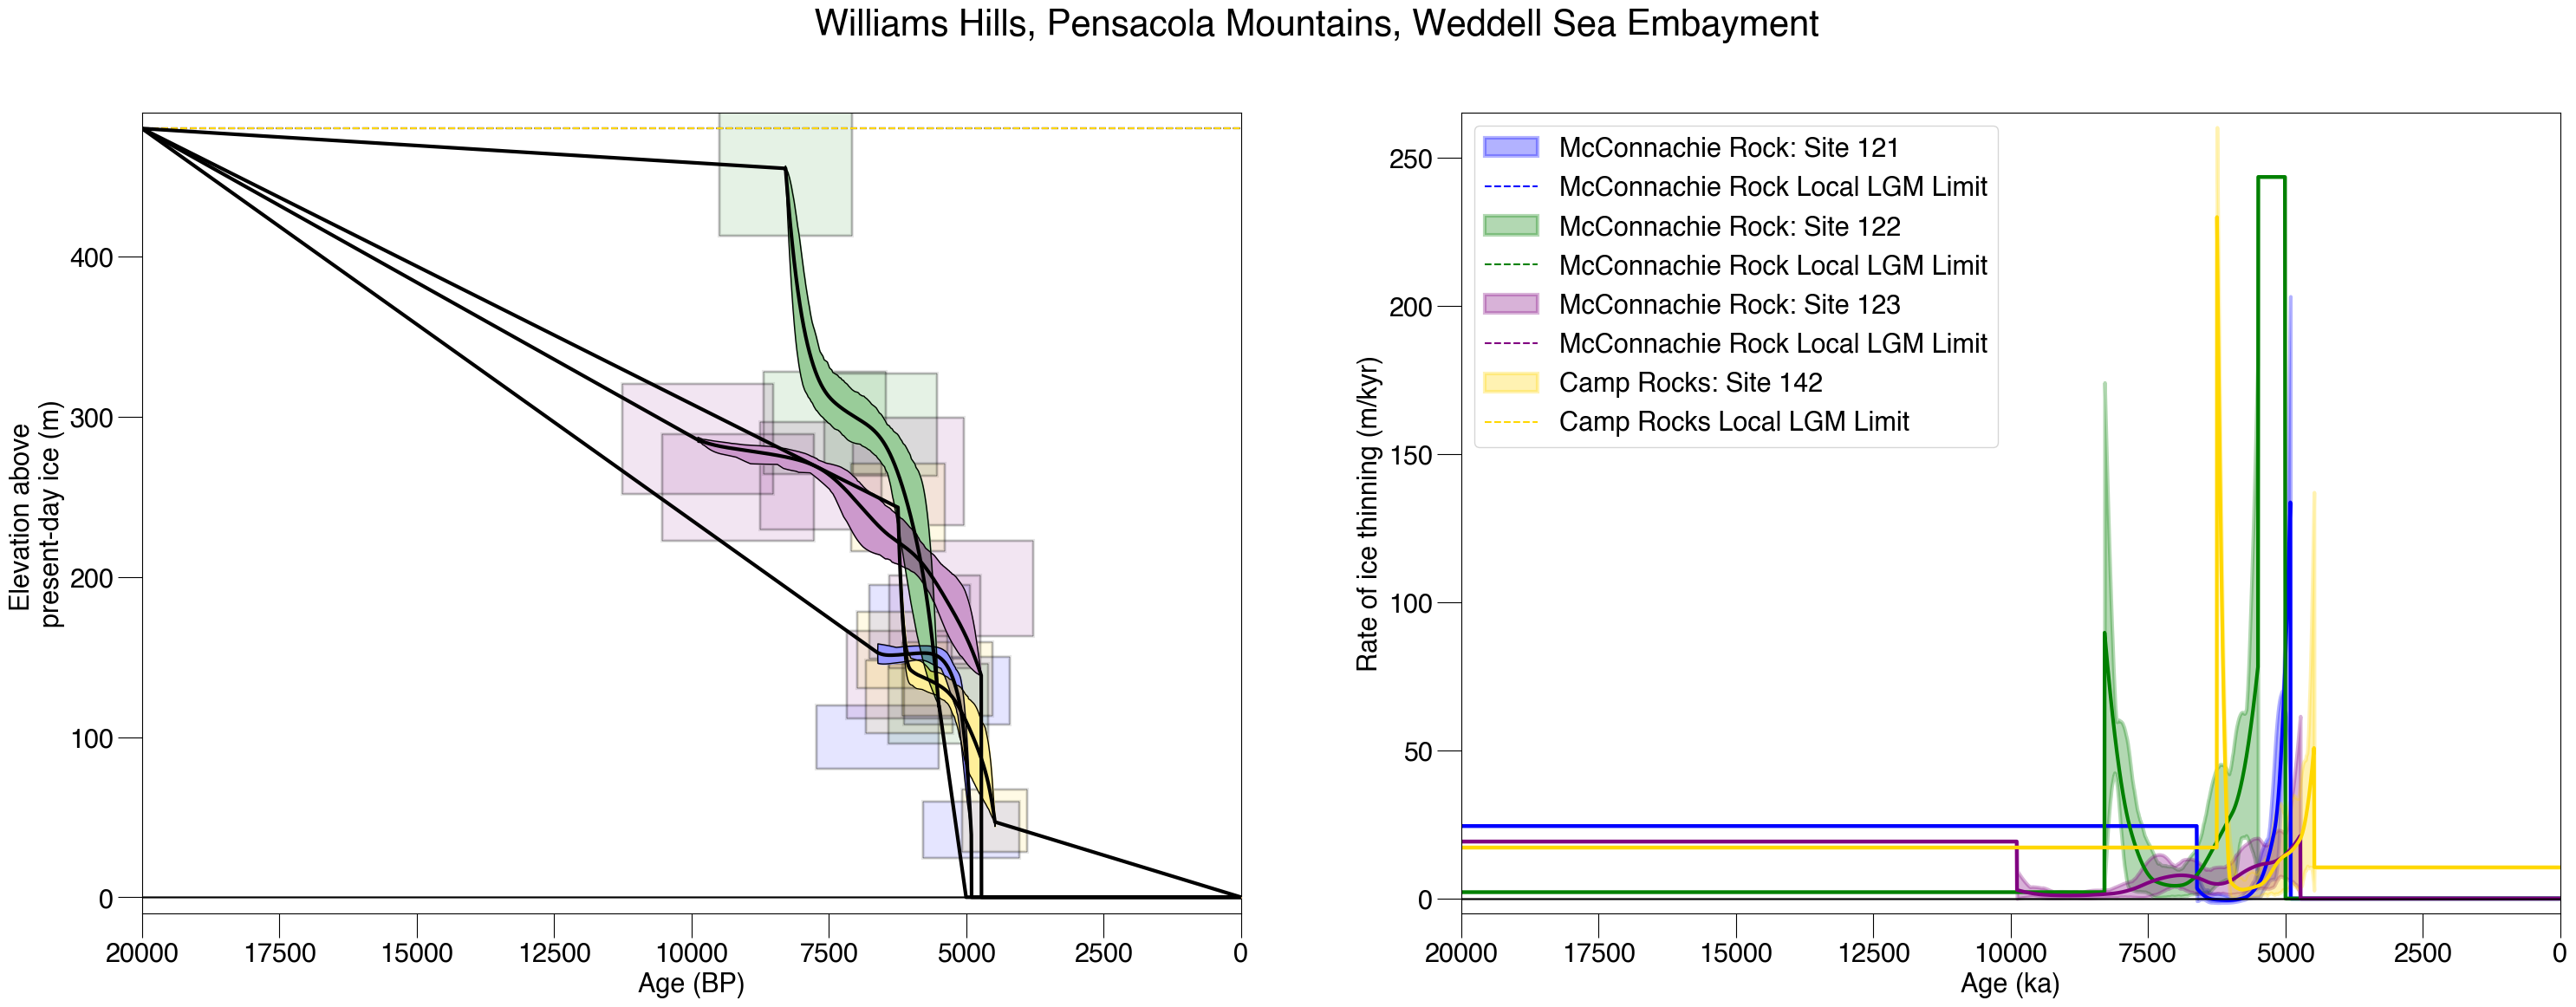

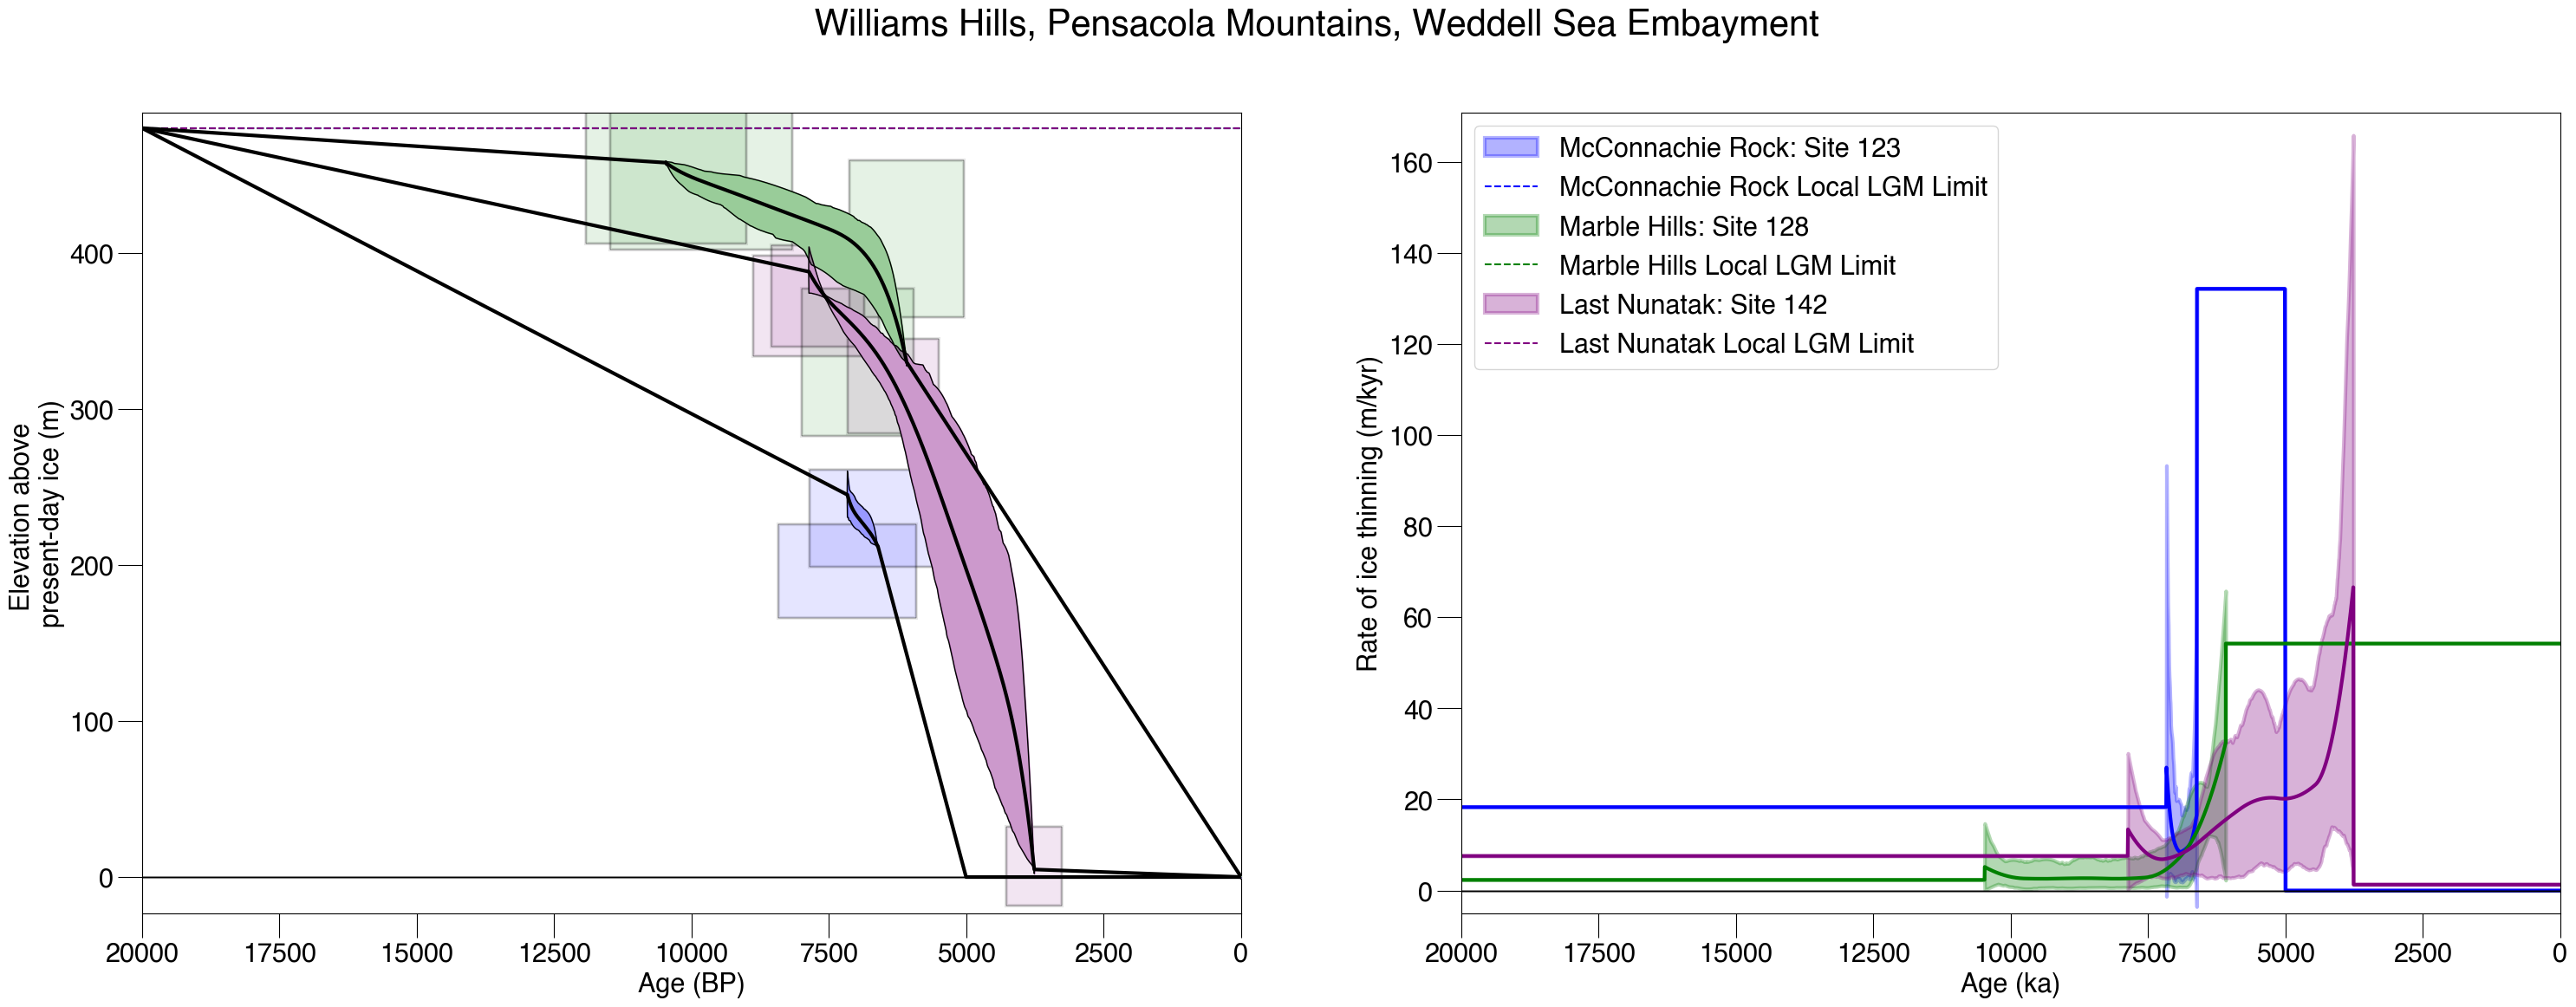

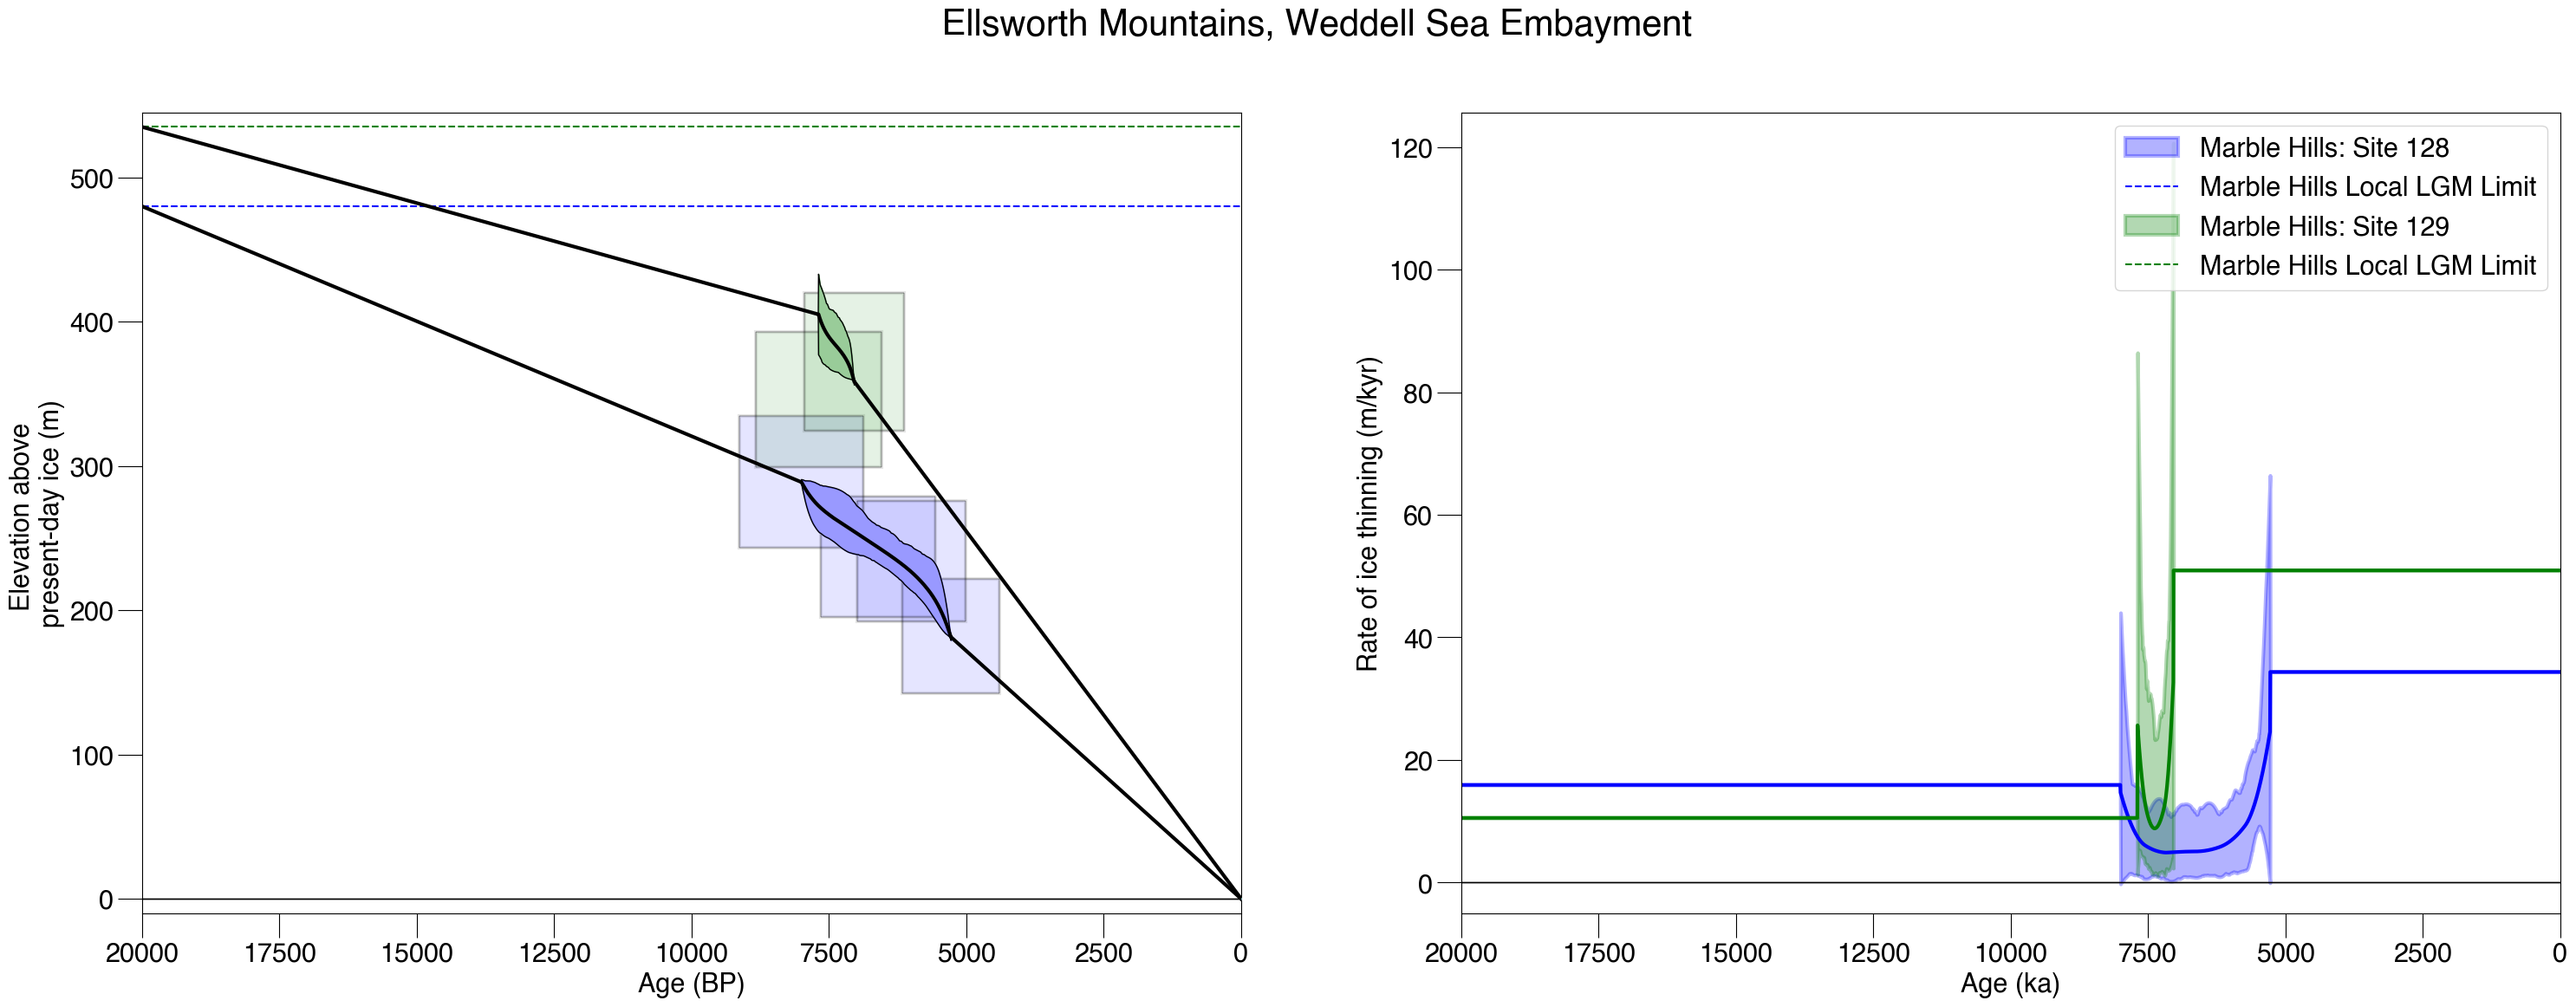

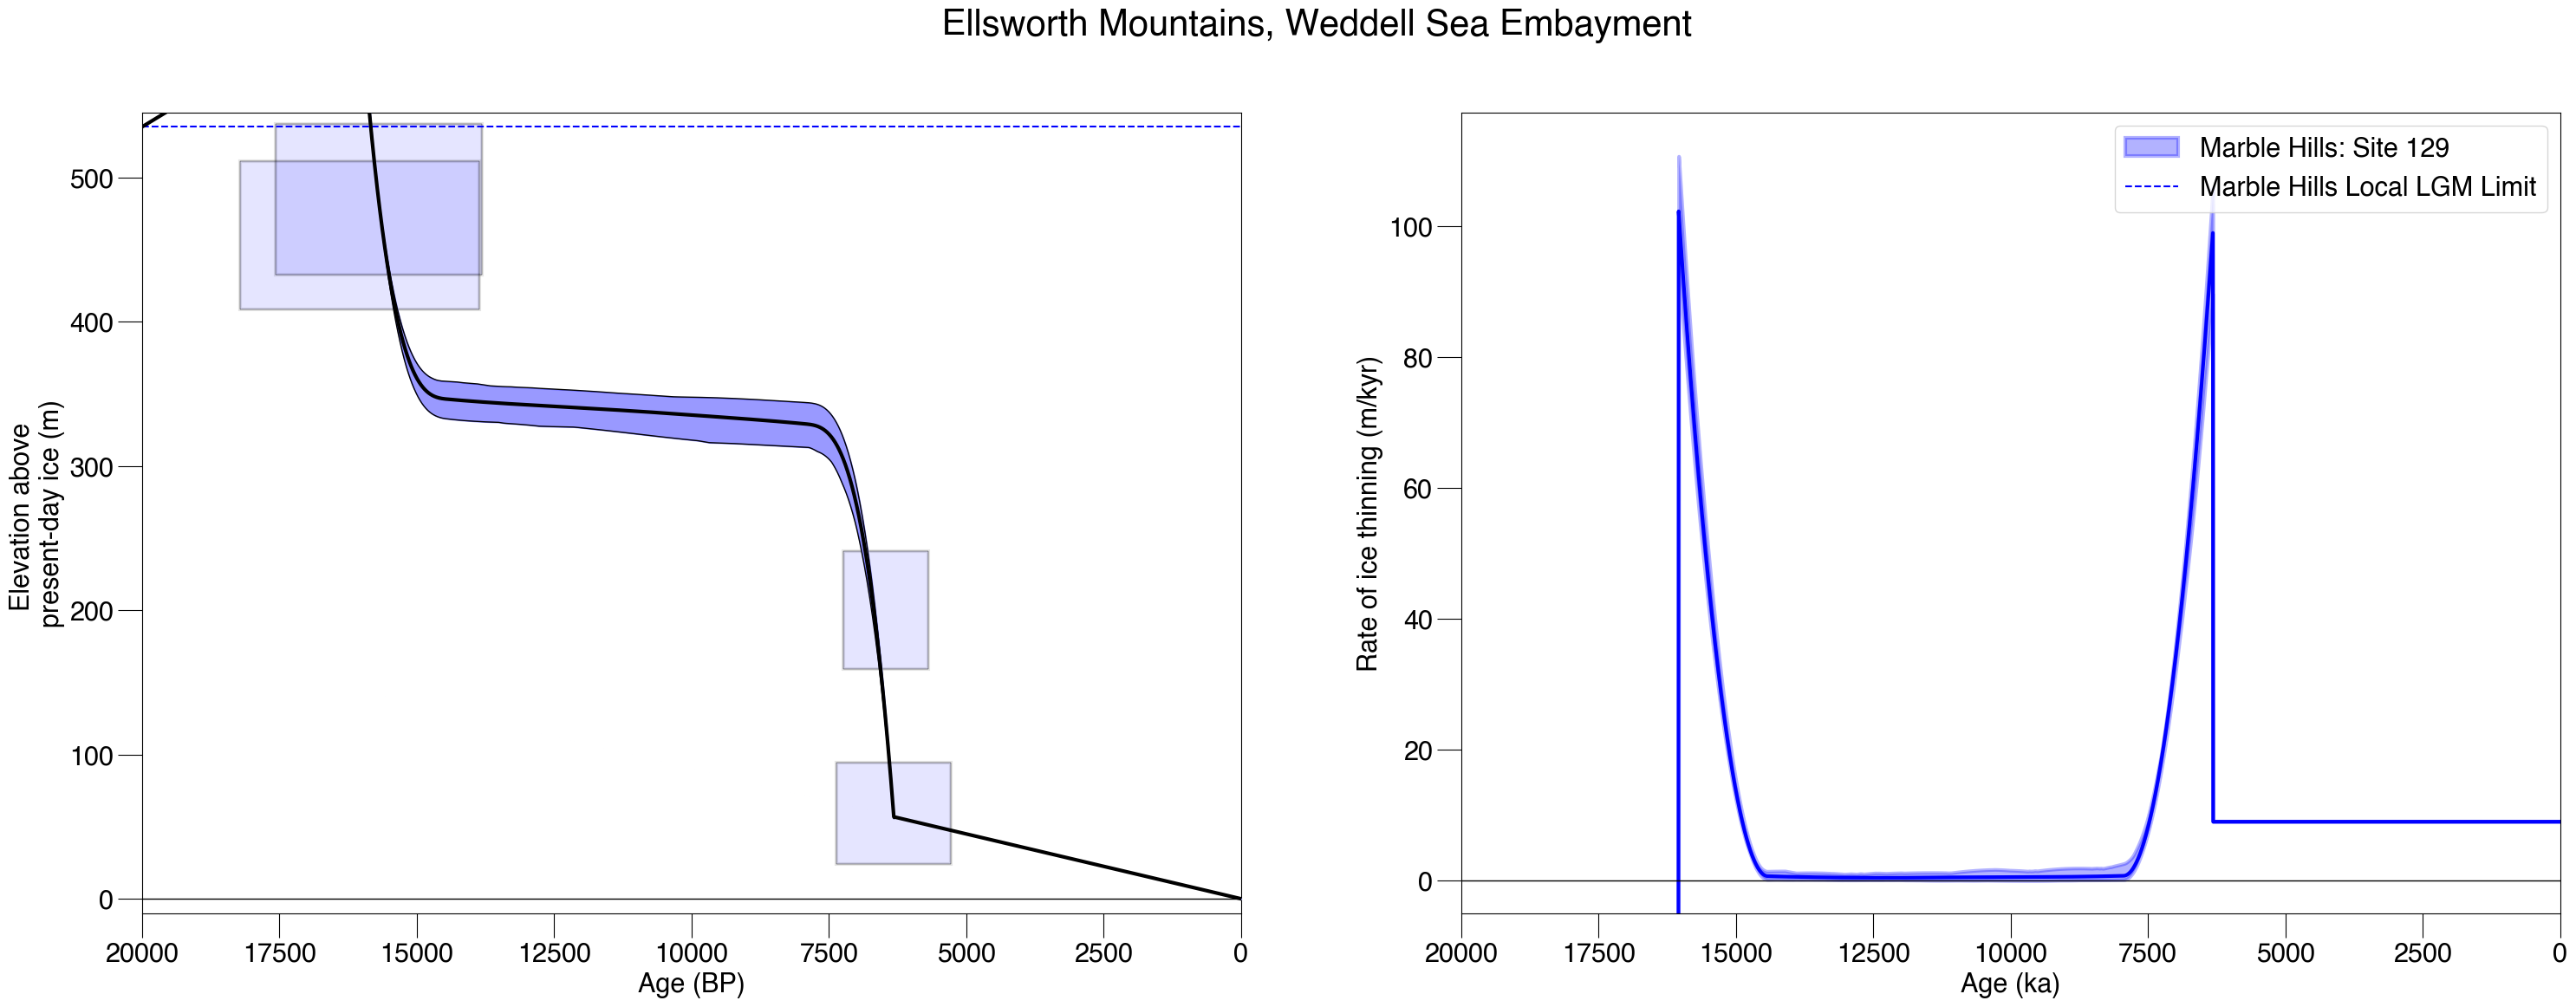

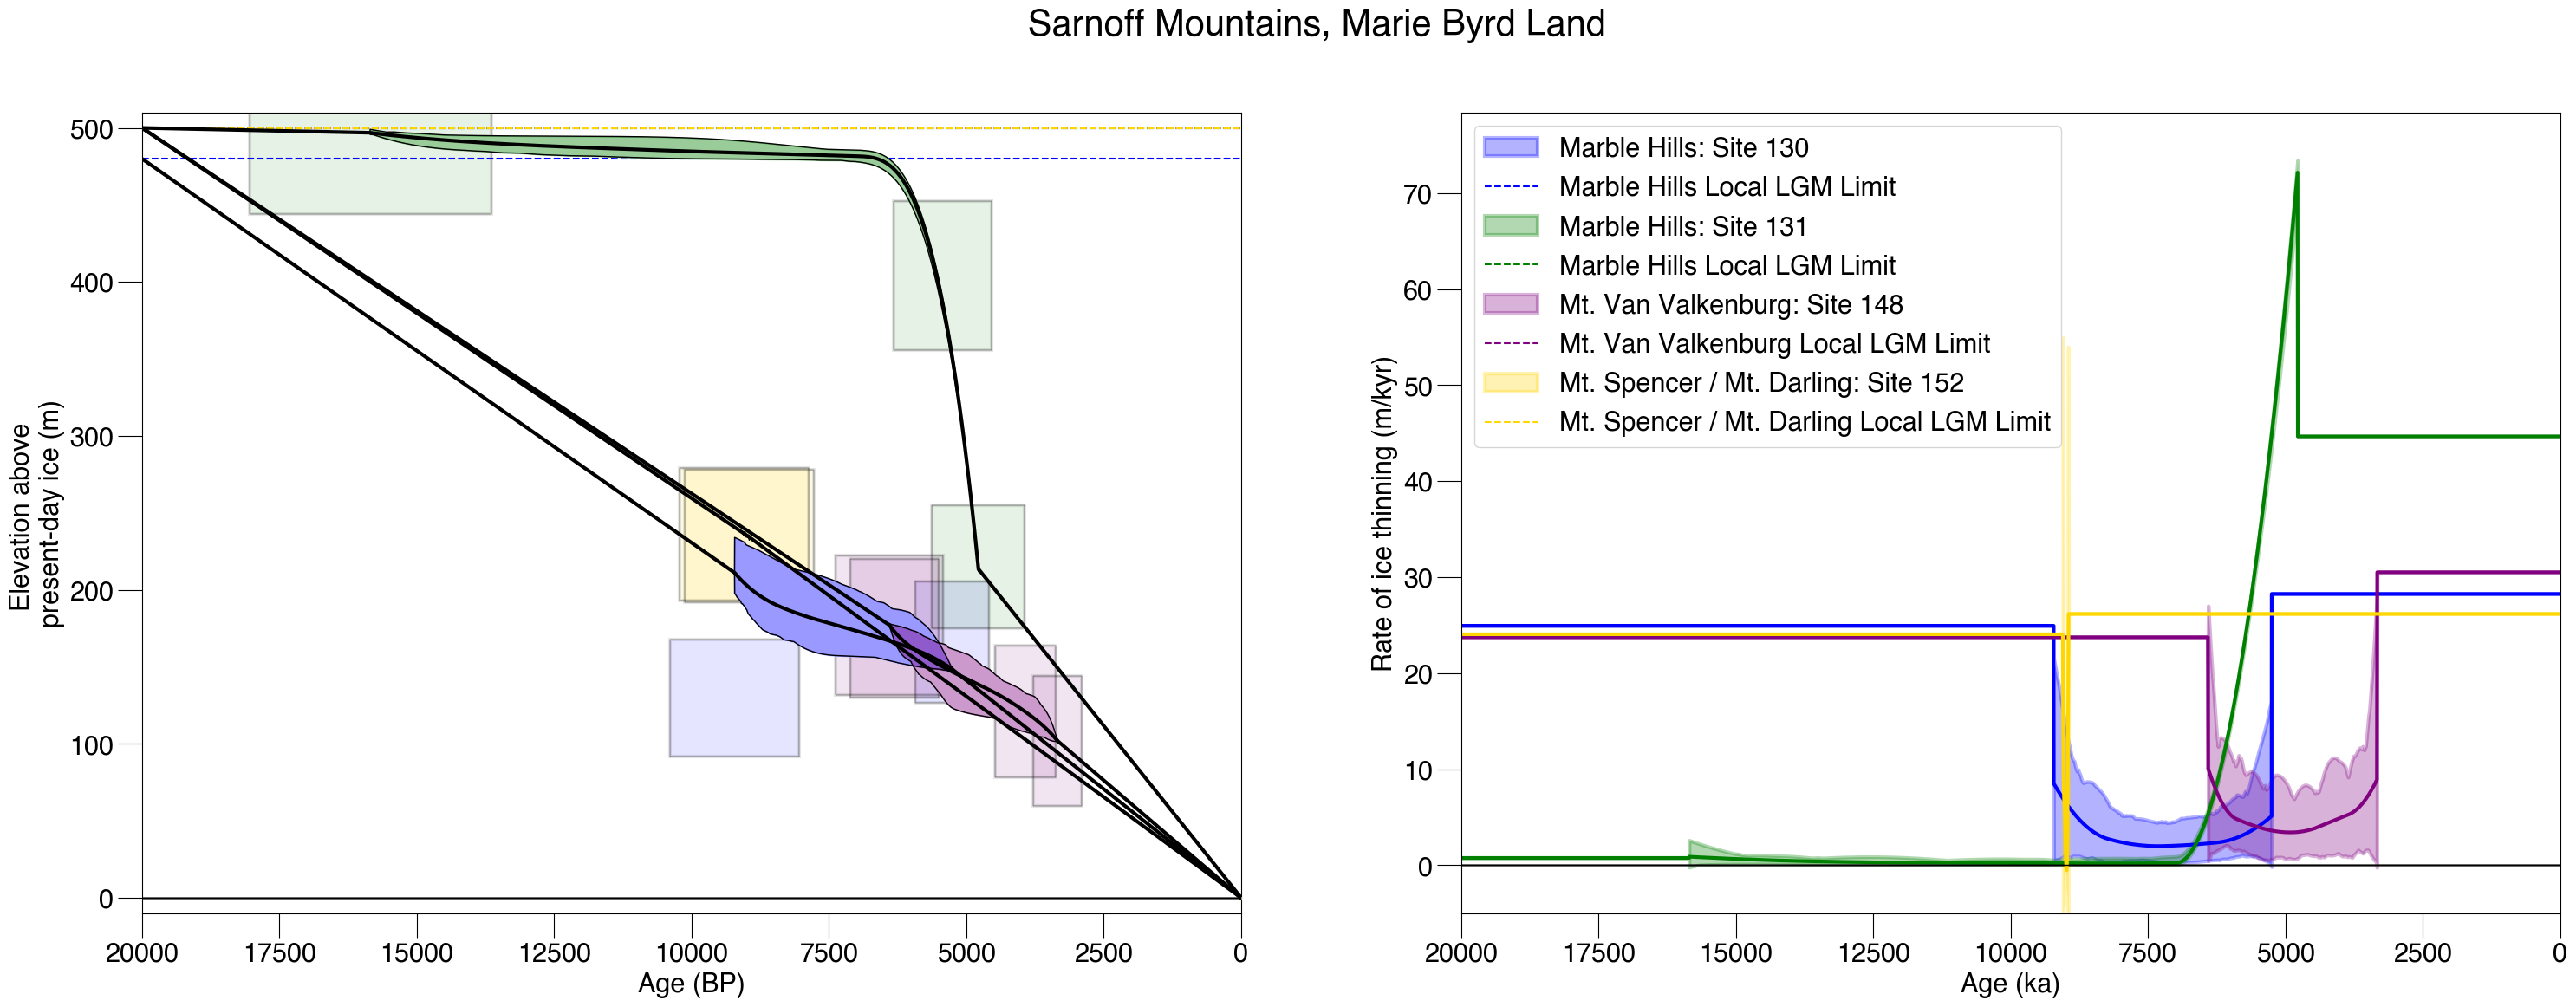

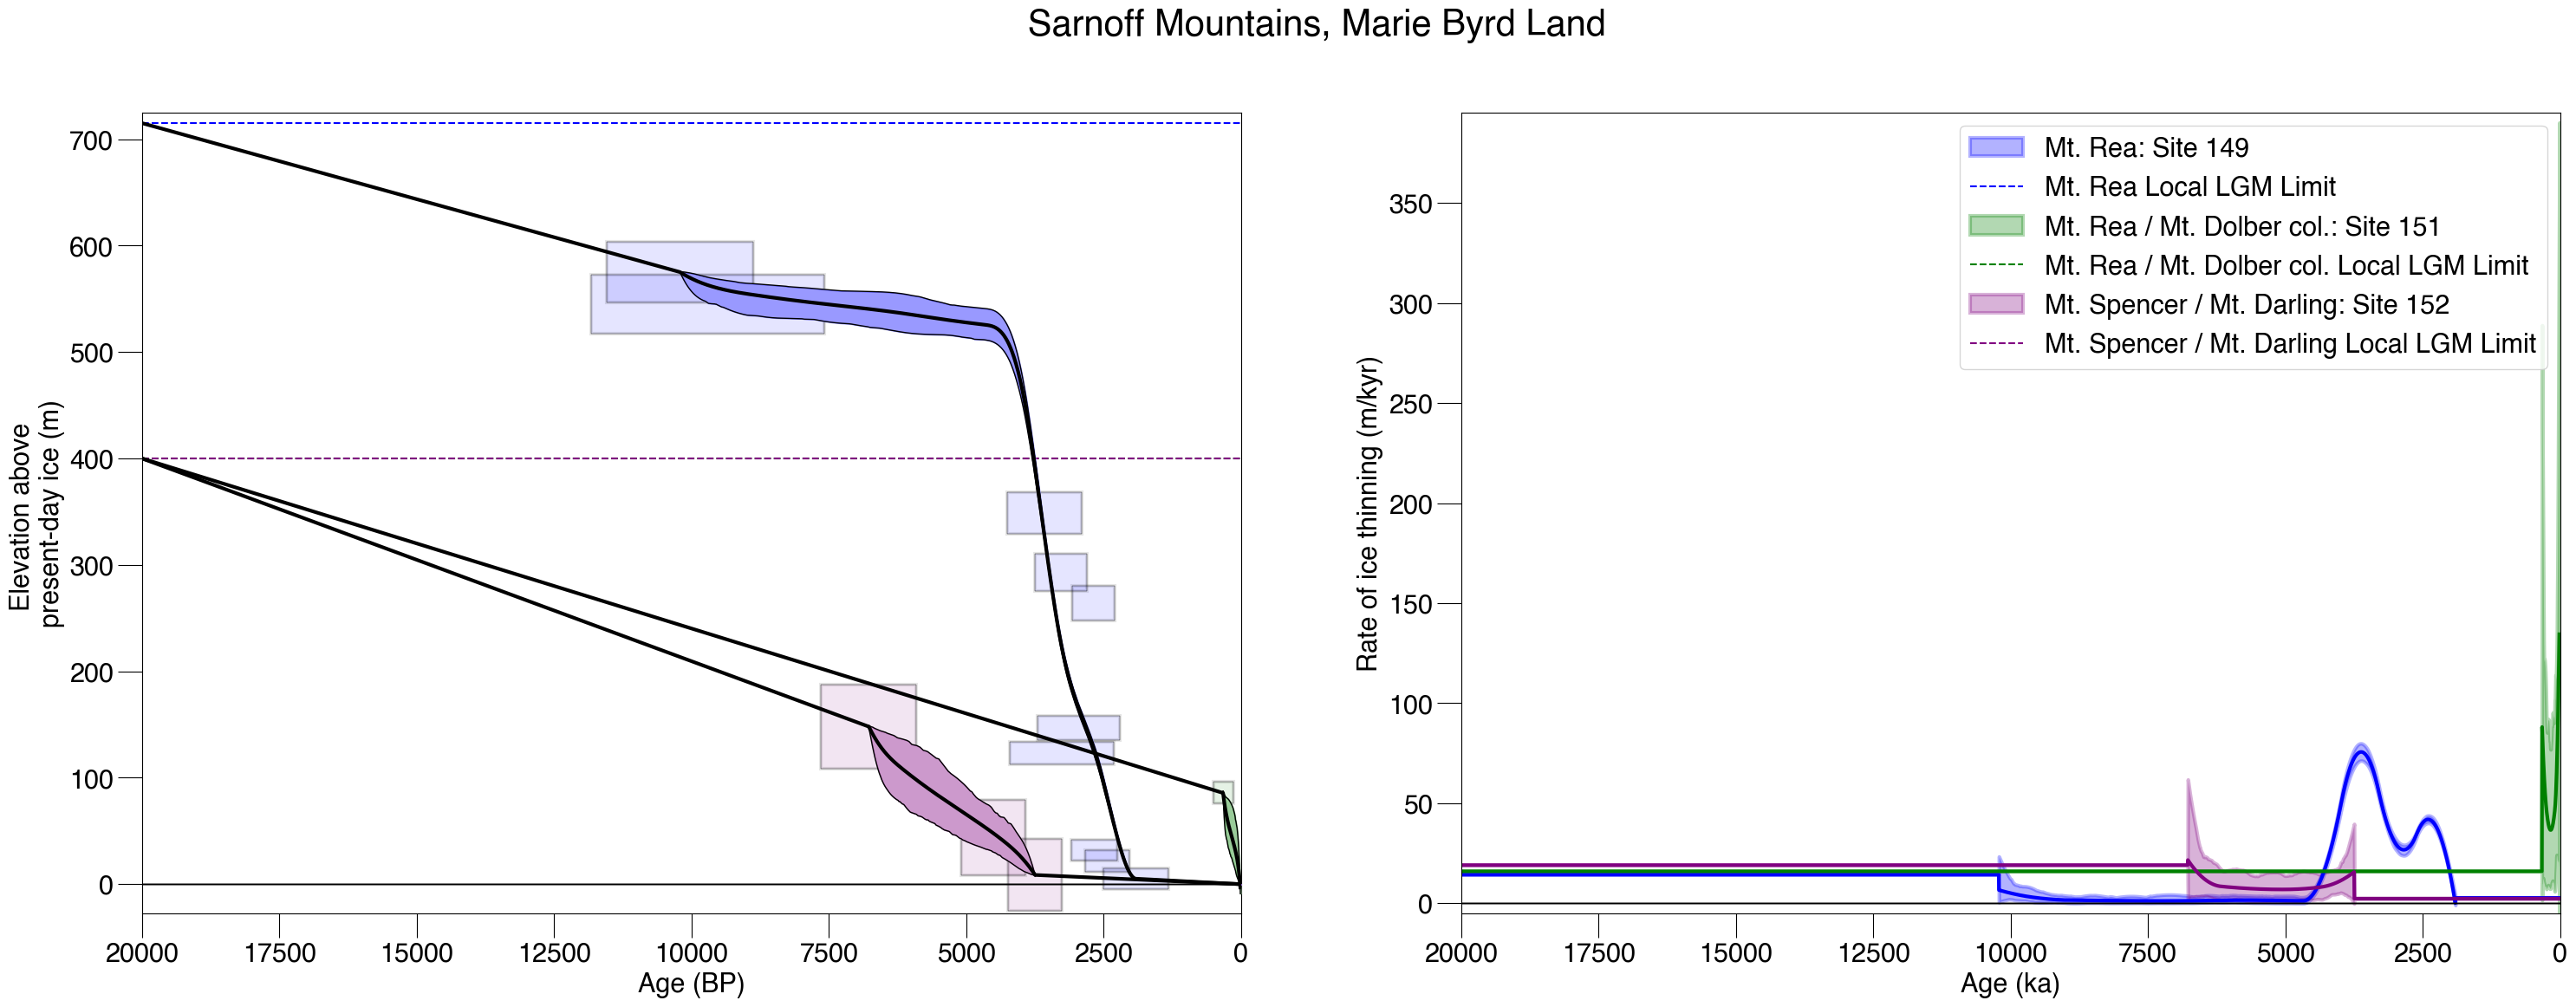

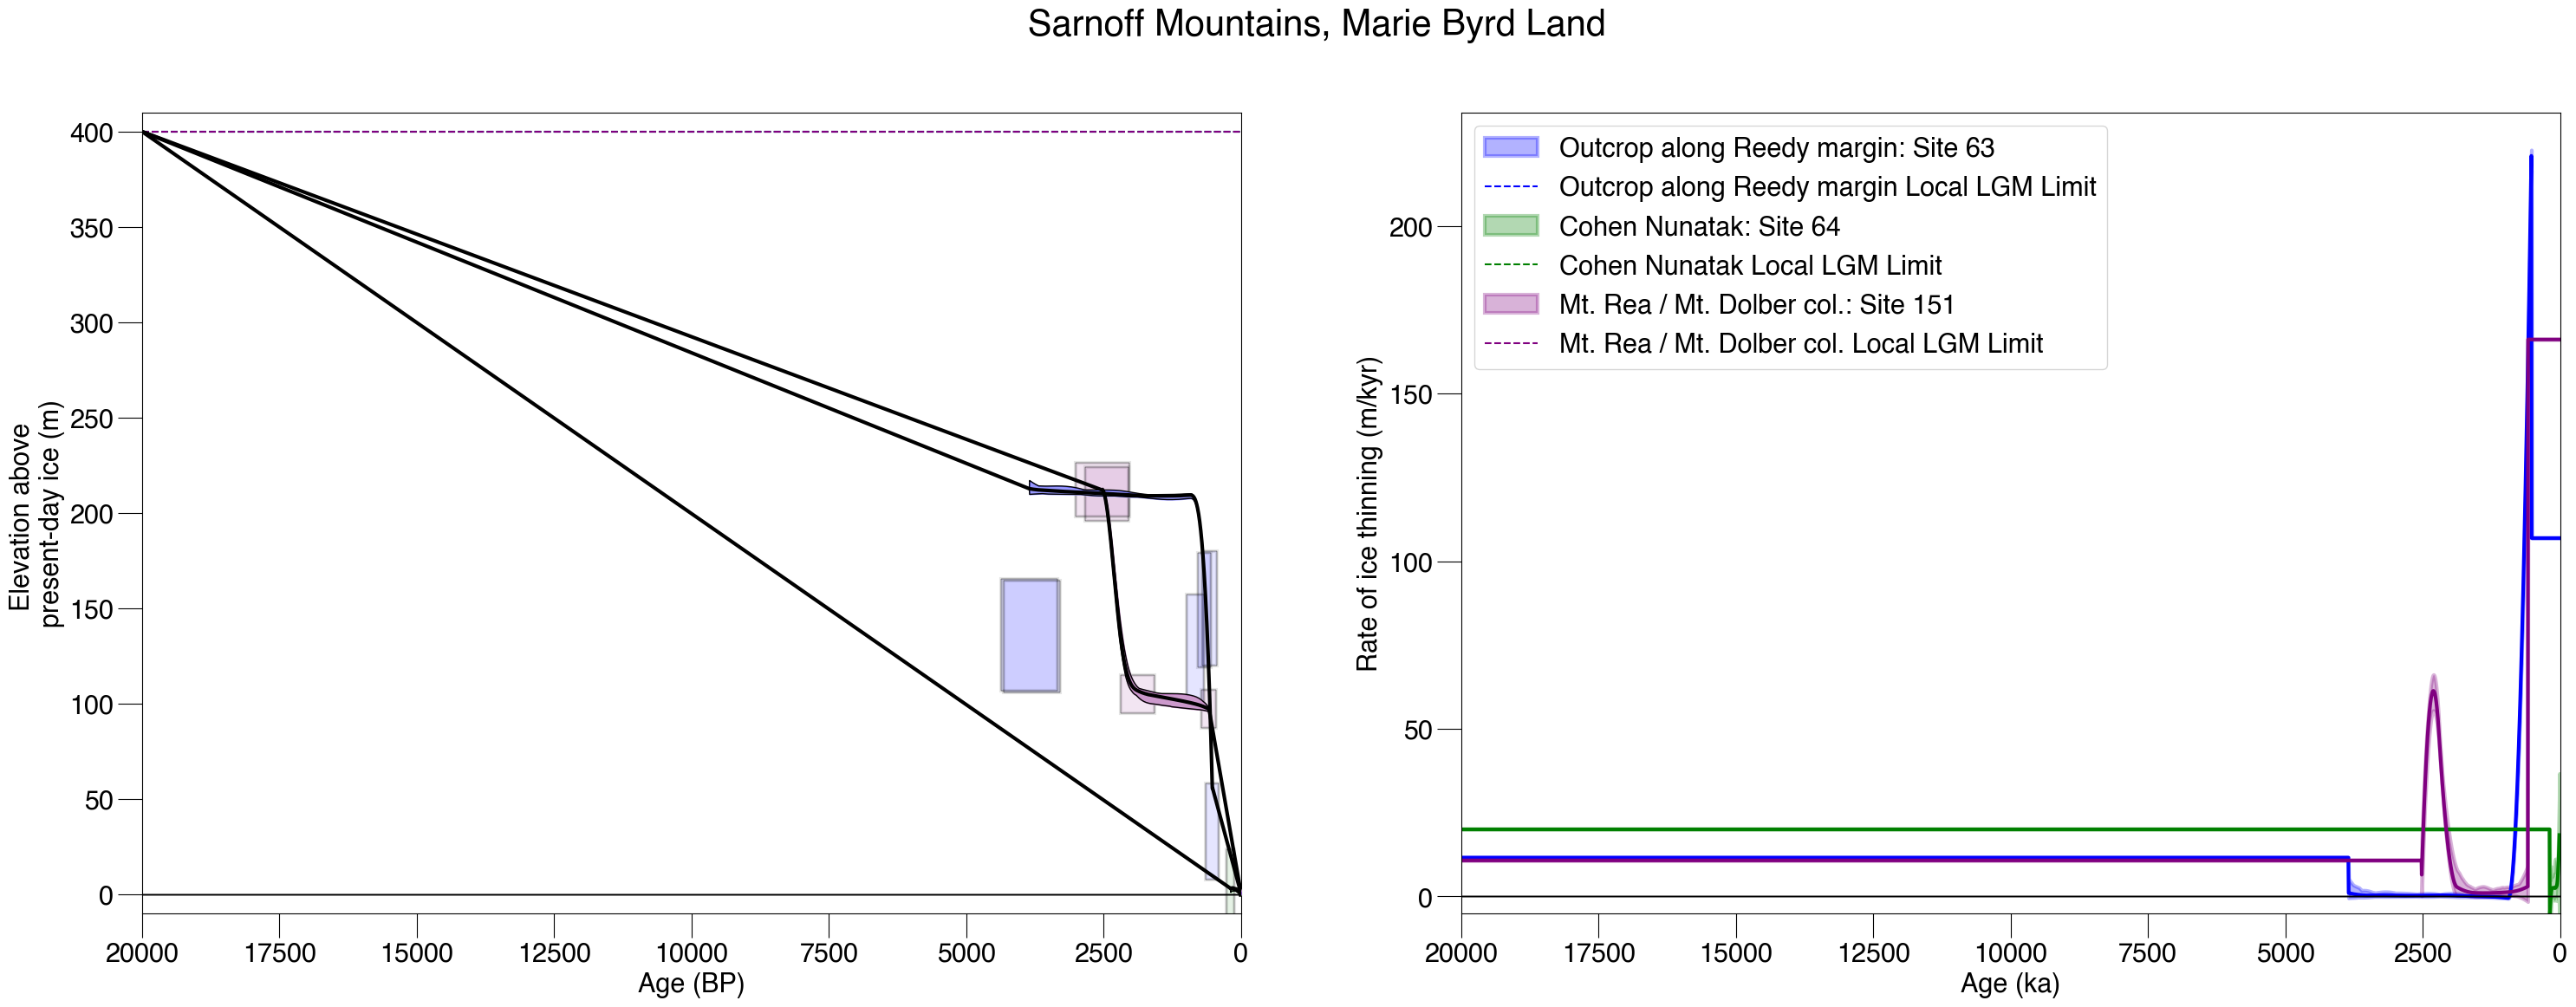

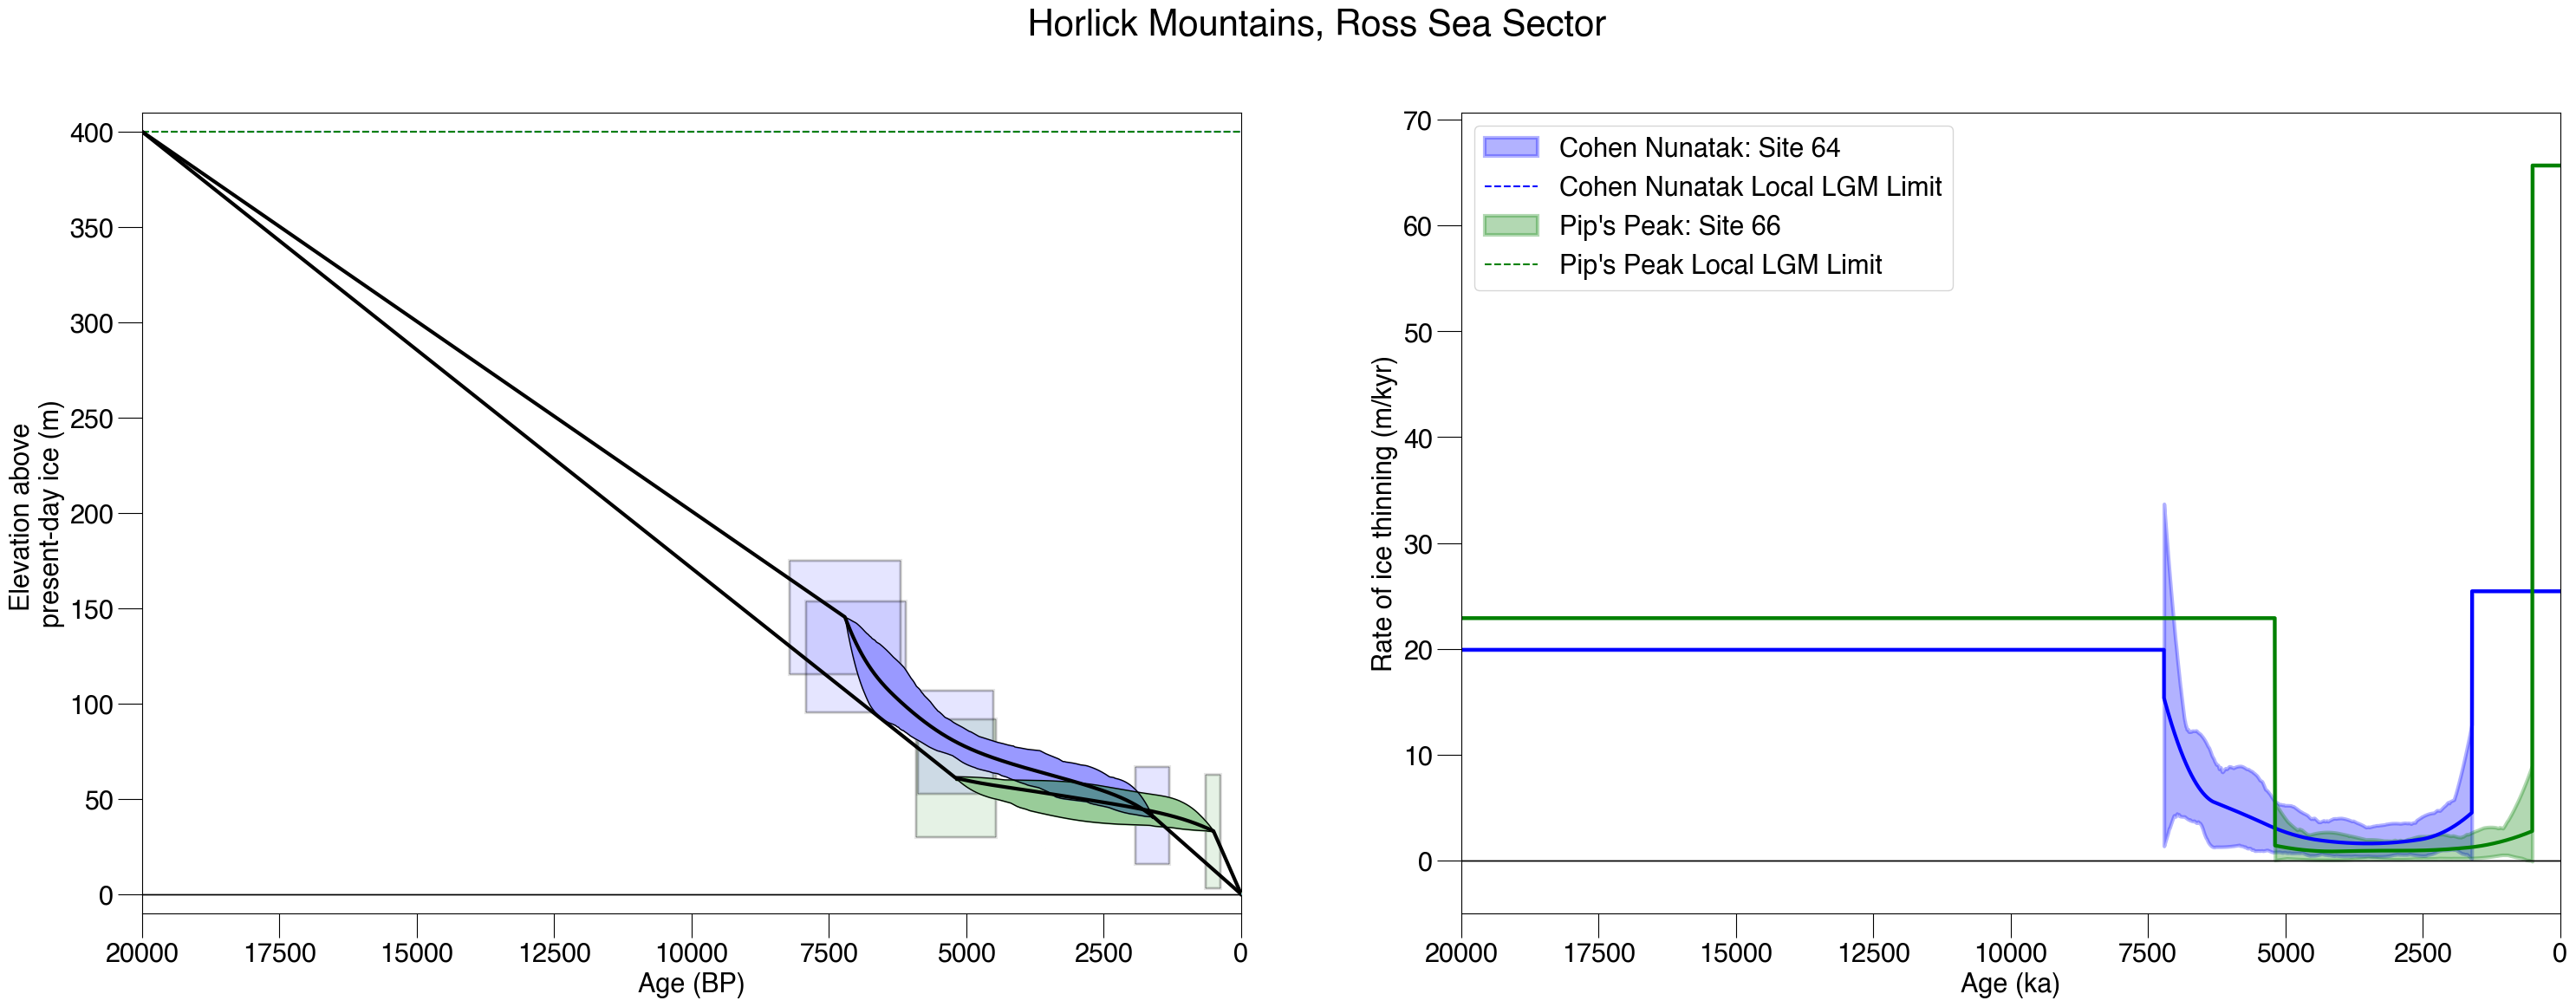

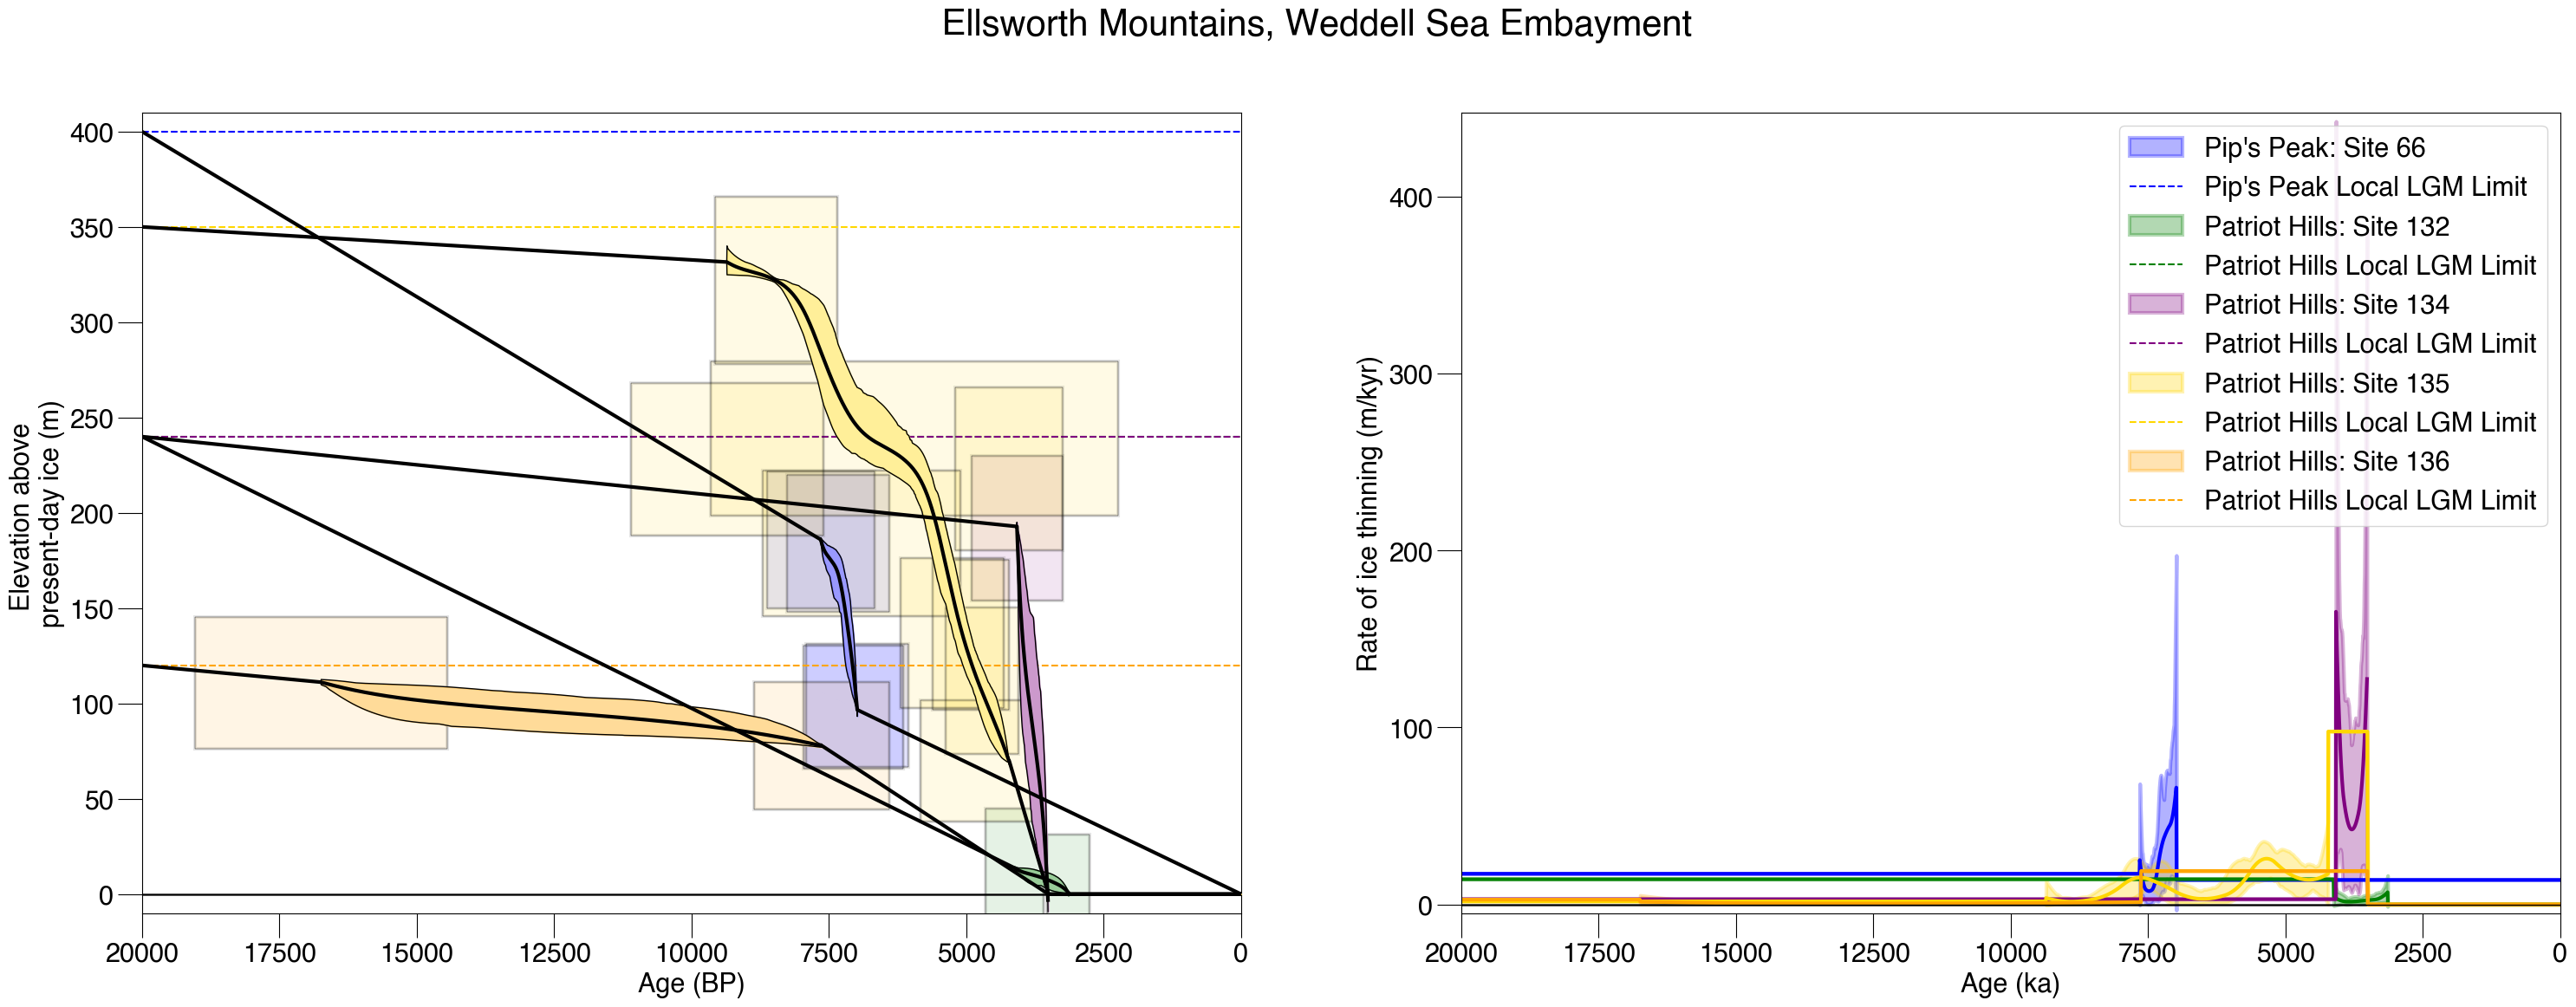

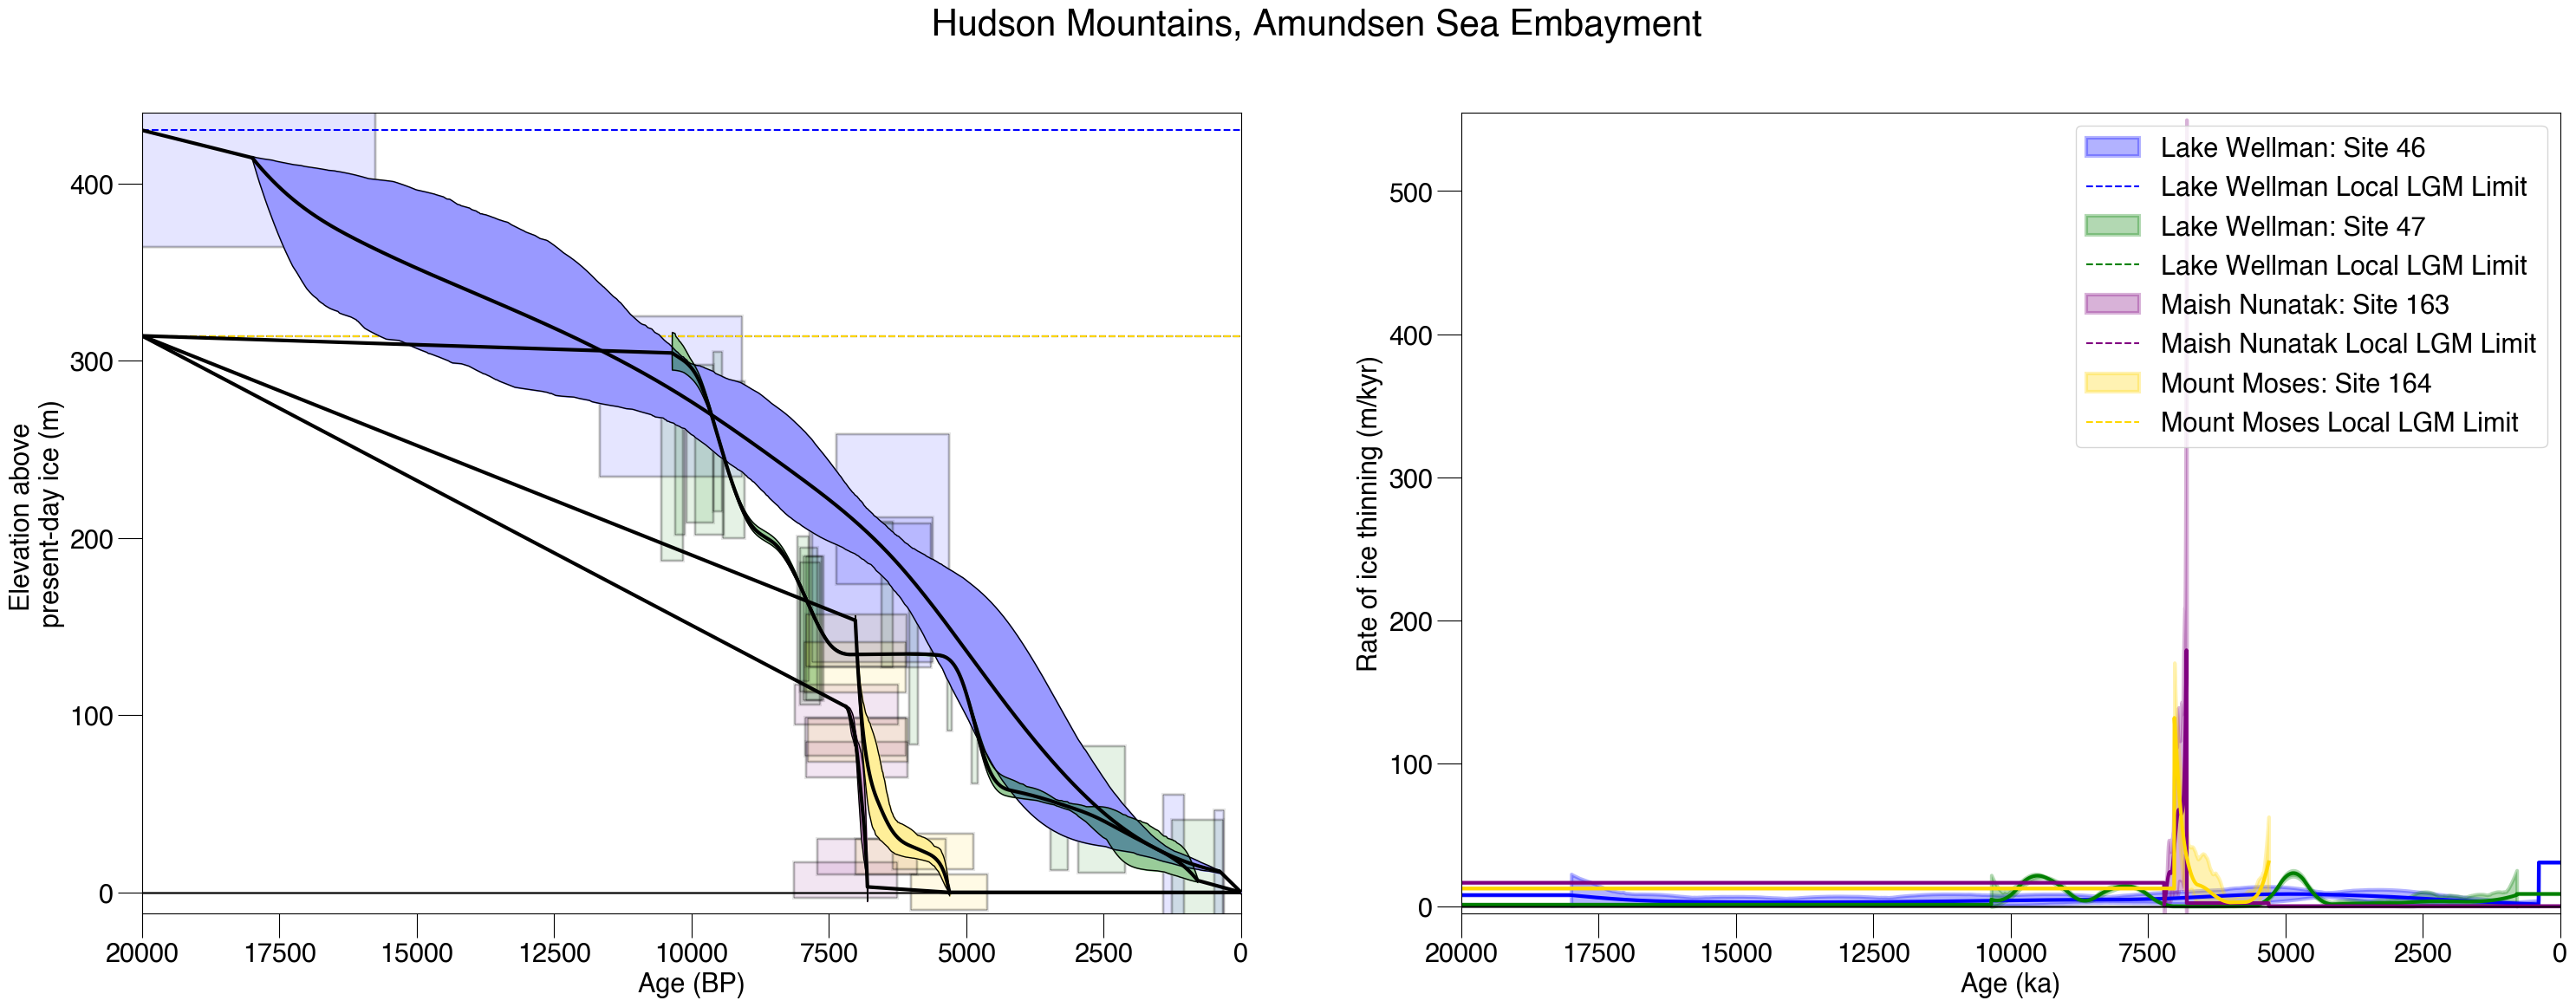

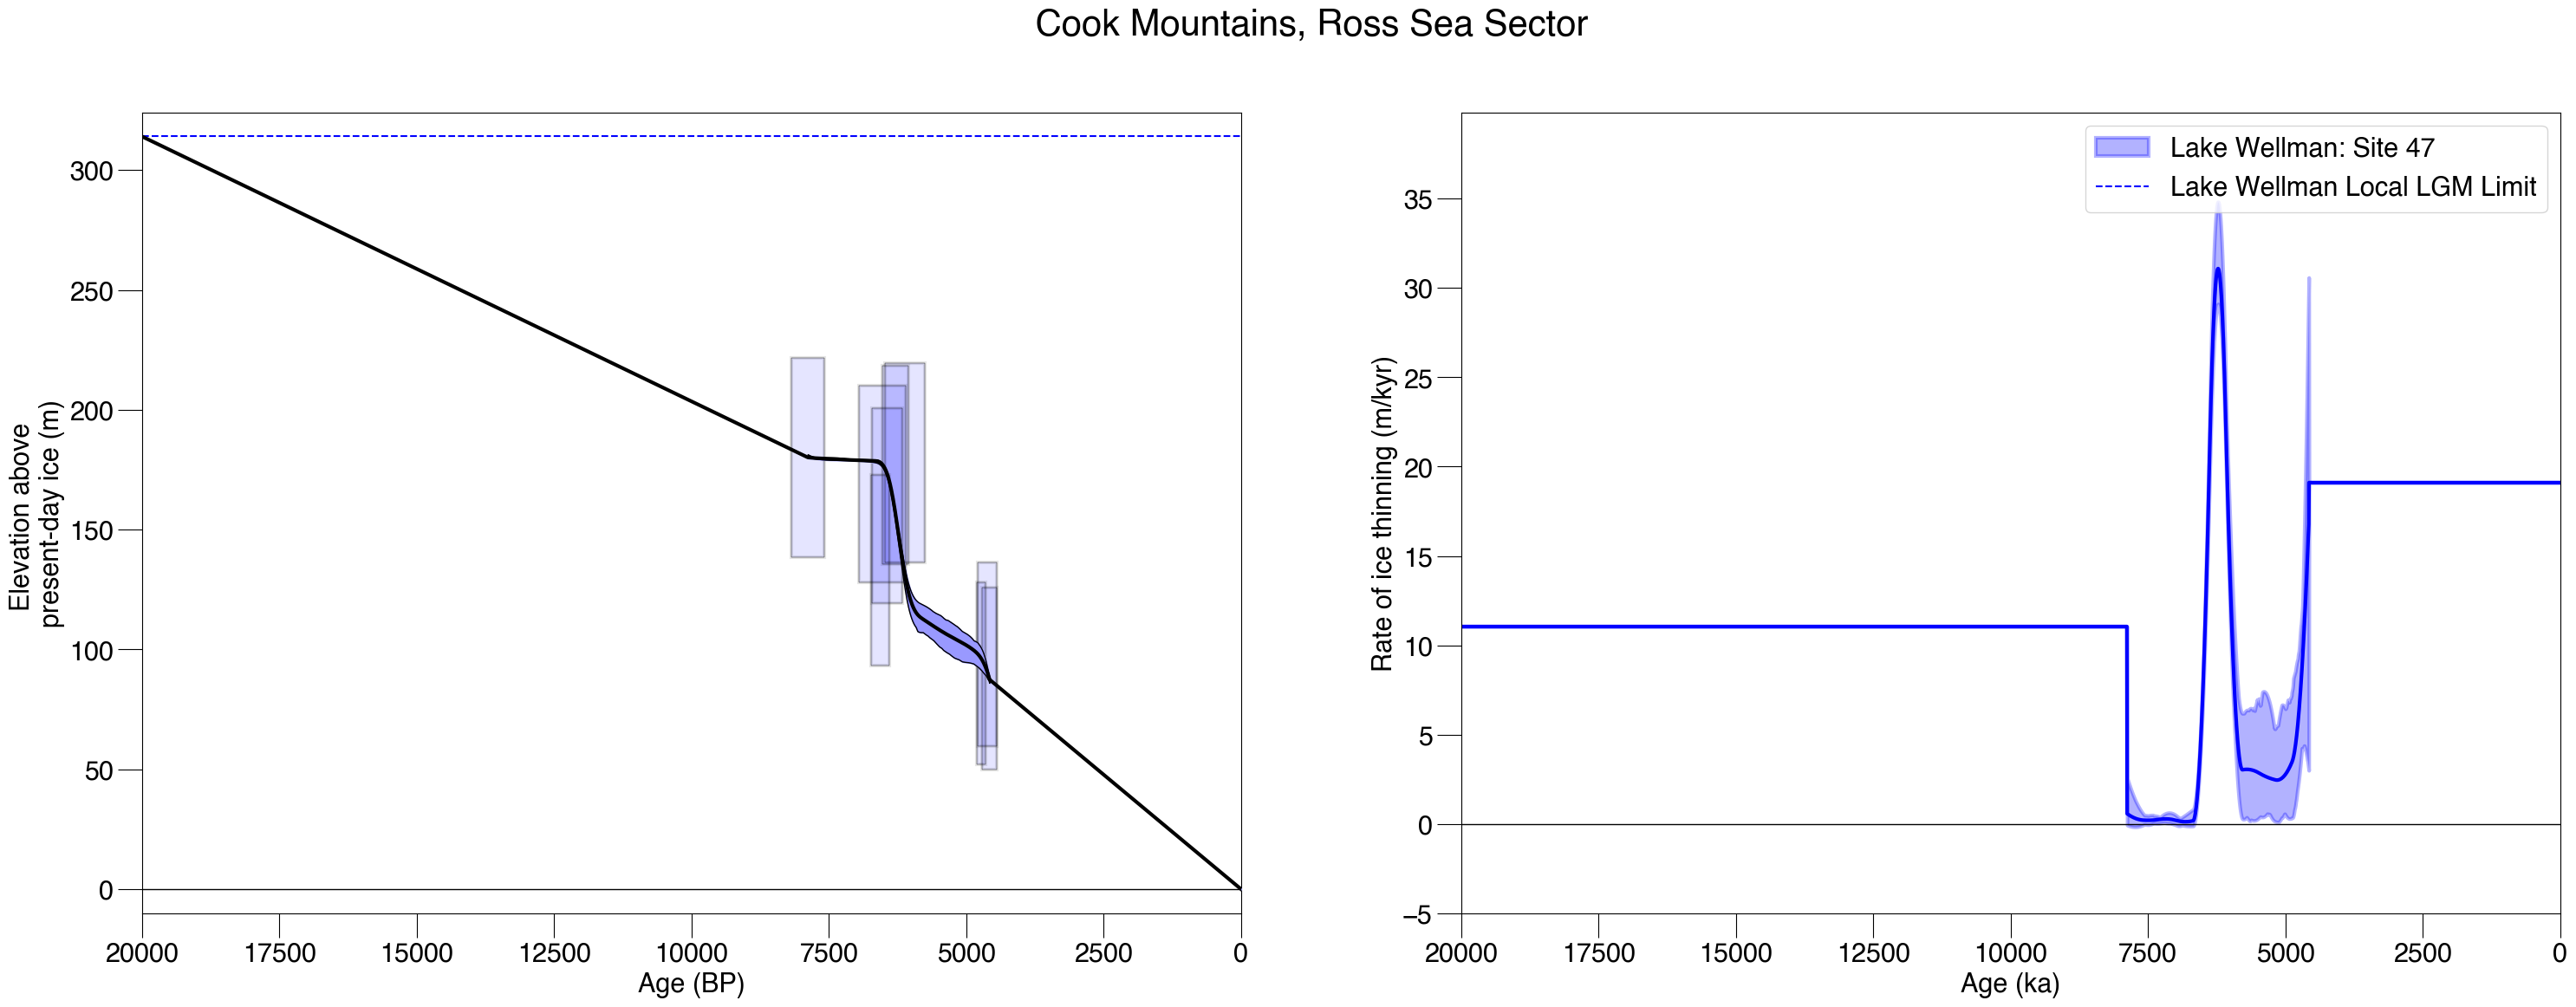

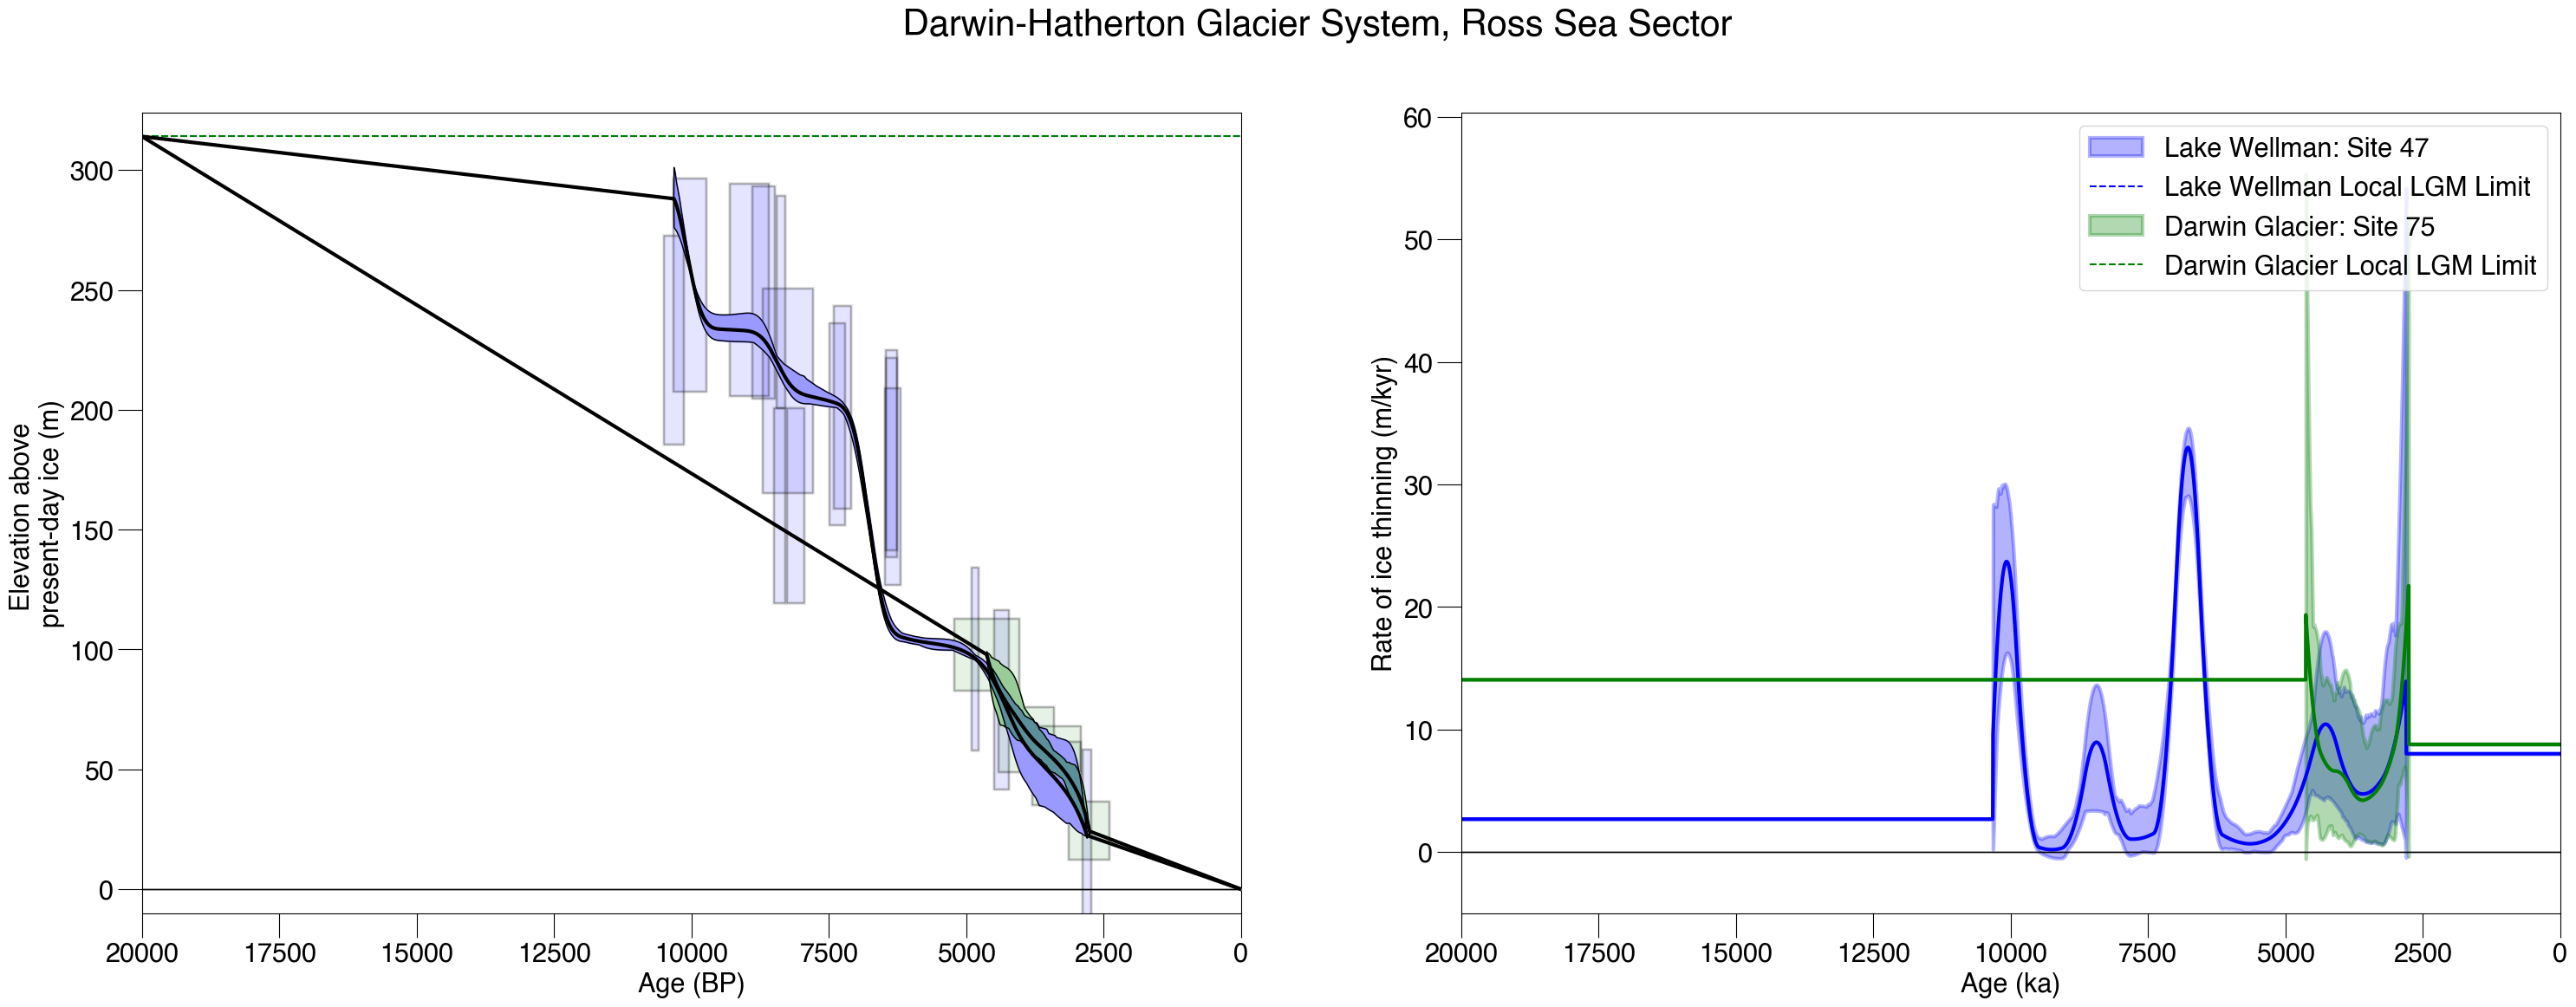

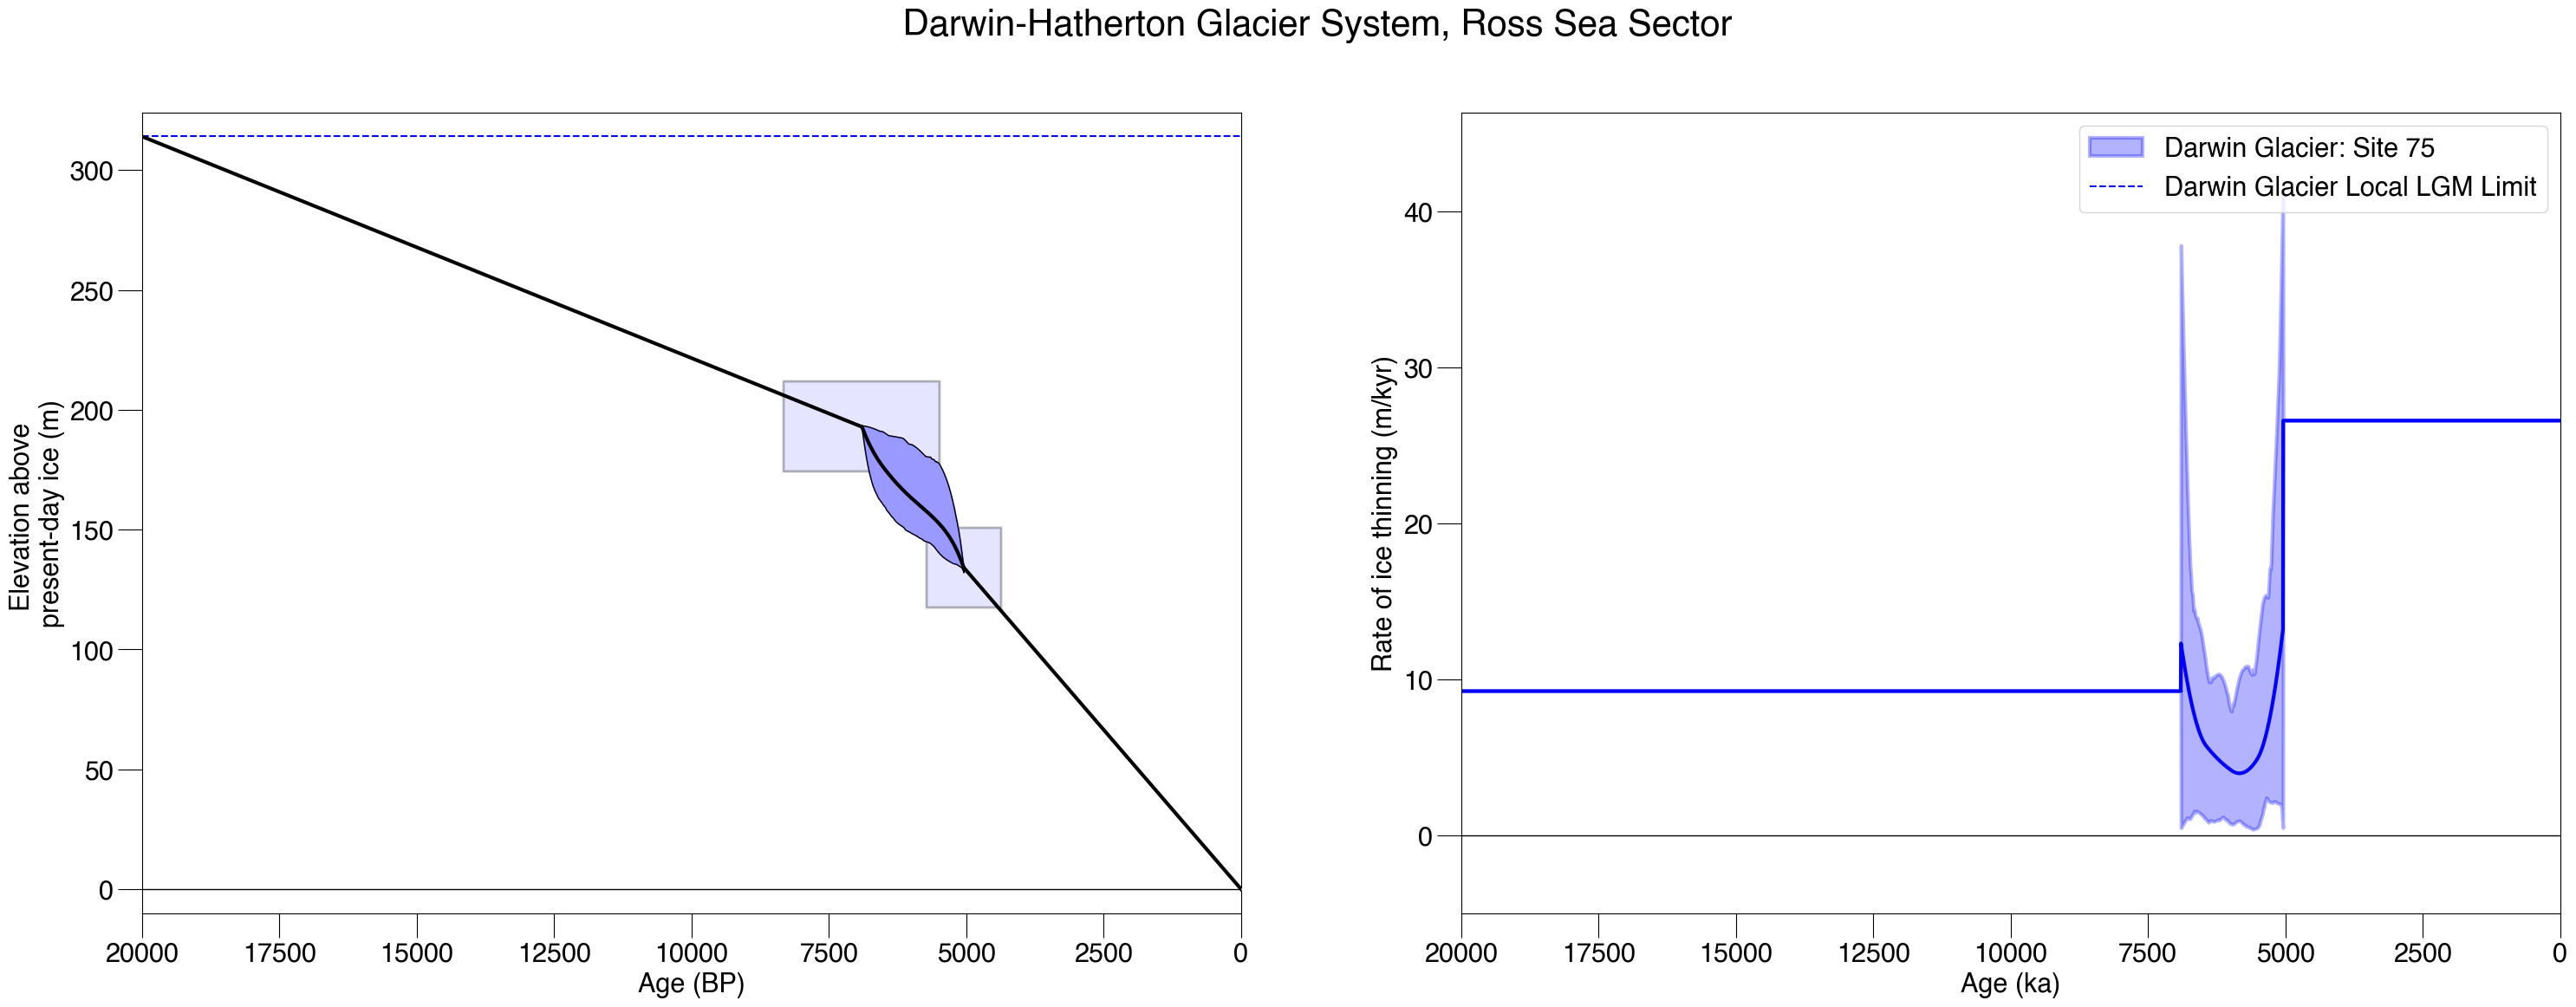

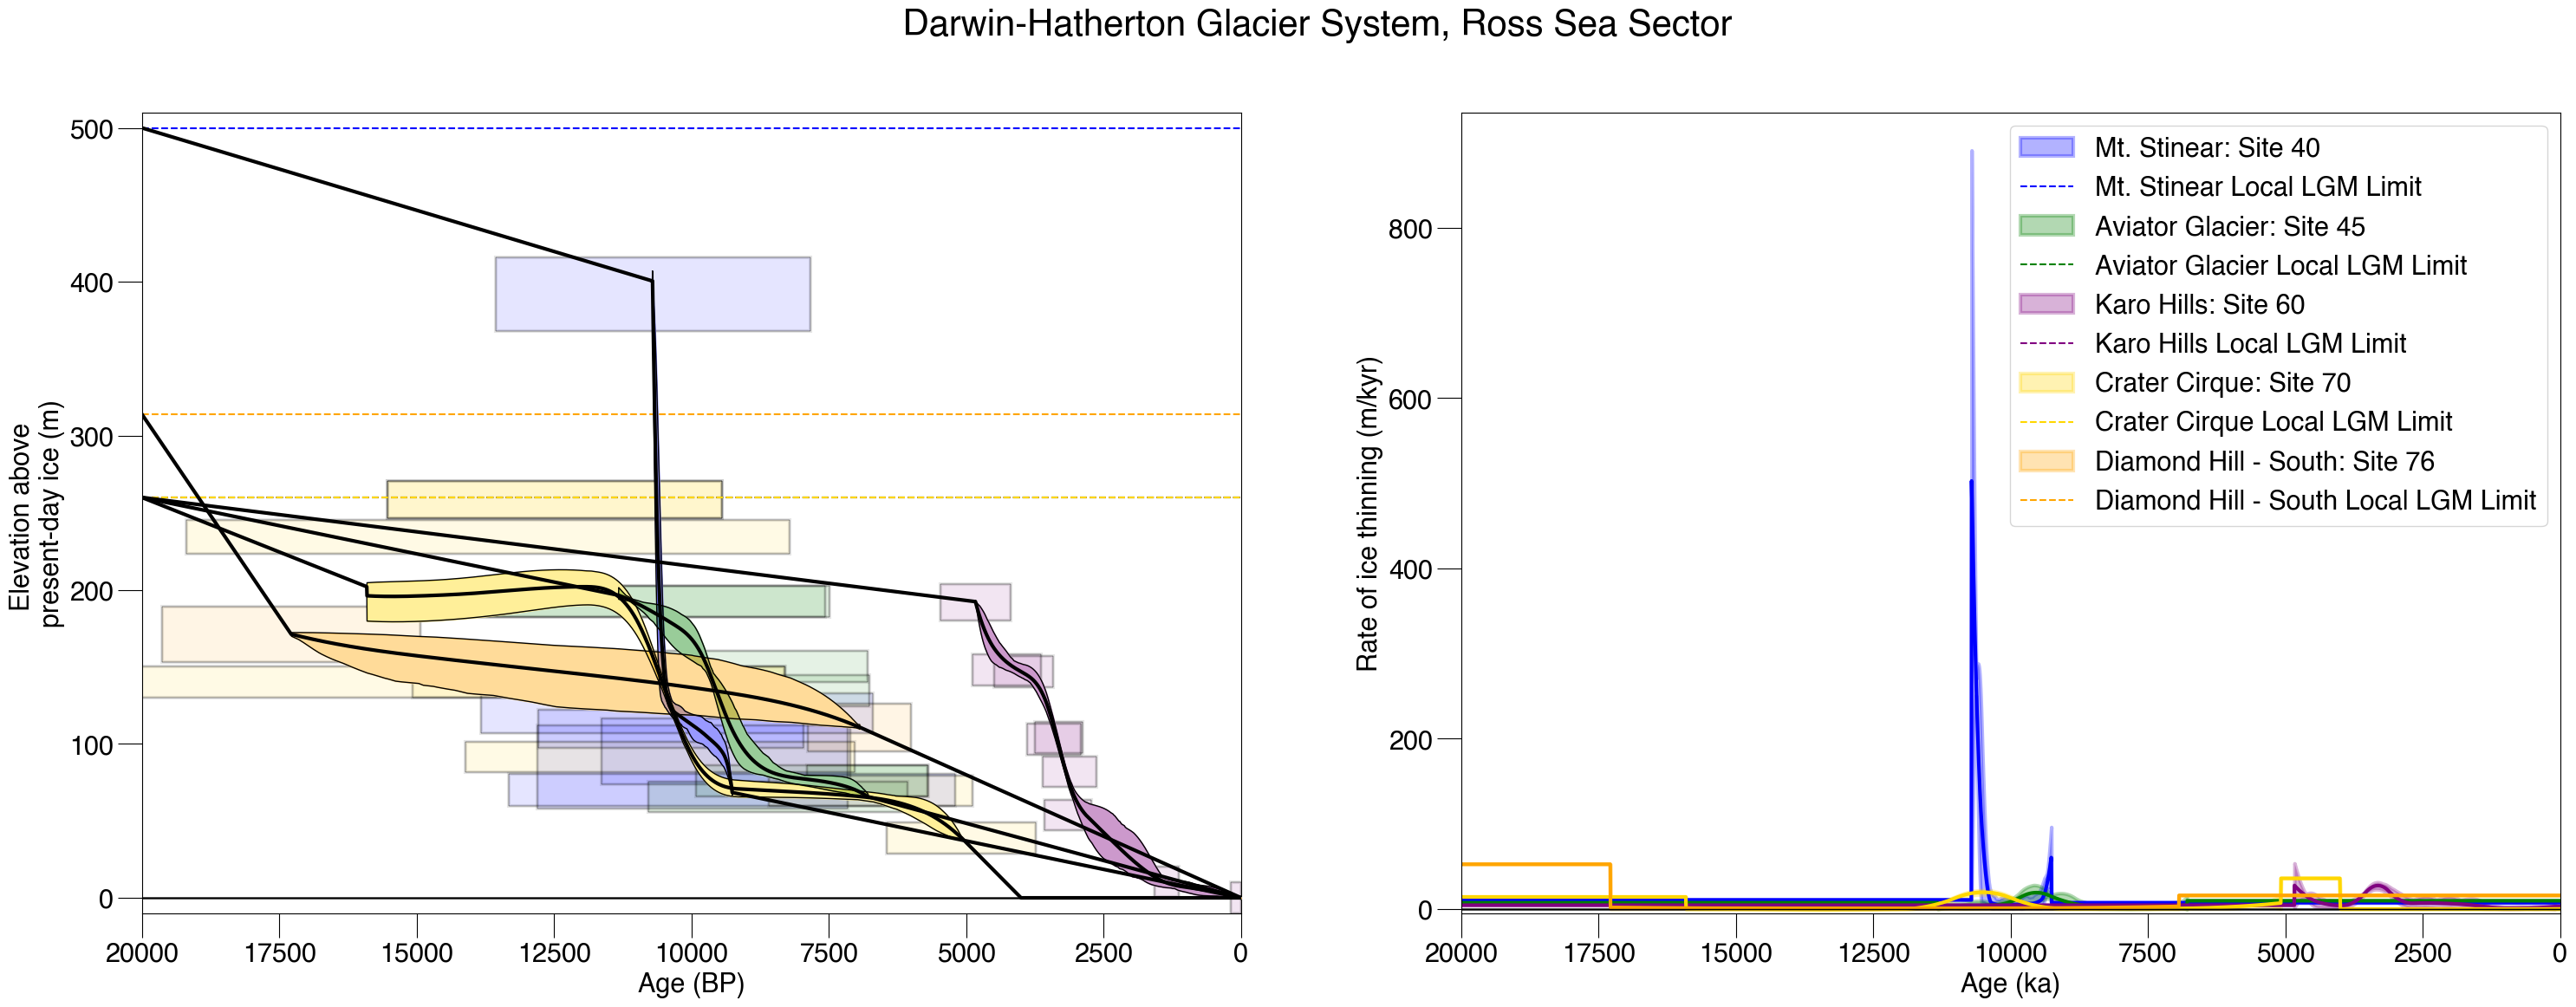

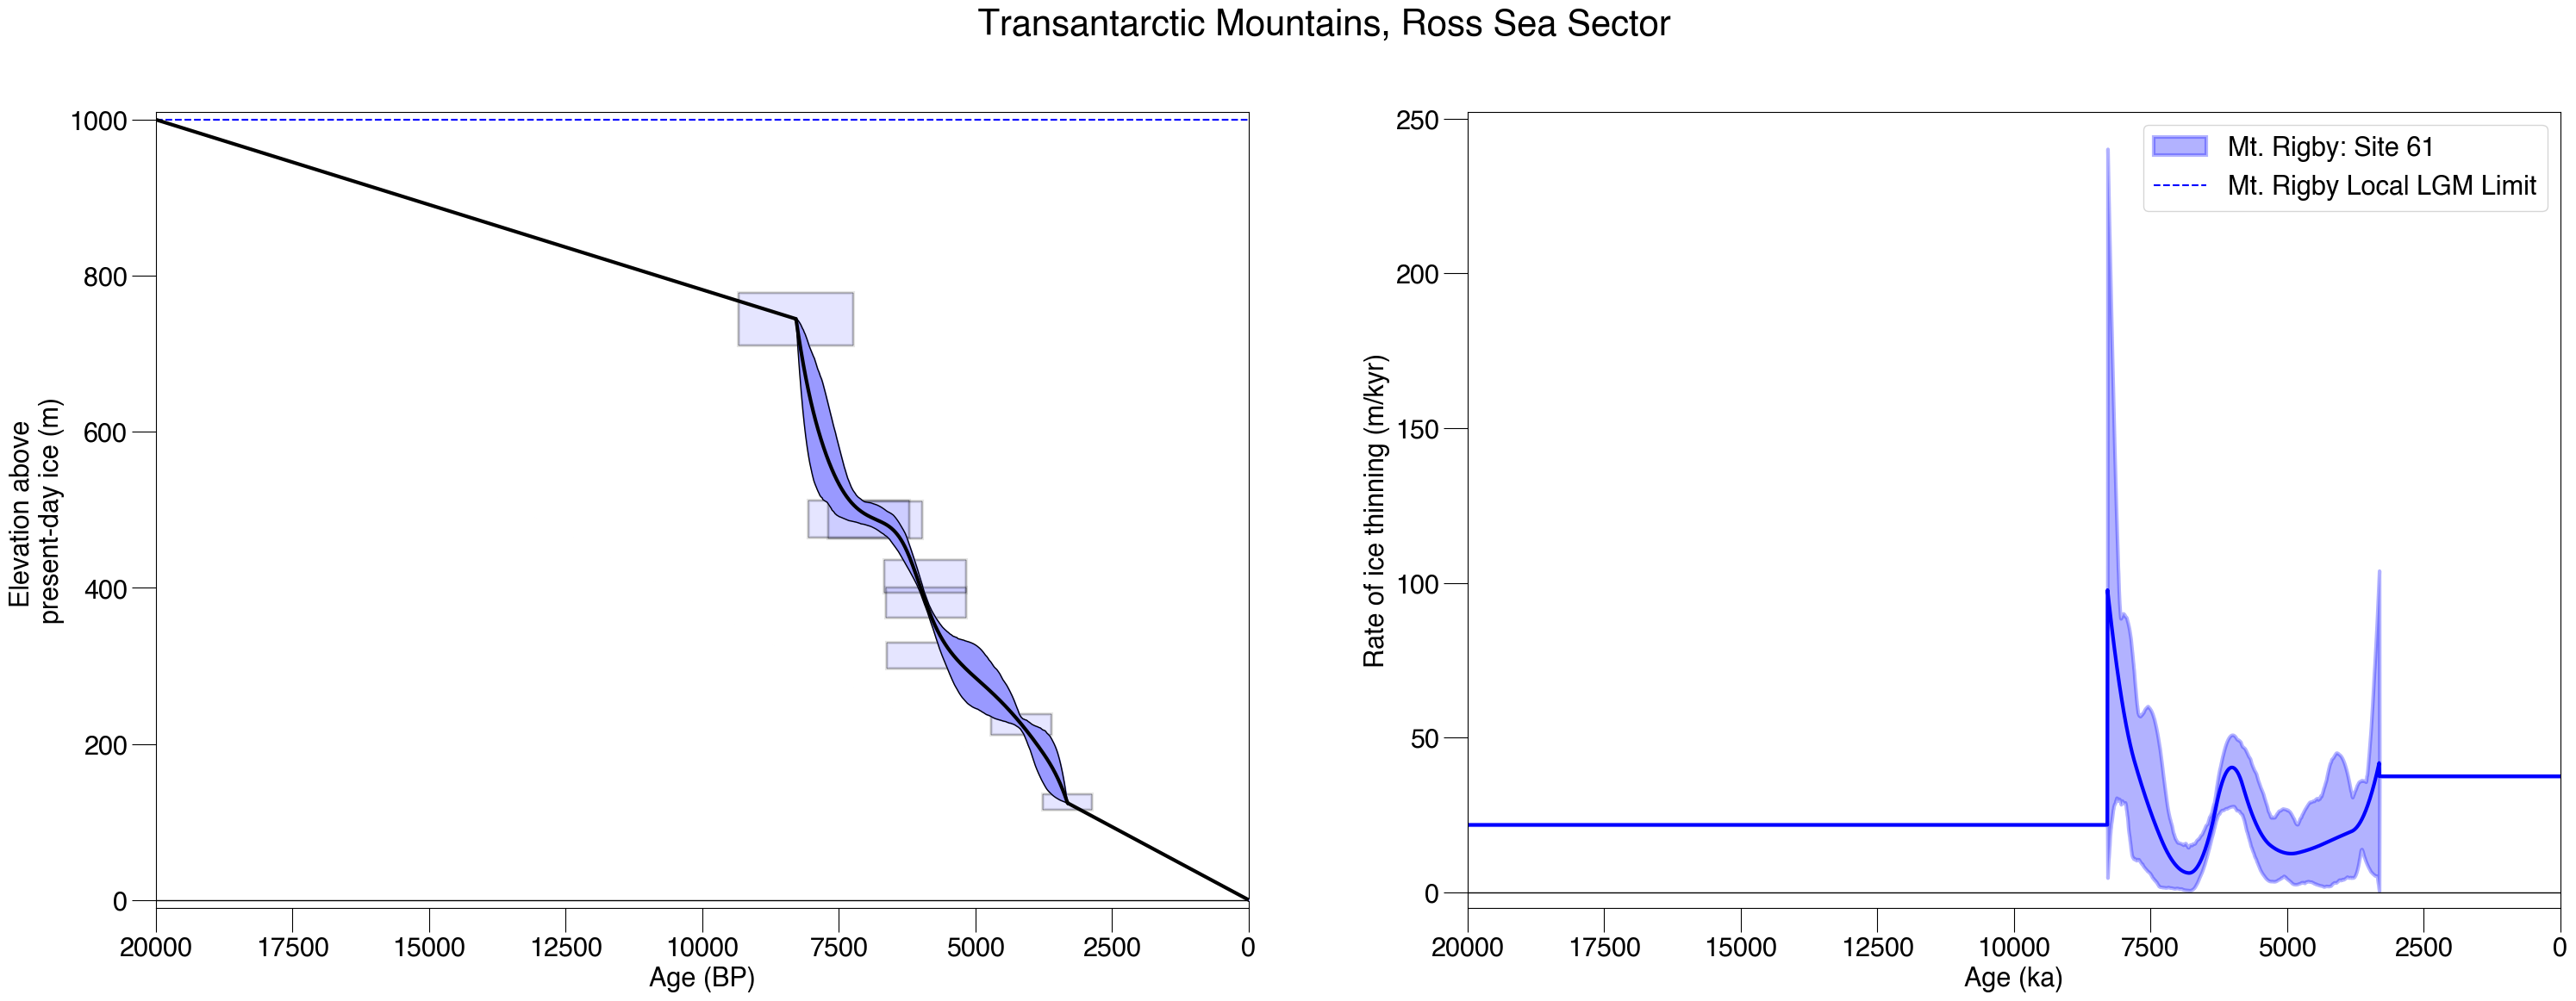

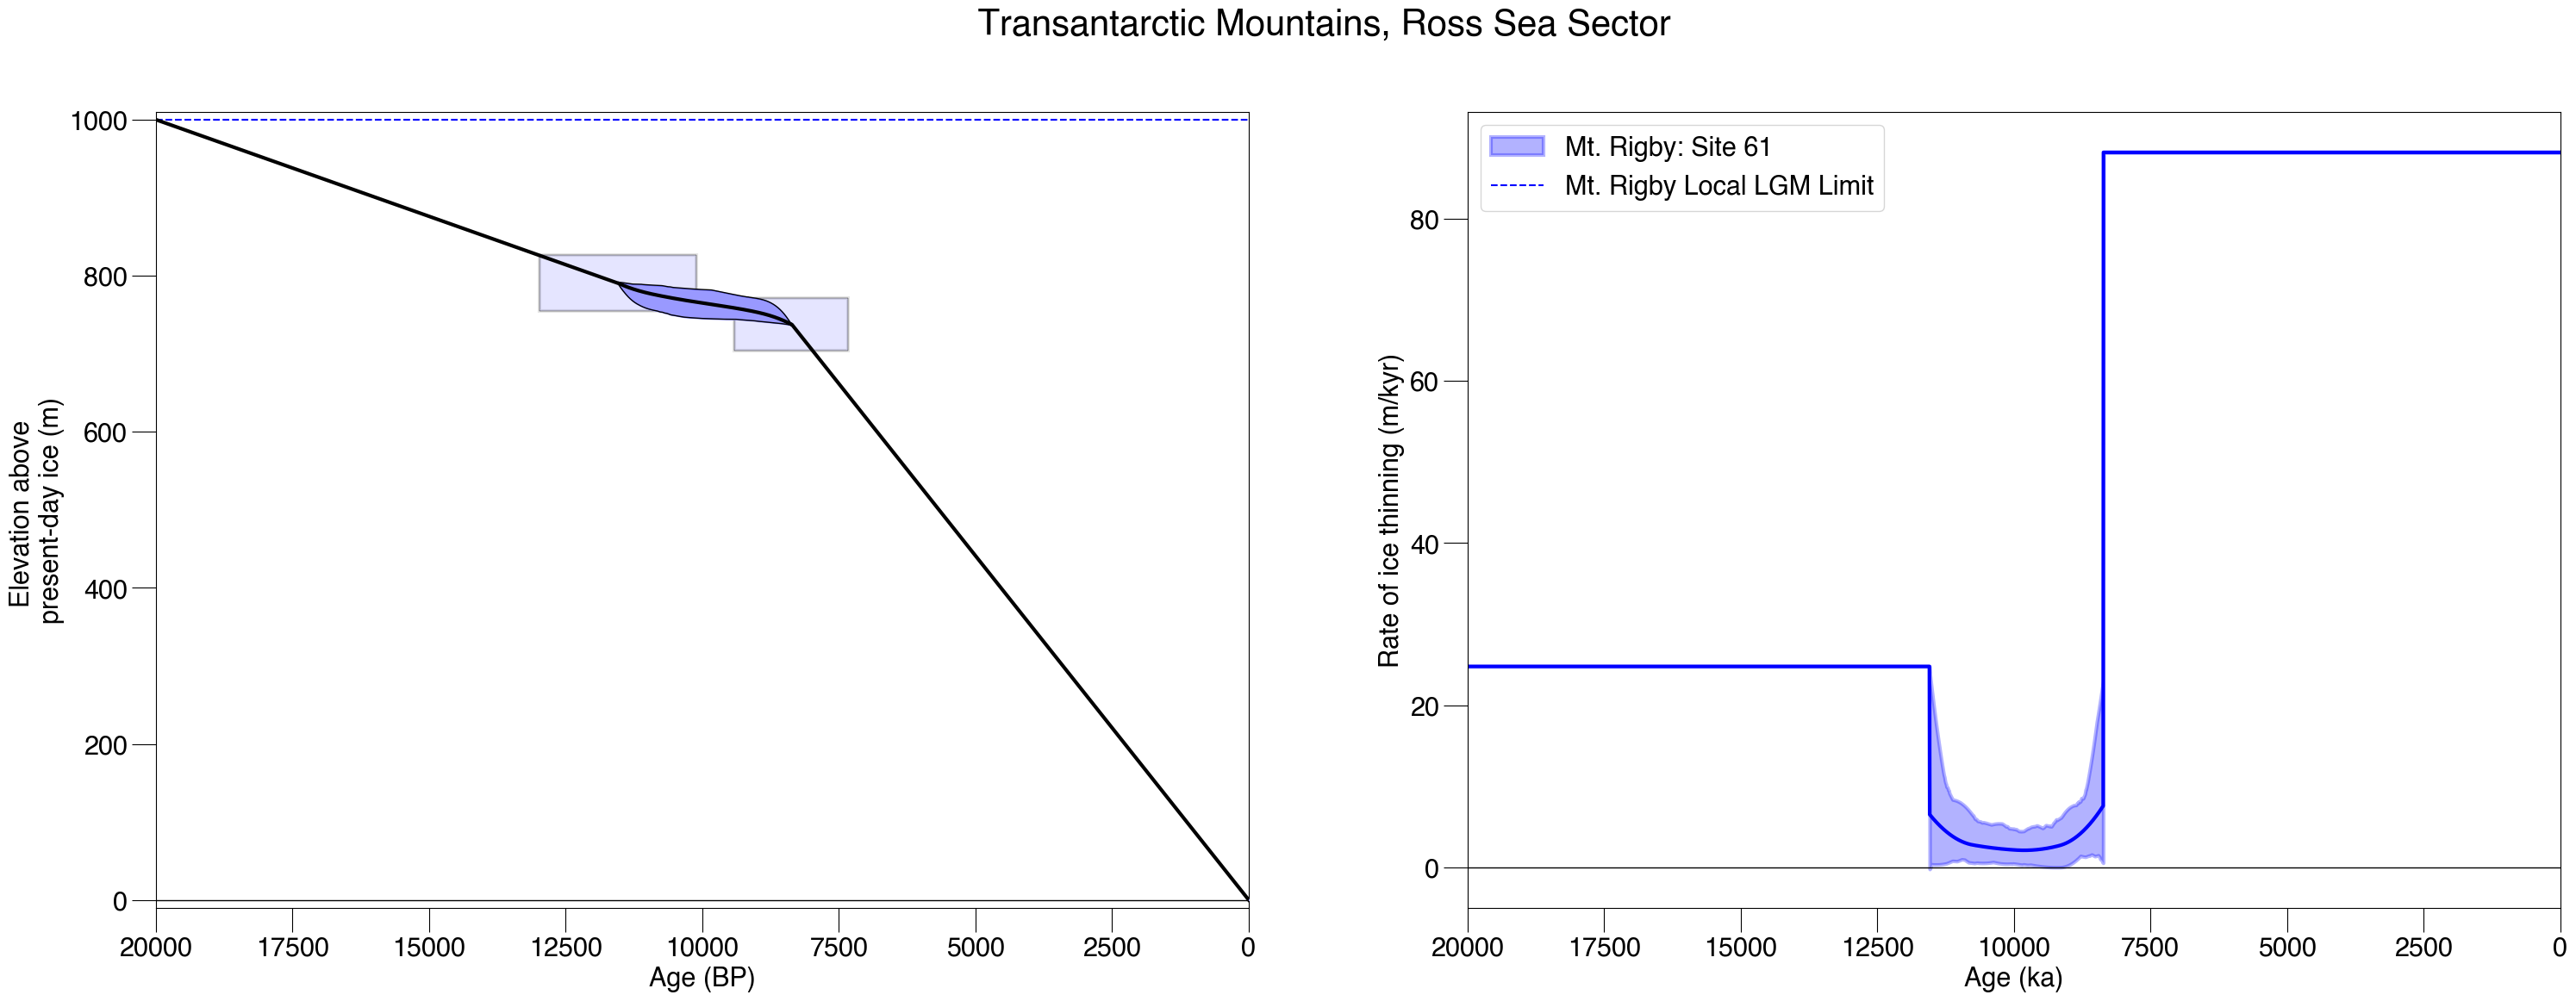

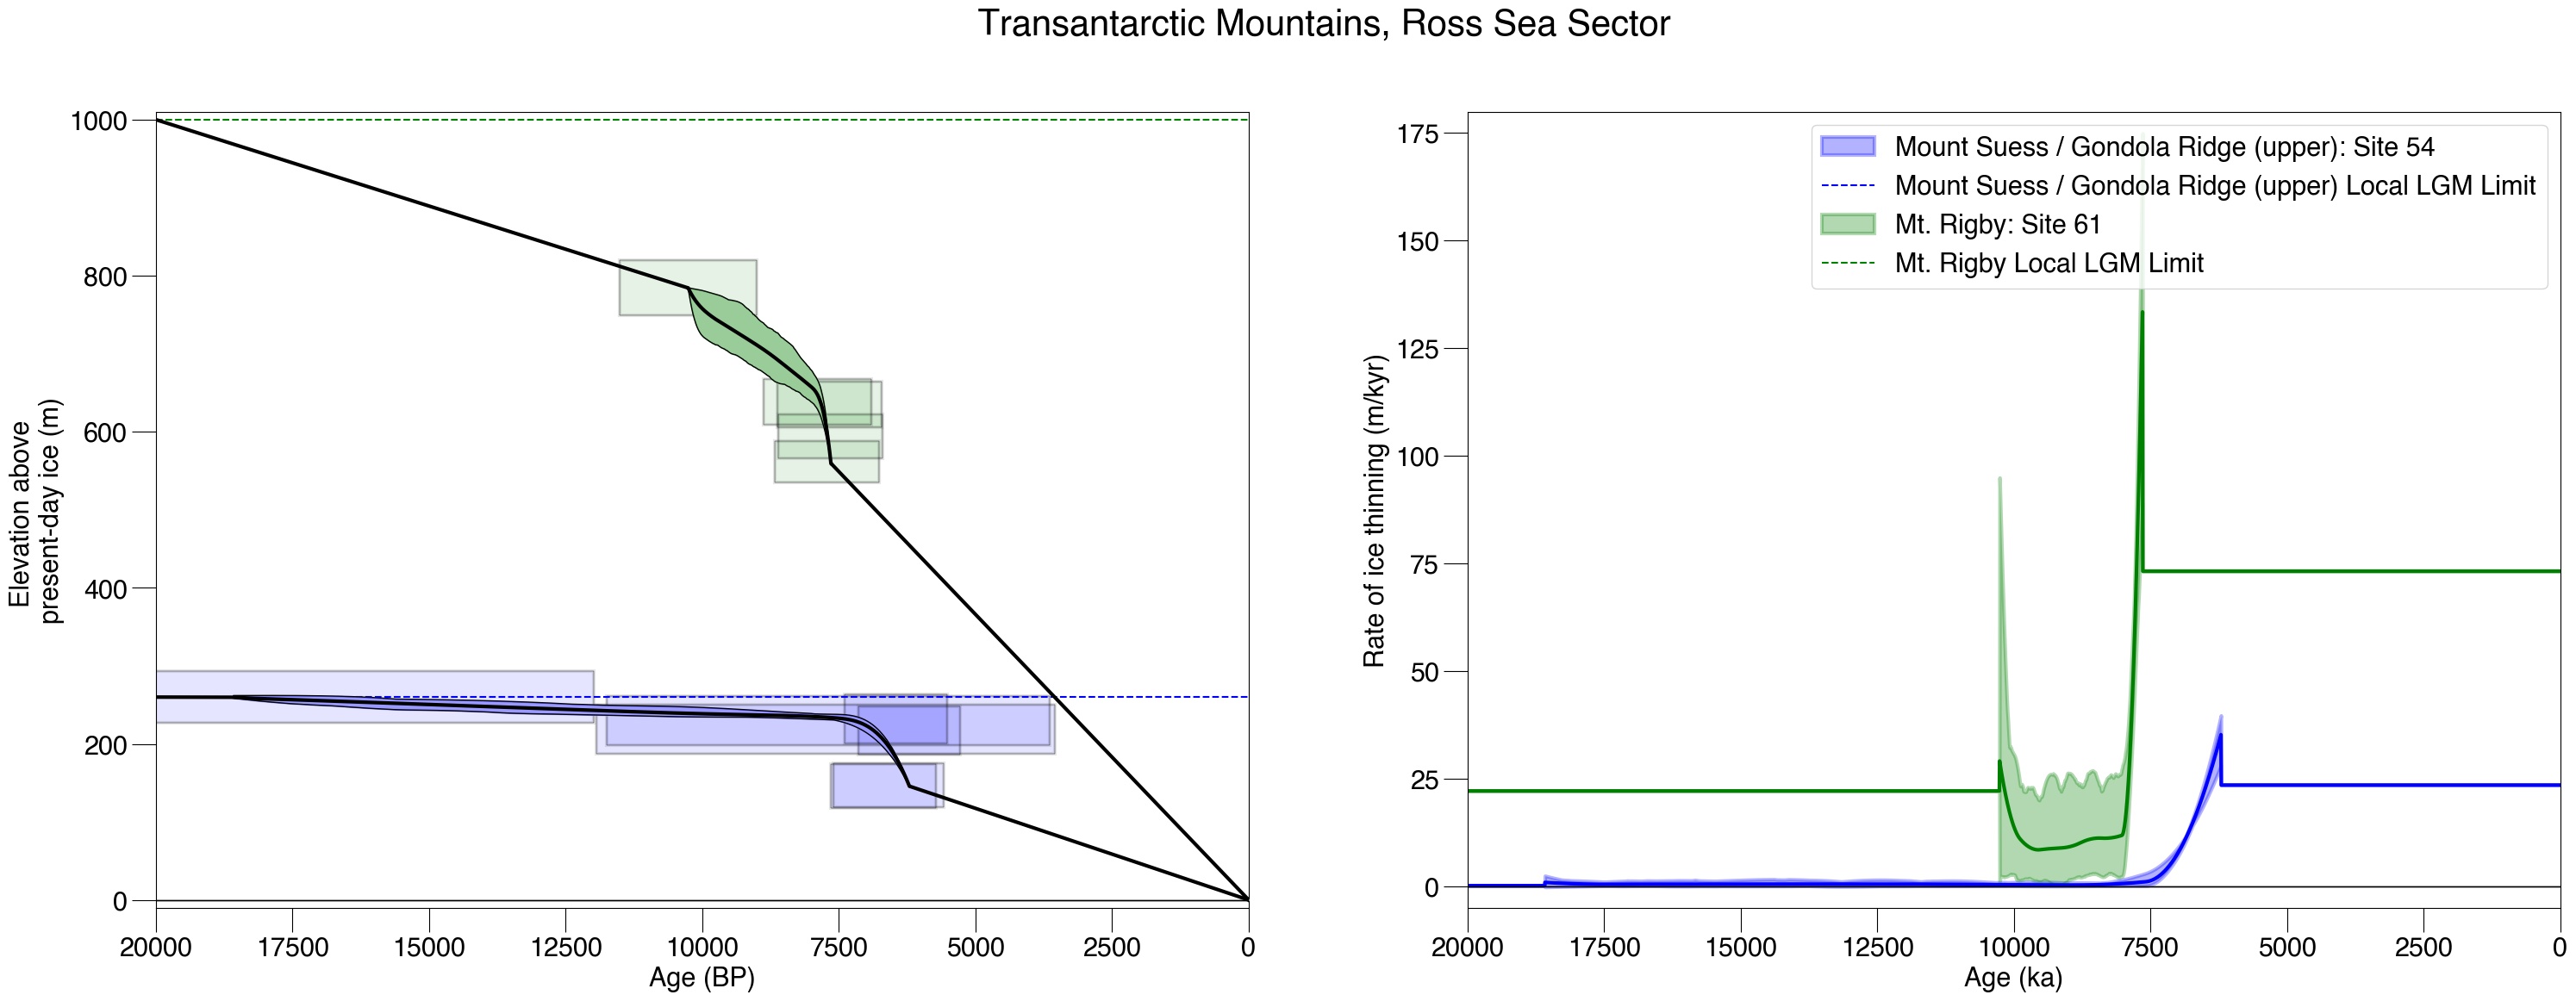

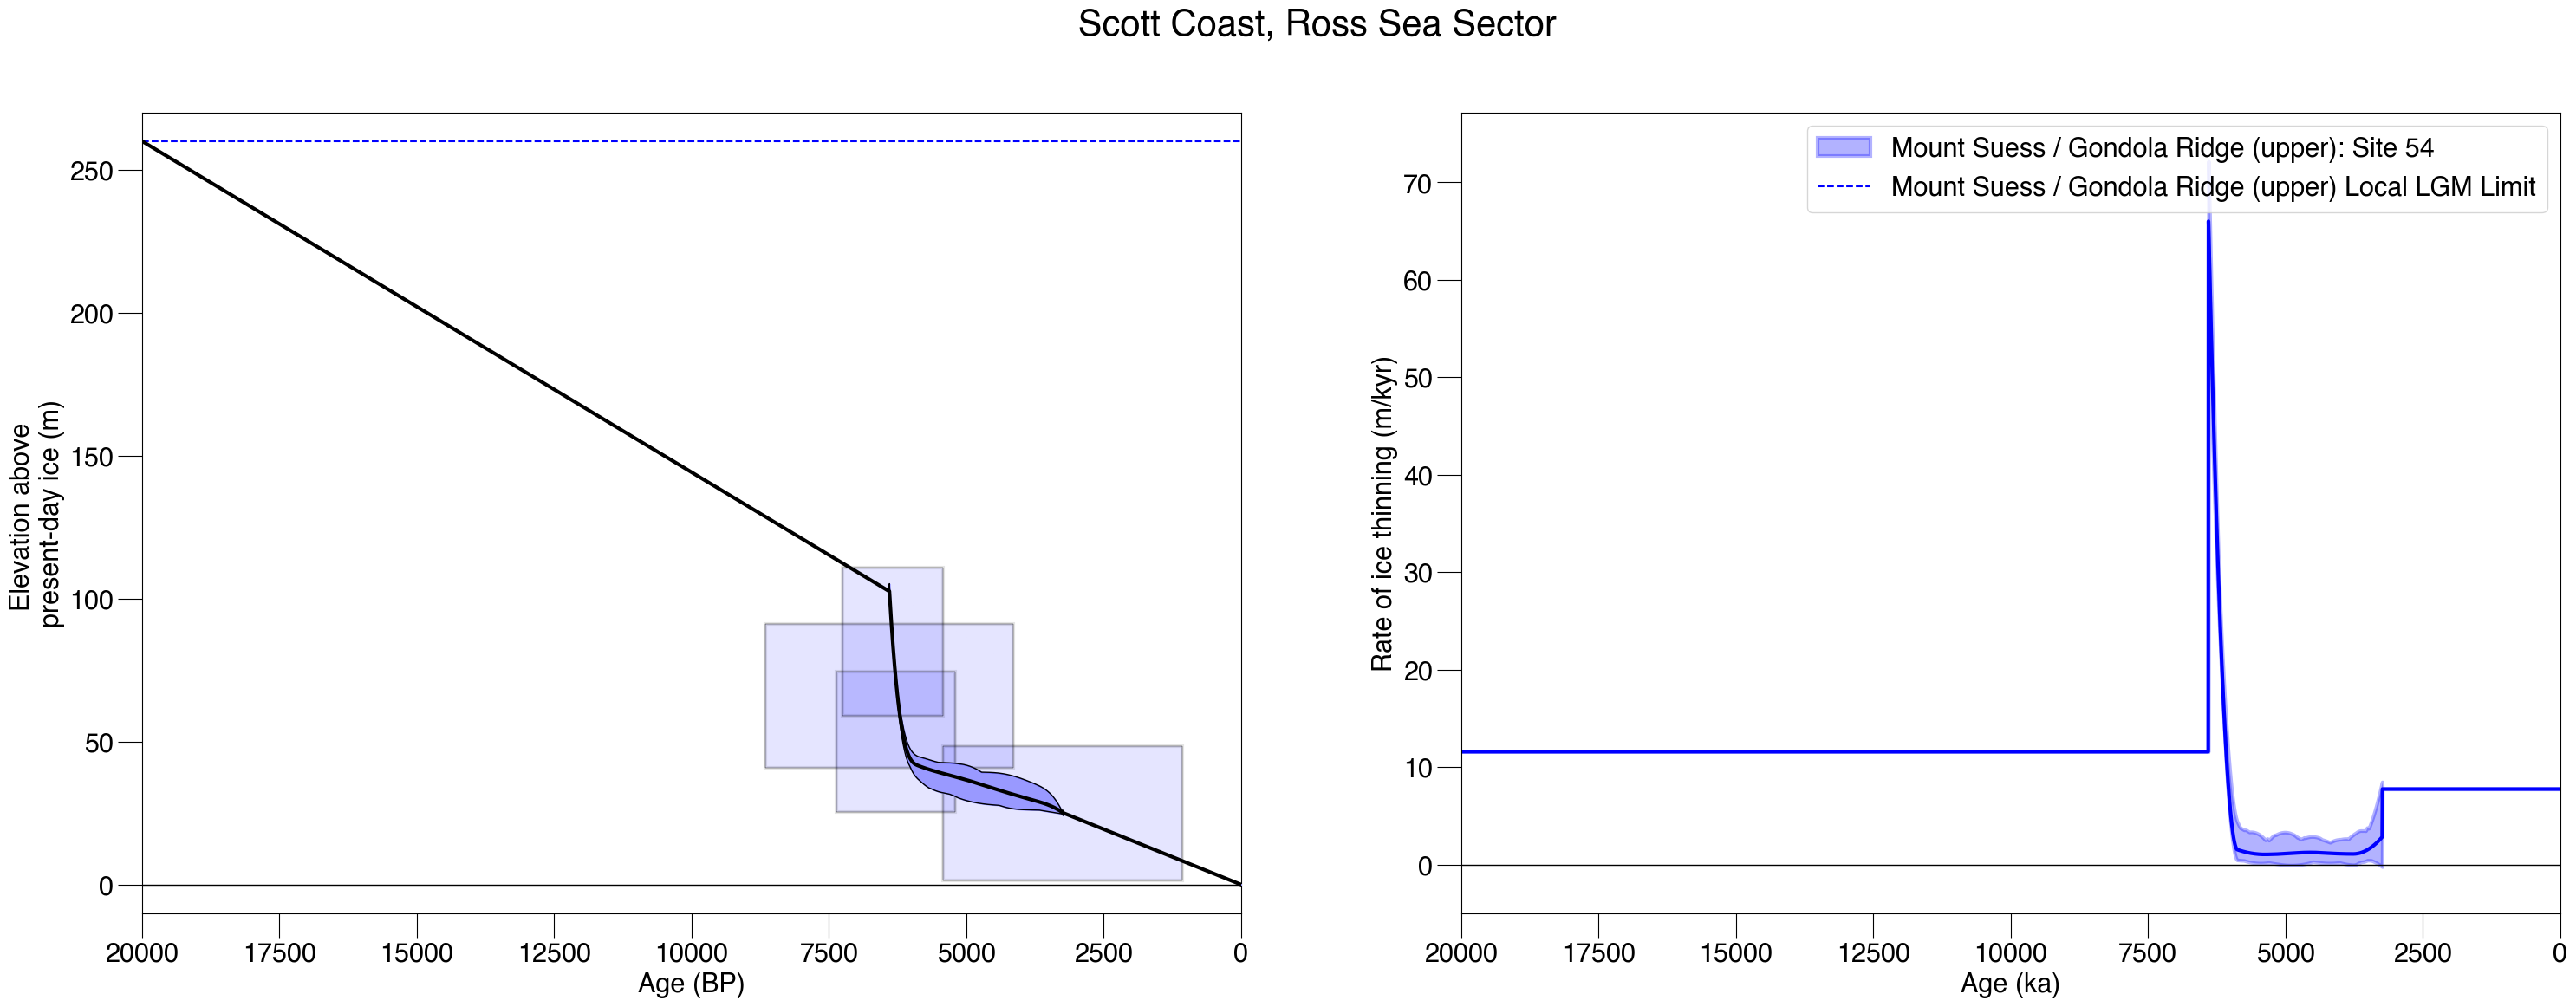

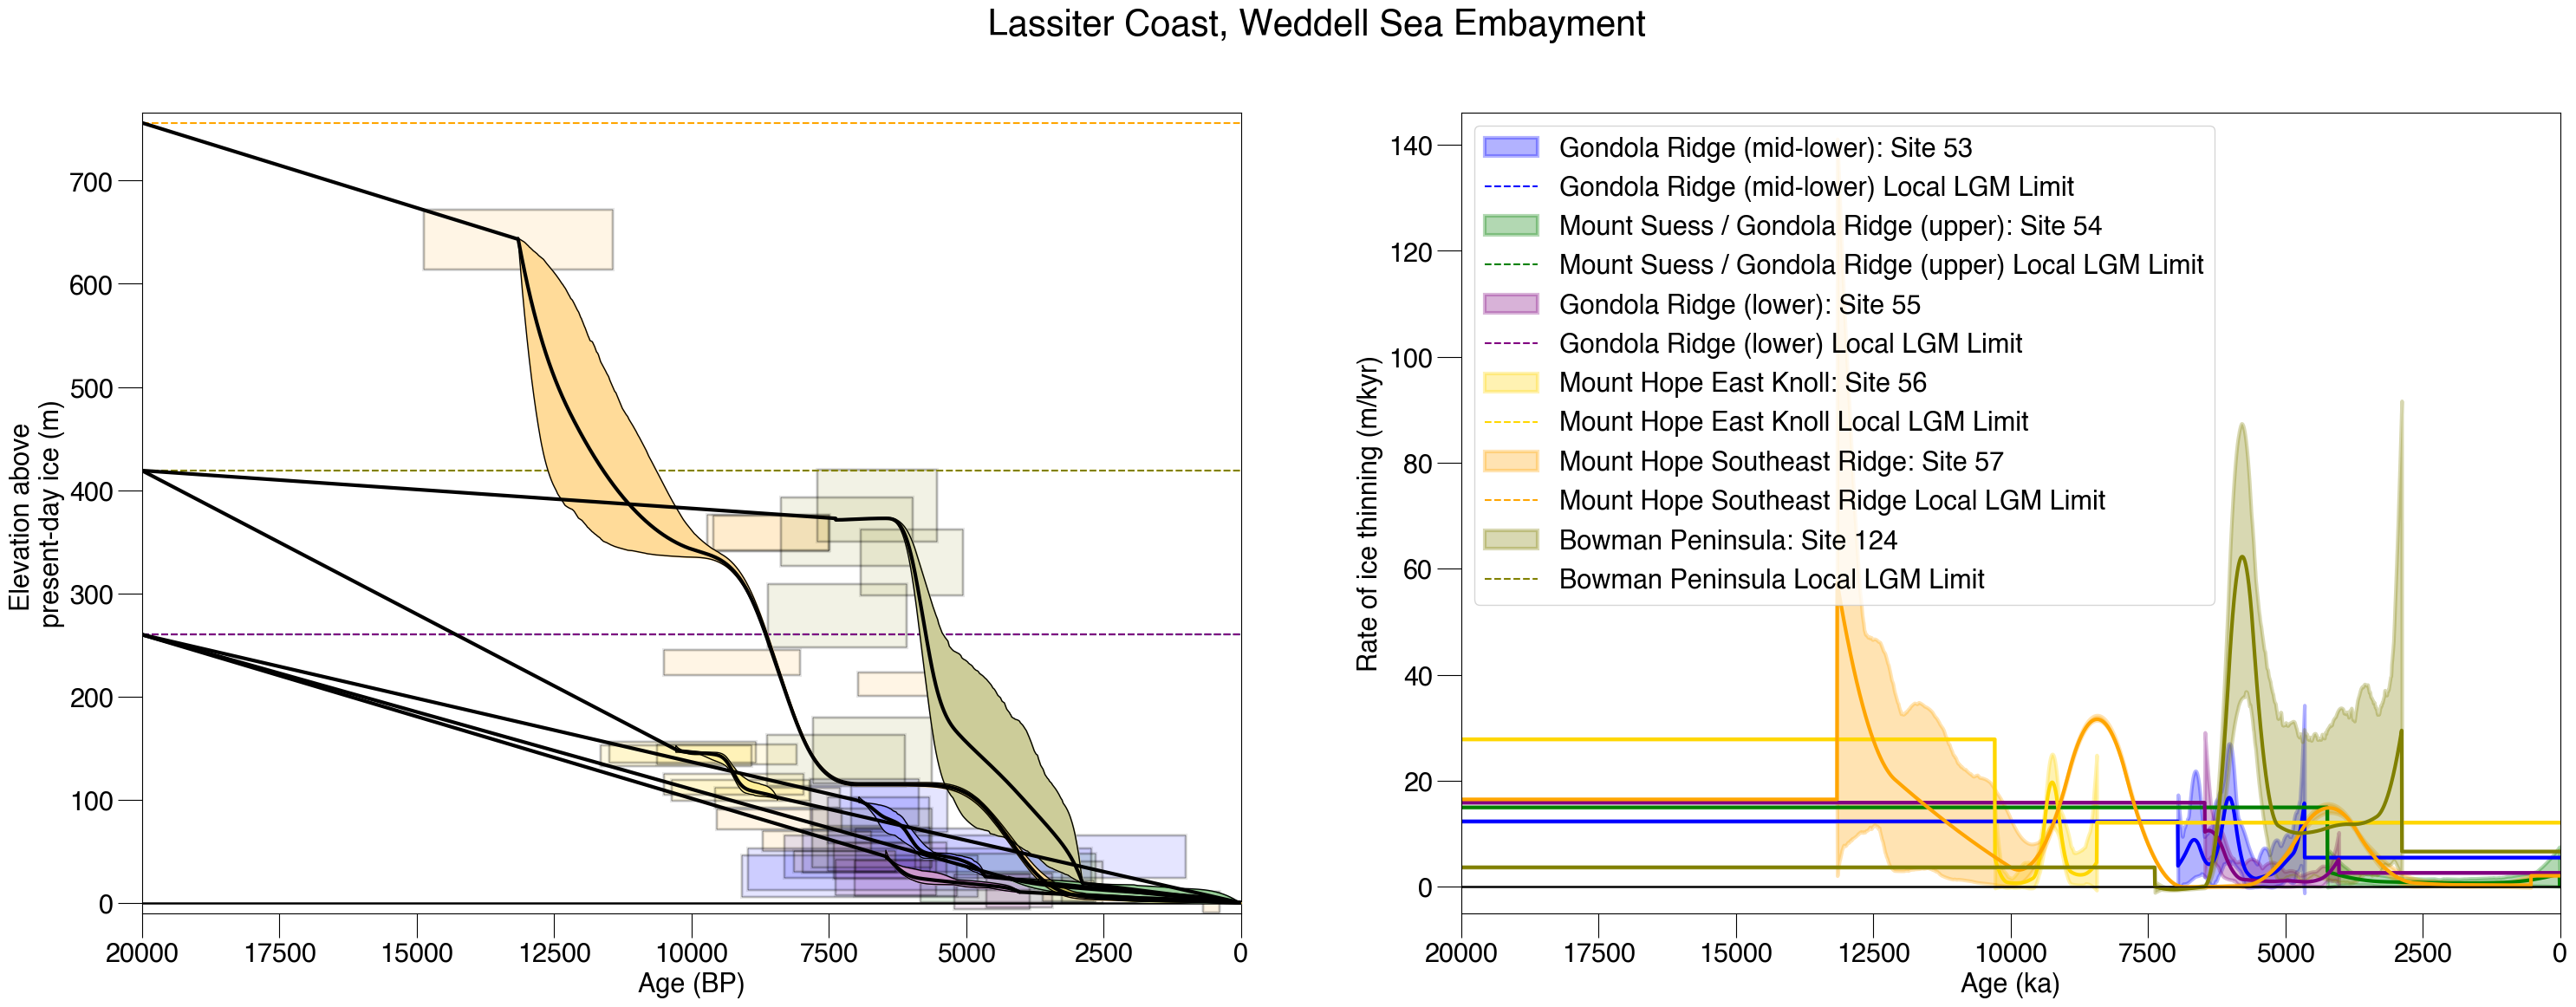

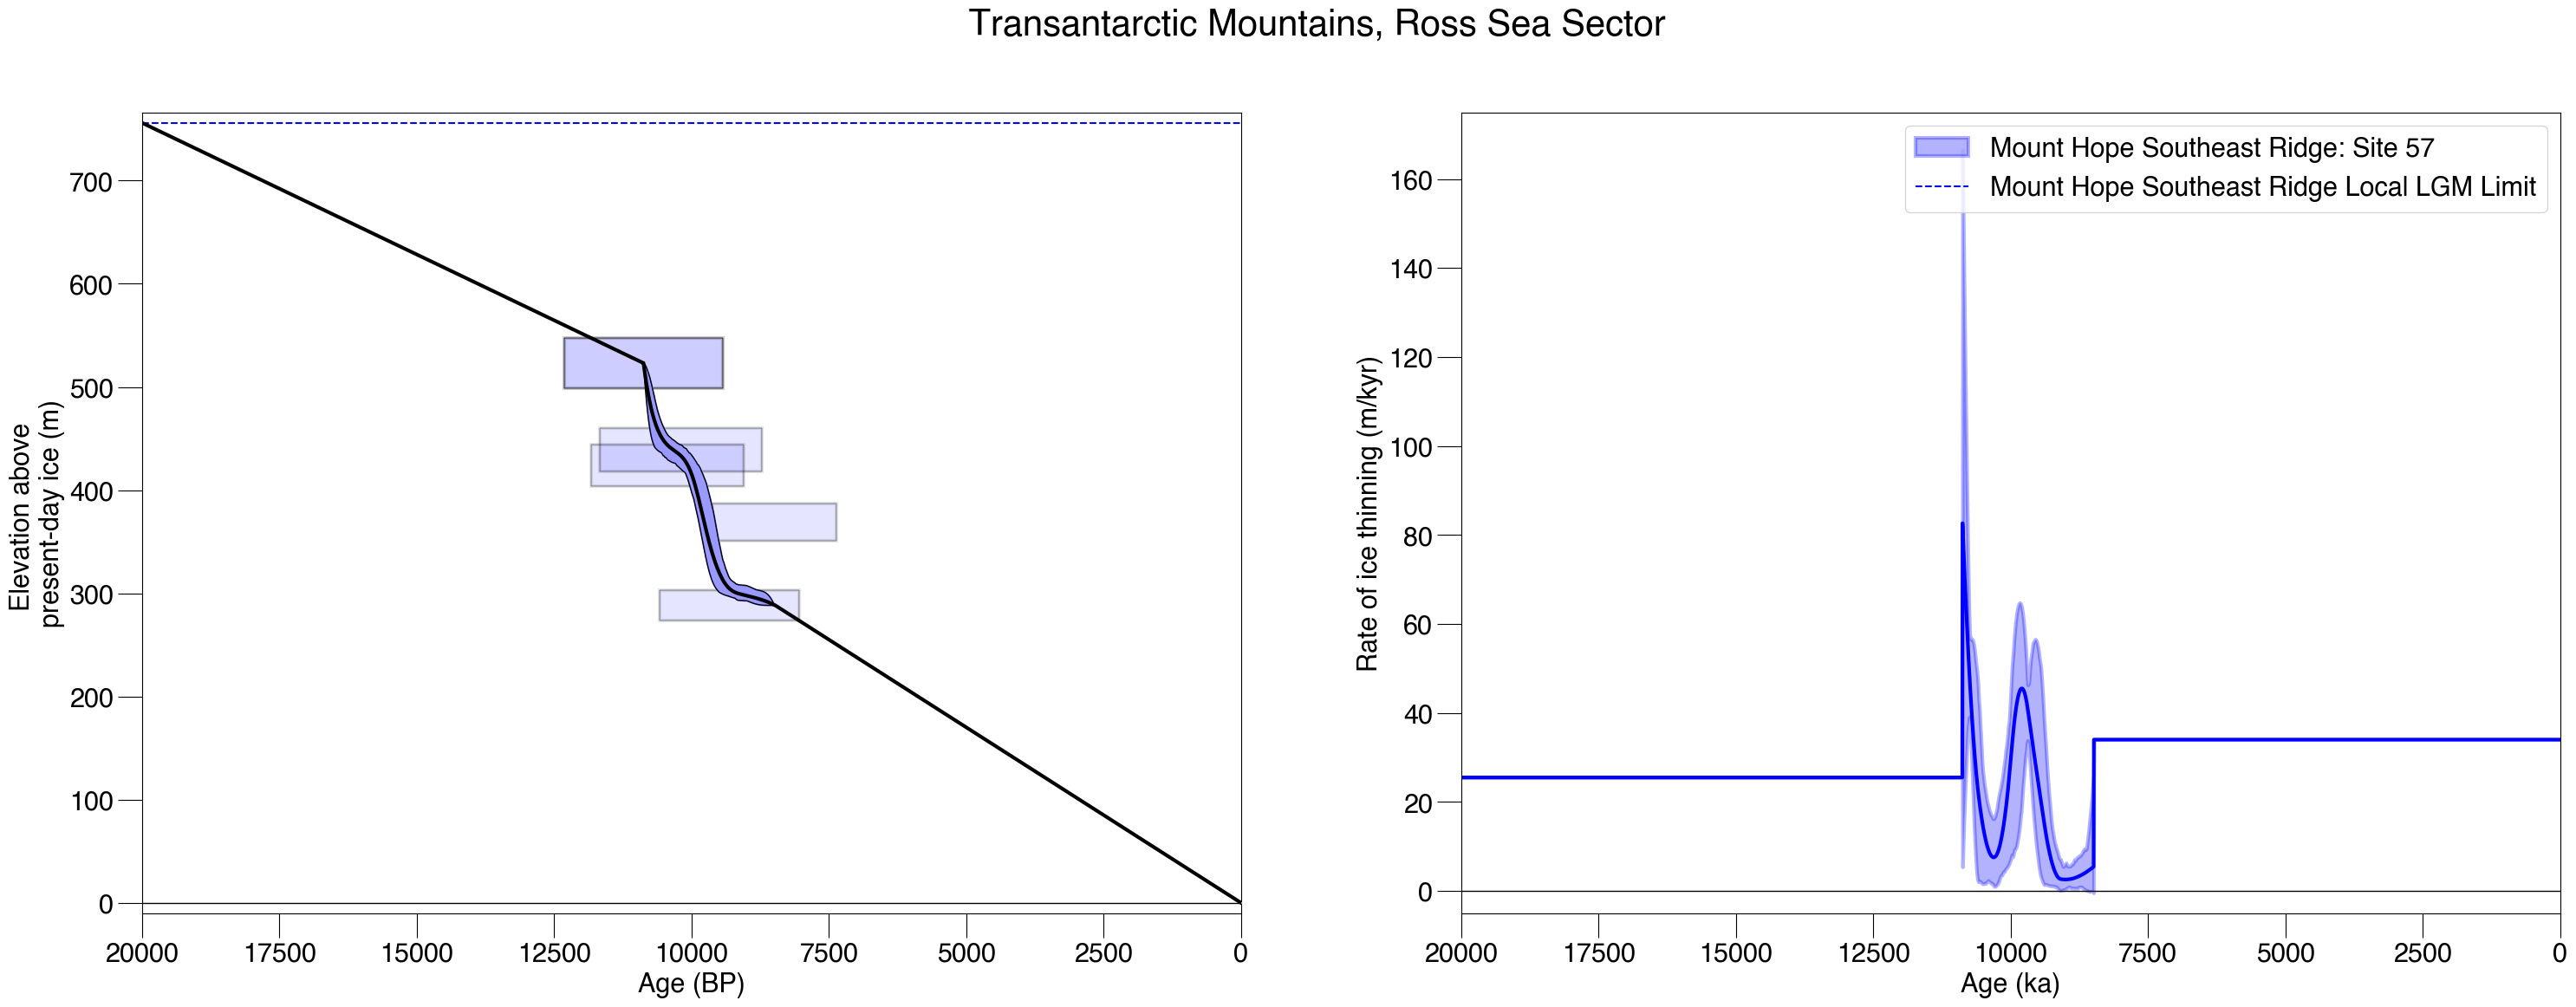

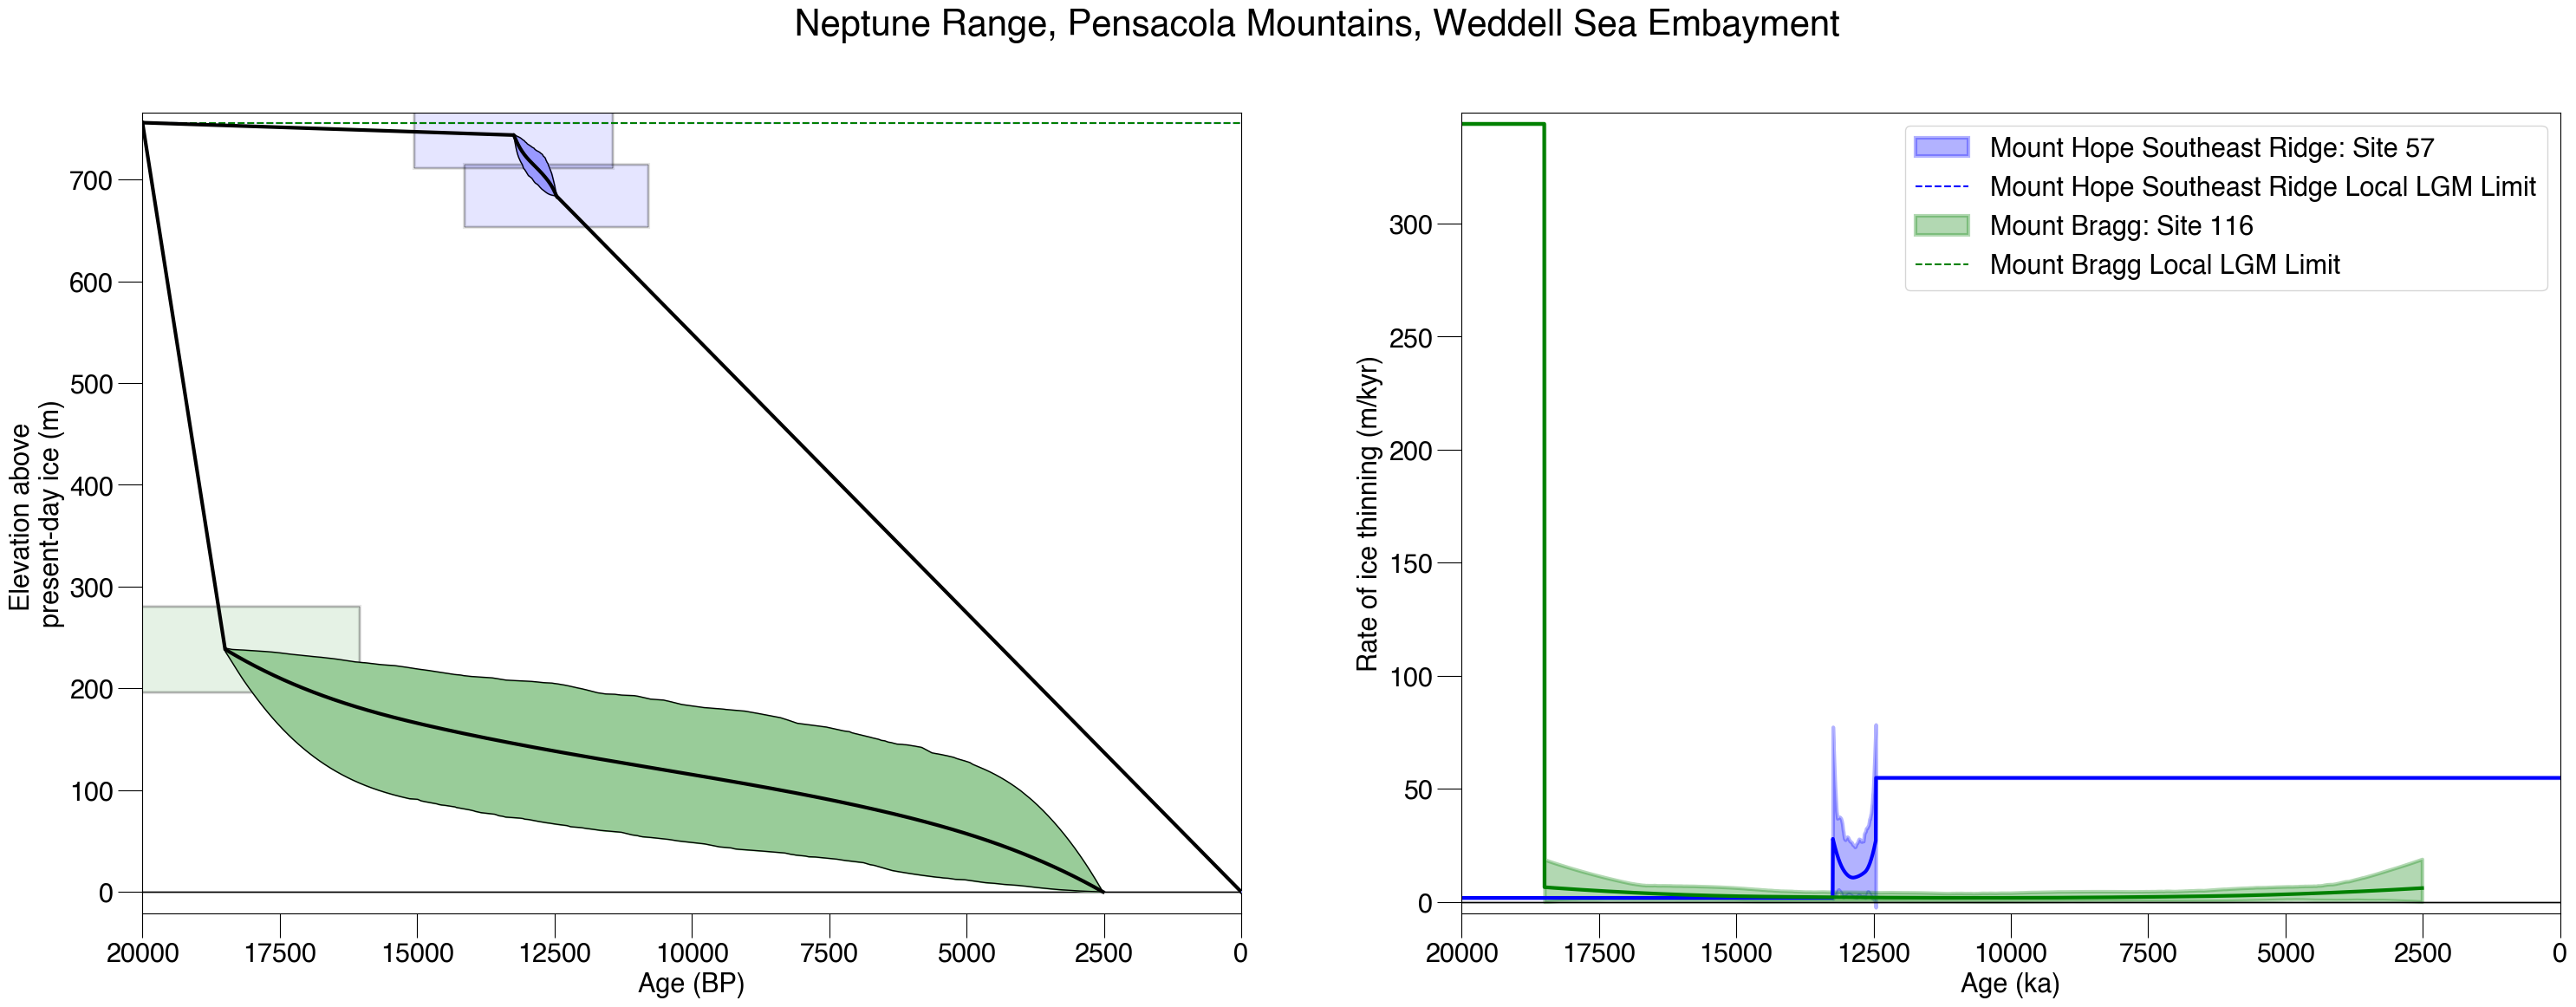

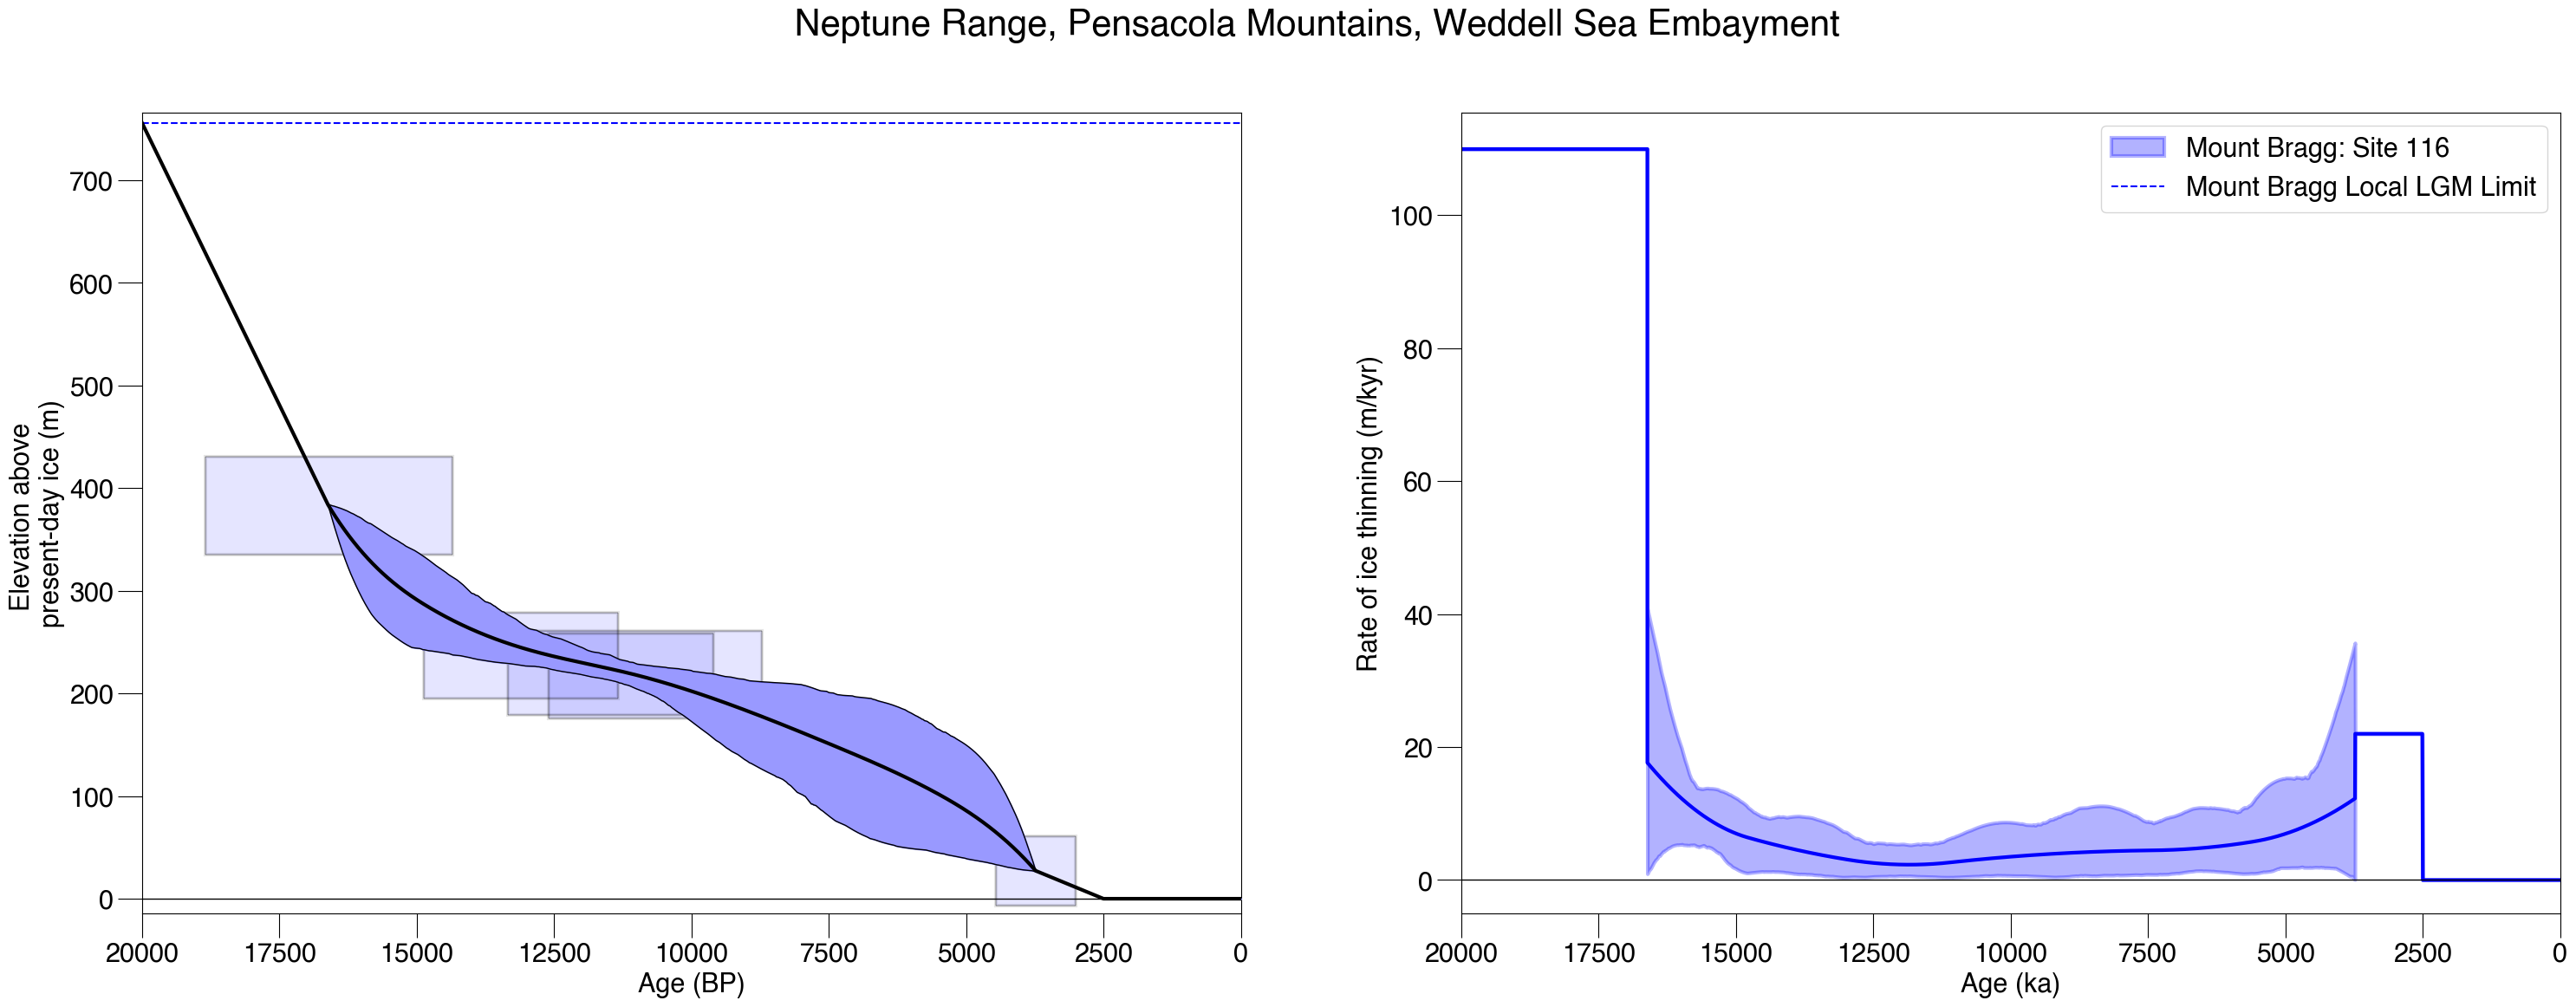

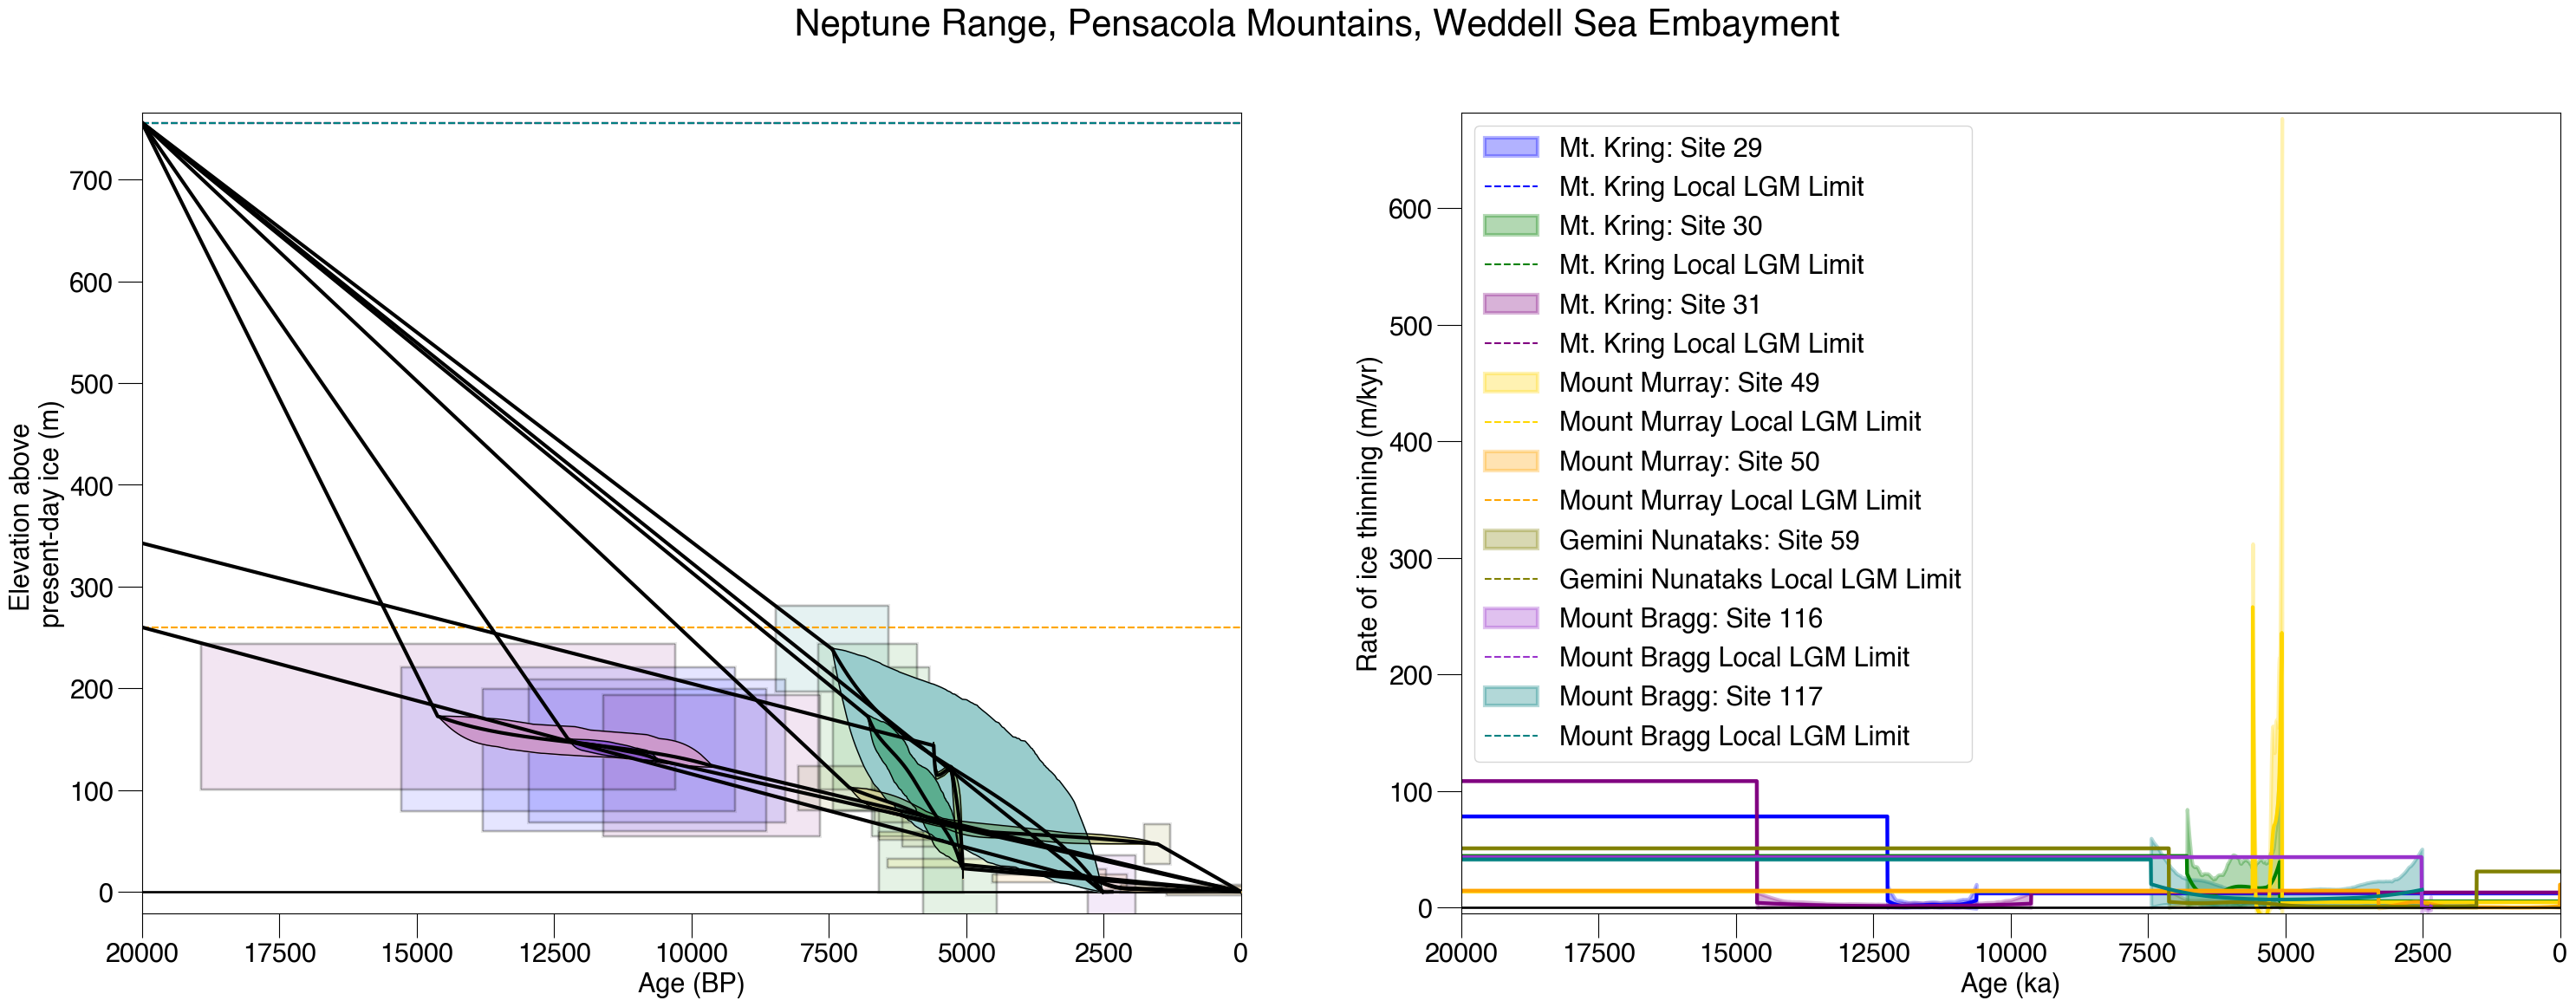

In [46]:
## Defining a list of colors for plotting 
ncolors = ['blue', 'green', 'purple', 'gold', 'orange', 'olive', 
           'darkorchid', 'teal', 'pink', 'dodgerblue', 'turquoise', 
           'saddlebrown', 'seagreen', 'mediumpurple', 'honeydew']

# Iterate over sensitivity tests; currently only "X' is used 
for SENSITIVITY_TEST in ['X']:
                   
# for SENSITIVITY_TEST in ['C3b', 'C3c', 'C4b', 'C4c', 'C5a', 'C5b', 'C5c', 'C6a', 'C6b', 'C6c', 'C7','C7a', 'C7b', 'C7c',
#                         'C8a', 'C8b', 'C8c', 'C9a', 'C9b', 'C9c', 'C10a', 'C10b', 'C10c', 'C1', ]:
# for SENSITIVITY_TEST in ['C7b', 'C7c',
#                         'C8a', 'C8b', 'C8c', 'C9a', 'C9b', 'C9c', 'C10a', 'C10b', 'C10c']:
    
    print(SENSITIVITY_TEST)
    
     # Load in data, process, and identify rejected data
    data_in, data, data_rejected = load_data('Thickness Time Series EXPANDED (2).xlsx', SENSITIVITY_TEST=SENSITIVITY_TEST)
    data_rejected_hasrelelv = data_rejected[data_rejected.rel_elv_m > 0]

    # Set parameters for Bayesian spline fitting 
    xstep=5
    nstep = 5
    n_samples=1000
    if SENSITIVITY_TEST == 'C10a':
        n_samples=500
    if SENSITIVITY_TEST == 'C10b':
        n_samples=2000
    if SENSITIVITY_TEST == 'C10c':
        n_samples=3000
    
    

    ##################################################################
    ############# ITERATE THROUGH DATA ###############################
    ##################################################################

    dses = []

    # Group data by cluster and process each cluster individually 
    for clustername, cluster in data.sort_values('Group').groupby('cluster'):
    
        # if int(clustername) < 50:
        #     continue 
    
        # if int(clustername) > 14:
        #     continue 
        # if 'YES' not in cluster['upper bound LGM ice extent?'].values[0]:
        #     continue
        
        # Make figure for each DOI
        fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(36, 12))
        yhi = 0
        xhi = 0
        for i, (name, grp) in enumerate(cluster.groupby('Group')):
    
            # if int(name) > 1:
            #     continue 
            
            # if int(name) > 30:
            #     break
    
    
            # local_name = grp.local_name.iloc[0]
            regionnames = grp[['local_name', 'subregion_name', 'Region']].dropna(how='all', axis=1)
            fullname = regionnames.apply(lambda x: ', '.join(x[x.notnull()]), axis = 1).iloc[0]
            legendname = fullname.split(',')[0] + ': Site ' + str(name) 
            titlename = ','.join(fullname.split(',')[1:]) 
    
            print(i, 'name =', titlename, '; clustername =', clustername)
    
            # If site only has one datum
            # Add in a datum at date when paper says ice elev reaches present 
            if len(grp) == 1:
                
                zeroage = grp['Best guess at when thickness reaches present'].max() * -1
            
                # Make it stop at no less than 20 to make it numerically stable
                zeroage = zeroage - 20 
                newrow = grp.iloc[-1]
                newrow['elv_comp'] = 0
                newrow['elv_err'] = 0.1
                newrow['age'] = zeroage
                newrow['age_err'] = 0.1
                newrow['name'] = 'zeropoint'
                grp = pd.concat([grp, pd.DataFrame(newrow).T])
                
            # Prepare data for fitting 
            x, y, xerrs, yerrs = make_data_xy(grp)
    
        
            ########## FIT P-SPLINE TO DATA ##############
            
            # Run Baysian spline fitting 
            outputs = run_bayesian_spline(x, xerrs, y, yerrs, n_samples=n_samples, SENSITIVITY_TEST=SENSITIVITY_TEST)
                # print('doing spline')
    
            # Except:
                #outputs = apply_ODR_to_elvs(x, y, xerrs, yerrs, nstep=nstep, n_bootstrap=n_samples)
                # print('doing ODR')

            # Extract outputs from spline fitting 
            x_fine, y_fine, lower_bound, upper_bound, bootstrap_samples = outputs[:5]
            mean_rate, rate_upper, rate_lower, rate_of_change_samples = outputs[5:]
    
                    
            # Convert 5 yr timestep to m/kyr
            mean_rate = mean_rate * 200
            rate_upper = rate_upper * 200
            rate_lower = rate_lower * 200
            rate_of_change_samples = rate_of_change_samples * 200
                
             
            # Get full timeseries x from 0 to 20000 in 5 yr timesteps
            fullmin = np.minimum(0, x_fine.min())
            
            fulltime = np.arange(fullmin, 20000.000001, 5)
    
            # Get the part of these before 
            lo = fulltime[fulltime < x_fine.min()]
            hi = fulltime[fulltime > x_fine.max()]
    
            #Catch instances where duplicates occur
            if round(lo[-1], 4) == x_fine[0]:
                lo = lo[:-1]
                # print('in')
    
            if len(hi) > 0:
                if round(hi[0], 4) == x_fine[-1]:
                    hi = hi[1:]
                    # print('in')
    
            
            loz = np.zeros(len(lo))*np.nan
            loz_rate = loz
            hiz = np.zeros(len(hi))*np.nan
            hiz_rate = hiz
    
            hitszero = grp['Best guess at when thickness reaches present'].max() 

            # Handle pre-data extrapolation 
            if y_fine.min() > 0:
    
                loz = np.linspace(0, y_fine.min(), len(lo))
    
                # do something different if it hits zero early
                if hitszero > 0:
    
                    len_lo_changing = len(lo[lo > hitszero])
                    loz_changing = np.linspace(0, y_fine.min(), len_lo_changing)
                    loz_zero = np.zeros(len(lo[lo <= hitszero]))
                    loz = np.concatenate([loz_zero, loz_changing])
    
                loz_rate = np.gradient(loz) * 200
    
            # Handle post data extrapolation   
            if 'YES' in grp['upper bound LGM ice extent?'].mode()[0]:
                
                if grp['rel_elv_LGM_m'].mean() > 0:
                    hiz = np.linspace(y_fine.max(), grp['rel_elv_LGM_m'].mean(), len(hi))
                    hiz_rate = np.gradient(hiz) * 200
                    
                else:
                    # hiz = np.ones(len(hi)) * y_fine.max()
                    hiz_rate = np.zeros(len(hi))
    
            # Combine time and elevation data 
            ages_post = np.concatenate([lo, x_fine, hi])
            elv_post = np.concatenate([loz, y_fine, hiz])    
            elv_lo_bound = np.concatenate([loz, lower_bound, hiz]) 
            elv_hi_bound = np.concatenate([loz, upper_bound, hiz]) 
            
            elv_rate_post = np.concatenate([loz_rate, mean_rate, hiz_rate]) 
            elv_rate_lo_bound = np.concatenate([loz_rate, rate_lower, hiz_rate]) 
            elv_rate_hi_bound = np.concatenate([loz_rate, rate_upper, hiz_rate]) 
    
            # Do the same for samples
            loz_samples = loz[:,None] * np.ones(n_samples)[:,None].T
            loz_samples_rate = loz_rate[:,None] * np.ones(n_samples)[:,None].T
            
            hiz_samples = hiz[:,None] * np.ones(n_samples)[:,None].T
            hiz_samples_rate = hiz_rate[:,None] * np.ones(n_samples)[:,None].T
    
            elv_post_samples = np.concatenate([loz_samples, bootstrap_samples, hiz_samples]) 
            elv_post_rate_samples = np.concatenate([loz_samples_rate, rate_of_change_samples, hiz_samples_rate]) 
    
            # Create xrray dataset for the cluster 
            if np.nanmax(elv_post) < 2e3:
                ds = xr.Dataset(
                    data_vars=dict(
                        elv_post=(["age", "site"], elv_post[:, None] ),
                        # elv_lo_bound=(["age", "site"], elv_lo_bound[:, None] ),
                        # elv_hi_bound=(["age", "site"], elv_hi_bound[:, None] ),
                        elv_rate_post=(["age", "site"], elv_rate_post[:, None] ),
                        # elv_rate_lo_bound=(["age", "site"], elv_rate_post[:, None] ),
                        
                        elv_post_samples=(["age", "samples","site"], elv_post_samples[:, :, None] ),
                        elv_post_rate_samples=(["age", "samples","site"], elv_post_rate_samples[:, :, None] ),
                        
                    ),
                    coords=dict(age=ages_post,
                                site=[name],
                                lat=(["site"], [grp.lat_DD.mean()]),
                                lon=(["site"], [grp.lon_DD.mean()]),
                                samples=np.arange(n_samples),
                                cluster=grp.cluster.mean(),
                                cluster_weight=grp.cluster_weights.mean(),
                               ),
                )
                
                # Interp down to 10 year resolution
                # ds = ds.interp(age=fulltime[::2]).sel(samples=np.arange(n_samples)[::2]).chunk('auto')
                ds = ds.interp(age=fulltime[::2]).sel(samples=np.arange(n_samples)).chunk('auto')
                
                dses.append(ds)
                
    
            # Set highest point for plot
            yhi_it = cluster.elv_comp.max() + cluster.elv_err.mean() * 2 + 10   
            xhi_it = (cluster.age * -1).max() + (cluster.age_err.mean() * 2) + 500
            
            ###### Set LGM Limit ######
    
            # Default to no limit
            LGM_lim = 0
    
            # if limit, set it as max of y data unless into otherwise
            if 'YES' in grp['upper bound LGM ice extent?'].mode()[0]:
    
                LGM_lim = y.max()
    
                if not grp['rel_elv_LGM_m'].mode().empty:
                    LGM_lim = grp['rel_elv_LGM_m'].mode()[0]
                    yhi_it = np.maximum(yhi, np.nanmax(cluster['rel_elv_LGM_m']) + 10)
                    xhi_it = 20000
    
            yhi = np.maximum(yhi, yhi_it)
            xhi = np.maximum(xhi, xhi_it)
    

            # If int(name) < 2:
            if 1:
                fig, axes = plot_tem_regression(x,y,xerrs,yerrs,ages_post,elv_post,elv_lo_bound, 
                                                elv_hi_bound, elv_rate_post, elv_rate_lo_bound, elv_rate_hi_bound, 
                                                titlename, color=ncolors[i],  fig=fig, axes=axes, placename=legendname,
                                                yhi=yhi, xhi=xhi, LGM_lim=LGM_lim)
                fig.suptitle(titlename, fontsize=30)
                axes[0].invert_xaxis()  # Invert x-axis for the first subplot
                axes[1].invert_xaxis()
            for ax in axes:
                ax.grid(False)
                
                # Add rejected data to plot
                ##plot_uncertainty_boxes(x_rej, y_rej, xerrs_rej, yerrs_rej, 
                                       #ax=axes[0], ec='grey', fc='lightgrey', alpha=0.8, zorder=0)
                # break  
            
        # If int(name) < 2:
        if 0:
            fig.savefig(f'figs/timeseries/thin_ant_cluster{clustername}_{SENSITIVITY_TEST}.pdf', format='pdf', bbox_inches='tight')
            fig.savefig(f'figs/timeseries/thin_ant_cluster{clustername}_{SENSITIVITY_TEST}.png', format='png', bbox_inches='tight')

            plt.show()
        
    # Break
    ###################### SAVE ########################
    
    
    ds_sites = xr.concat(dses, dim='site')
    ds_sites
    
    ###### LOAD SKYTRAIN #########
    ds_sky = load_skytrain(ds_sites)
    ds_sky_all = plot_skytrain(ds_sky)
    
    ####################### ADD  SEGMENTED LINEAR REGRESSION TO SITES #######
    
    ds_sites = xr.concat([ds_sites], dim='site').chunk(dict(site=-1))
    
    ds_sites['cluster_weight'] = ds_sites['cluster_weight'] / ds_sites.cluster_weight.sum()
    
    
    ######## SAVE ds_sites #############
    
    ds_sites = ds_sites.chunk(dict(site=-1))
    
    if 0:
        # p = 'output/240714_spline_allsites.nc'
        p = f'/Volumes/black_wd/antuplift/sensitivity_tests/spline_allsites_{SENSITIVITY_TEST}.nc'
        # p = f'/Volumes/Seagate Hub/whoi/first_author/antuplift/spline_allsites_{SENSITIVITY_TEST}.nc'
        ds_sites.to_netcdf(p)
    
    # ds_sites = xr.open_dataset(p)
    
    # break
    ############## PLOT THINNING RATES ############
    make_thinning_rates_plot(ds_sites)
    
    ############## PLOT DATA DISTRIBUTION ############
    
    #make_data_distribution_fig(ds_sites)
    
    ############## PLOT FRACTION OF DATA AT DIFF THINNING RATES ############
    
    #make_site_fraction_fig(ds_sites)

In [43]:
# for site in ds_sites.site[:10]:
#     ds_sites.elv_post_samples.chunk('auto').mean('samples').sel(site=site).plot()

In [ ]:
# for sample in range(100):
#     ds_sites.elv_post_samples.chunk('auto').sel(site=121).sel(samples=sample).plot(alpha=0.2)

In [47]:
# Assuming ds_sites dataset is already loaded in the environment

# Initialize an empty DataFrame to hold the results in the required format
thickness_time_series_df = pd.DataFrame(columns=['Site', 'Age', 'Thickness', 'Latm', 'Lonm'])

# Loop over each site in the dataset using the raw NumPy values
for site in ds_sites.site.values:
    
    # --- Select the data for the current site ---
    # Select all samples for this site from elv_post_samples
    site_data = ds_sites.elv_post_samples.sel(site=site)
    
    # Replace negative values with 0.
    # Note: xarray's .clip(min=0) may not work as expected, so we use xr.where instead.
    clipped_data = xr.where(site_data < 0, 0, site_data)
    
    # Calculate the mean thickness across all samples for each age
    mean_thickness = clipped_data.mean(dim='samples')
    
    # --- Extract Age and Thickness Values ---
    # Ensure that the 'age' coordinate is available
    if 'age' not in mean_thickness.coords:
        print(f"Site {site} does not have an 'age' coordinate. Skipping.")
        continue
    
    # Extract age and thickness arrays and force them to be 1-dimensional
    age_values = mean_thickness.age.values.flatten()
    thickness_values = mean_thickness.values.flatten()
    
    # Check if any thickness values are still negative (they shouldn't be)
    if (thickness_values < 0).any():
        print(f"Unexpected negative thickness values at site {site}")
        continue
    
    # --- Extract Latitude and Longitude for this Site ---
    try:
        latm = ds_sites.lat.sel(site=site).values.item()  # Convert 1-element array to scalar
        lonm = ds_sites.lon.sel(site=site).values.item()  # Convert 1-element array to scalar
    except Exception as e:
        print(f"Error extracting lat/lon for site {site}: {e}")
        continue
    
    # --- Create a Temporary DataFrame for this Site ---
    # Repeat the site identifier and lat/lon values to match the length of the age/thickness arrays.
    temp_df = pd.DataFrame({
        'Site': [site] * len(age_values),
        'Age': age_values,
        'Thickness': thickness_values,
        'Latm': [latm] * len(age_values),
        'Lonm': [lonm] * len(age_values)
    })
    
    # Append the temporary DataFrame to the main DataFrame
    thickness_time_series_df = pd.concat([thickness_time_series_df, temp_df], ignore_index=True)

# --- Filter Out Rows with Zero or NaN Thickness ---
thickness_time_series_df = thickness_time_series_df[
    (thickness_time_series_df['Thickness'] != 0) &
    (~thickness_time_series_df['Thickness'].isna())
]

# Save the filtered thickness time series to a CSV file
output_file_path = 'thicknesstimeserieswithfull.csv'
thickness_time_series_df.to_csv(output_file_path, index=False)

print(f"\nData saved to {output_file_path}")

Error extracting lat/lon for site 123: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 142: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 123: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 128: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 142: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 128: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 129: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 129: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 152: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 151: can only convert an array of size 1 to a Python scalar
Error extracting lat/lon for site 152: can only convert an a

In [ ]:
# # Load the compiled sites data
# #file_path = 'SitesWithBedMachineSurfaceData.csv'
# df = pd.read_csv(file_path)

# # Ensure required columns exist
# if 'surface' in df.columns and 'Thickness' in df.columns:
#     # Add surface data to the thickness column
#     df['IceThicknessandSurface'] = df['surface'] + df['Thickness']
    
#     # Save the updated DataFrame to a new CSV file
#     output_path = 'compiledsiteswithupdatedthickness.csv'
#     df.to_csv(output_path, index=False)
#     print(f"Updated file saved to: {output_path}")
# else:
#     print("The required columns 'surface' and 'thickness' are not present in the data.")

# # Display the first few rows of the updated DataFrame
# df.head()


In [ ]:
p = f'/Volumes/black_wd/antuplift/sensitivity_tests/spline_allsites_{SENSITIVITY_TEST}.nc'
# p = f'/Volumes/Seagate Hub/whoi/first_author/antuplift/spline_allsites_{SENSITIVITY_TEST}.nc'
ds_sites.to_netcdf(p)

In [14]:
# ###### LOAD SKYTRAIN #########
# ds_sky = load_skytrain(ds_sites)
# ds_sky_all = plot_skytrain(ds_sky)

# plot maps with average rates of change every 1000 years

In [15]:
p = '/Users/rogercreel/Library/Caches/pooch/polartoolkit/shapefiles/measures/Coastline_Antarctica_v02.shp'
coast = gpd.read_file(p).to_crs('epsg:3031')

surface = fetch.bedmap2(layer="surface")

bathy = fetch.ibcso(layer='bed')

bath = bathy[::5, ::5].rio.set_crs('epsg:3031').compute()

surf = surface[::5, ::5].rio.set_crs('epsg:3031')
surf = surf.sel(x=slice(bath.x.min(), bath.x.max()), 
         y=slice(bath.y.max(), bath.y.min())).compute()

shelves = xr.where(surf < 100, surf, np.nan).compute()

shapefile = fetch.groundingline(version="depoorter-2013")
gdf = gpd.read_file(shapefile)

DriverError: /Users/rogercreel/Library/Caches/pooch/polartoolkit/shapefiles/measures/Coastline_Antarctica_v02.shp: No such file or directory

In [1]:
data[['x_rnd', 'y_rnd']] = (data[['x_DD','y_DD']] * 2).apply(lambda x: pd.Series.round(x,-4)) / 2

data_count = data.groupby(['x_rnd', 'y_rnd'])['name'].count().reset_index()
data_count = data_count.rename({'name':'number'}, axis=1).sort_values('number', ascending=False)

data_count_ll = data.groupby(['latrnd', 'lonrnd'])['name'].count().reset_index()
data_count_ll = data_count_ll.rename({'name':
                                      'number'}, axis=1).sort_values('number', 
                                                                     ascending=False)

target_crs  = 'epsg:3031' # Coordinate system of the file
source_crs = 'epsg:4326' # Global lat-lon coordinate system
latlon_to_polar = pyproj.Transformer.from_crs(source_crs, target_crs)
    
llx_rnd, lly_rnd = latlon_to_polar.transform(data_count_ll.latrnd, data_count_ll.lonrnd)
data_count_ll['x_rnd'] = llx_rnd
data_count_ll['y_rnd'] = lly_rnd

lats = data_count_ll.latrnd.values
lons = data_count_ll.lonrnd.values

westross_bool = (lons > 140) & (lats > -77) 
southross_bool =  (((lons > 140) & (lats < -77))  | 
                   ((lons < -90) & (lats < -80)) )
amundsenMB_bool = ((lons < -90) & (lats > -80))
peninsula_bool = ((lons < 0) & (lons > -90) & (lats > -73))
weddell_bool = ((lons < 0) & (lons > -90) & (lats <= -73))
eais_bool = ((lons > -20) & (lons < 90))

area_to_colordict = {
    'Western Ross sea':[westross_bool, 'r'],
    'Southern Ross sea':[southross_bool, 'orange'],
    'Amundsen Sea \n Marie Byrd Land':[amundsenMB_bool, 'yellow'],
    'Antarctic Peninsula':[peninsula_bool, 'green'],   
    'Weddell Sea':[weddell_bool, 'blue'],
    'East Antarctic Margin':[eais_bool, 'violet']
}

NameError: name 'data' is not defined

In [ ]:
import matplotlib as mpl

cmap = mpl.colormaps['magma']

ds_posrates =  xr.where(ds_sites.elv_rate_post < 0, 0, 
                        ds_sites.elv_rate_post).compute()

ds_ice = xr.where(ds_posrates.fillna(-1) < 0, ds_posrates.fillna(-1), np.nan)


In [ ]:
agestep=100
import matplotlib as mpl

for i, age in enumerate(np.arange(0, 20000, agestep)[::-1]):
# ages = np.arange(0, 1600, agestep)[::-1]
# for i, age in zip(np.arange(185, 185 + len(ages), 1), ages):



    trans=ccrs.SouthPolarStereo()
    fig, ax = plt.subplots(1, 1, figsize=(17, 10), subplot_kw={'projection':trans})
    
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

    # bath[::1, ::1].plot(ax=ax, 
    #        transform=trans,
    #        cmap=cmo.cm.deep_r,
    #         vmin=-5000, 
    #         vmax=600,
    #         zorder=0,
    #         add_colorbar=False)
    
    surf.plot.contour(ax=ax, 
                        transform=trans,
                       cmap=cmo.cm.ice,
                       # vmin=0,
                       # vmax=8000,
                     levels=[0, 1000, 2000, 3000, 4000, 5000, ],
                      linewidths=0.5,
                      alpha=0.7,
                      zorder=20
                     )
    surf.plot(ax=ax, 
            transform=trans,
               # color='whitesmoke',
              cmap=cmo.cm.gray,
              vmin=-20000,
              vmax=3500,
              zorder=10,
              add_colorbar=False
             )
    
    shelves.plot(ax=ax, 
               transform=trans,
               cmap=cmo.cm.dense,
                vmin=200, 
                vmax=600,
                zorder=21,
                       add_colorbar=False)
    
    gdf.plot(ax=ax, zorder=23, facecolor='none', edgecolor='C0', lw=0.3)
    coast.plot(ax=ax, zorder=23, facecolor='none', edgecolor='C0', lw=0.5)
    
    ds_xka = ds_posrates.sel(age=slice(age, age + agestep)).mean('age')
    ds_xka_ice = ds_ice.sel(age=slice(age, age + agestep)).mean('age')

    # Plot sites
    for cluster, groups in data[['cluster', 'Group']].groupby('cluster'):

        ndata = len(data[data.cluster == cluster].name)
        
        groups = groups.drop_duplicates().Group.values

        
        ds_xka_cluster= ds_xka.sel(site=groups)
        ds_xka_cluster_ice = ds_xka_ice.sel(site=groups)
        
        clusterlat = ds_xka_cluster.lat.mean()
        clusterlon = ds_xka_cluster.lon.mean()

        
    
        llxka, llyka = latlon_to_polar.transform(clusterlat, clusterlon)
        # cmap='magma'
        c = ds_xka_cluster.mean().values

        if ~np.isnan(c):

            scat = ax.scatter(x=llxka, y=llyka, 
                               transform=trans,
                               c=ds_xka_cluster.mean().values,
                               cmap=cmap,
                               vmin=0,
                               vmax=50,
                               s=ndata * 5 + 30,
                               # s=150,
                               edgecolor='k',
                               linewidths=0.7,
                               zorder=2000)
        
        # scat = ax.scatter(x=llxka, y=llyka, 
        #                        transform=trans,
        #                        # c=ds_xka_cluster_ice.mean().values,
        #                        # cmap=cmap,
        #                       color='xkcd:cerulean',
        #                        vmin=0,
        #                        vmax=50,
        #                        s=ndata * 5 + 30,
        #                        # s=150,
        #                        alpha=0.5,
        #                        linewidths=0.7,
        #                        zorder=1998)

    # plot skytrain
    lat = -79 - 44.46/360
    lon = -78 - 32.69/360

    ds_xka_cluster = ds_xka.sel(site=ds_xka.site.max())
    clusterlat = ds_xka_cluster.lat.mean()
    clusterlon = ds_xka_cluster.lon.mean()
    llxka, llyka = latlon_to_polar.transform(clusterlat, clusterlon)
    
    scat = ax.scatter(x=llxka, y=llyka, transform=trans,
                      c=ds_xka_cluster.mean().values,
                        cmap=cmap,vmin=0, vmax=50, s=150,
                        ec='k',linewidths=0.7, zorder=2000)

            
    # for name, [areabool, c] in area_to_colordict.items():
    
    #     area_count = data_count_ll.loc[areabool]
    #     ax.scatter(x=area_count.x_rnd, y=area_count.y_rnd, 
    #                transform=trans, 
    #                color=c,
    #                s=area_count.number * 10,
    #                edgecolor='k',
    #                linewidths=0.5,
    #                zorder=100)
    
    
    
    
    if True:
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                          linewidth=0.5, color='k', alpha=0.5, linestyle='-')
        
        gl.xlabels_top = False
        gl.ylabels_left = False
        # gl.xlines = False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 90)) 
        gl.ylocator = mticker.FixedLocator([-80, -66.5])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 6, 'color': 'gray'}
        gl.ylabel_style = {'size':10, 'color': 'k', }
        
        gl.set_zorder(200)
        
        # gl = ax.gridlines(draw_labels=True)
        
        def txt(x, y, t='', f='', z=0, w='normal', c='k', a=0.7, box=False, rot='horizontal'):
        
            t = ax.text(x, y, t, color=c, fontsize=f, transform=ax.transAxes, 
                        zorder=5000, weight=w, 
                        horizontalalignment='center', rotation=rot)
            if box:
                t.set_bbox(dict(facecolor='w', alpha=a, edgecolor='w'))
        
            return ax
        
        txt(0.30, 0.74, 'Weddell\n  Sea', f=13, c='w', w='bold')
        txt(0.22, 0.645, 'Antarctic\n  Pen.', f=10, w='bold', box=True)
        txt(0.36, 0.41, '   West   \nAntarctica', f=12, w='bold', a=0.3, box=True)
        txt(0.64, 0.52, 'East Antarctica', f=14, w='bold', box=True)
        txt(0.20, 0.37, 'Amundsen\n   Sea', f=11, c='w', w='bold')
        txt(0.14, 0.53, 'Bellinghausen\n    Sea', f=11, rot=300, c='w', w='bold' )
        txt(0.48, 0.25, 'Ross Sea', f=13, c='w', w='bold')
        txt(0.50, 0.335, 'Ross Ice\n  Shelf', f=8)
        txt(0.33, 0.59, 'Ronne Ice\n  Shelf', f=8)
        
        # (x, y), width, height
        # rect = patches.Rectangle((0.10, 0.085), 0.13, 0.2, linewidth=1, 
        #                          edgecolor='k', facecolor='w', zorder=500,
        #                         transform=ax.transAxes)

        rect = patches.Rectangle((0.10, 0.11), 0.13, 0.16, linewidth=1, 
                         edgecolor='k', facecolor='w', zorder=500,
                        transform=ax.transAxes)

        
        rect2 = patches.Rectangle((0.55, 0.10), 0.35, 0.06, linewidth=1, 
                                 edgecolor='w', facecolor='w', zorder=500,
                                transform=ax.transAxes)
        
        # Add the patch to the Axes
        [ax.add_patch(r) for r in [rect, rect2]]
        
        txt(0.16, 0.235, 'Data #', f=15, w='heavy')
        txt(0.14, 0.203, '1', f=11)
        txt(0.14, 0.173, '10', f=11)
        txt(0.14, 0.135, '30', f=11)
        # txt(0.11, 0.095, 'Ice\ncovered', f=11)

        
        ax.scatter(0.18, 0.21, s=35, color='gray', ec='k', 
                   linewidths=0.5, transform=ax.transAxes, zorder=700)
        ax.scatter(0.18, 0.18, s=80, color='gray', ec='k', 
                   linewidths=0.5, transform=ax.transAxes, zorder=700)
        ax.scatter(0.18, 0.14, s=180, color='gray', ec='k', 
                   linewidths=0.5, transform=ax.transAxes, zorder=700)
        # ax.scatter(0.18, 0.1, s=180, color='xkcd:cerulean', ec='gray', 
        #            linewidths=0.5, alpha=0.6, transform=ax.transAxes, zorder=700)
        
        ax.plot([0.58, 0.836], [0.12, 0.12], transform=ax.transAxes, 
                color='k', lw=5, zorder=1000)
        ax.plot([0.644, 0.708], [0.12, 0.12], transform=ax.transAxes, 
                color='w', lw=3.5, zorder=1000)
        ax.plot([0.772, 0.836], [0.12, 0.12], transform=ax.transAxes, 
                color='w', lw=3.5, zorder=1000)
        
        txt(0.58, 0.13, '0', f=11)
        txt(0.644, 0.13, '400', f=11)
        txt(0.708, 0.13, '800', f=11)
        txt(0.772, 0.13, '1200', f=11)
        txt(0.856, 0.13, '1600 km', f=11)

    ax.set_title(f'{(age+agestep)/1000} ka')

    name = f'figs/maps/meanrates_' +str(i).zfill(3) +  f'_{(age+agestep)/1000}'
    print(name)

    plt.colorbar(scat, ax=ax, extend='both', label='Rate of thinning (m/kyr)')
    
    fig.savefig(name.replace('.','p') + '.png', format='png', bbox_inches='tight')


    plt.show()
    # break

# Make Video

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from PIL import Image

def create_video_from_images(image_folder, output_video_file, frame_rate=5):
    # Get list of image files
    images = [img for img in sorted(os.listdir(image_folder)) if img.endswith(".png")]
    
    if not images:
        raise ValueError("No PNG images found in the specified folder.")

    # Read the first image to get dimensions
    first_image = Image.open(os.path.join(image_folder, images[0]))
    fig, ax = plt.subplots()
    img_display = ax.imshow(first_image)

    def update(frame):
        img_path = os.path.join(image_folder, images[frame])
        img = Image.open(img_path)
        img_display.set_array(img)
        return [img_display]

    ani = animation.FuncAnimation(fig, update, frames=len(images), blit=True, repeat=False)
    
    # Save the animation using FFMpegWriter
    FFMpegWriter = animation.writers['ffmpeg']
    writer = FFMpegWriter(fps=frame_rate, metadata=dict(artist='Me'), bitrate=1800)
    ani.save(output_video_file, writer=writer, dpi=300)

    plt.close(fig)

# Example usage
image_folder = 'figs/maps/'
output_video_file = 'figs/AIS_100yr_rates.mp4'  # Use .gif extension for PillowWriter
create_video_from_images(image_folder, output_video_file)


FileNotFoundError: [Errno 2] No such file or directory: 'figs/maps/'